In [ ]:
!pip install ~/python_projects/SLIM

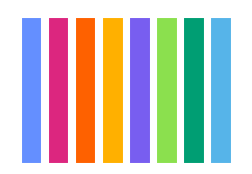

In [1]:
%autoreload 2

import itertools
import os
import pickle as pkl
import sys
from copy import deepcopy
from glob import glob

import matplotlib as mpl
import networkx as nx
import numpy as np
import pandas as pd
import scipy.io as sio
import seaborn as sns
from scipy import signal
from scipy.stats import norm, pearsonr, ttest_ind
from tqdm import tqdm

mpl.rcParams["text.usetex"] = True

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from matplotlib import gridspec
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from slim import viz
from slim.model import SLIM
from slim.utils import kl as kl_div

sys.path.insert(0, "/home/mahdi/python_projects/slim_development/")
from slim_development import SLIM as SD
from slim_development.behavioral_utils import (
    _entropy,
    _cross_entropy,
    _jsd_avg,
    calculate_MLE,
    get_sequence,
)

sys.path.append("/home/mahdi/hdd2/simultaneous_learning_and_inference/notebooks/util/")
import scipy.stats as stats
from helper import load_mat

sns.set(style="whitegrid", context="talk")

ibm_palette = [
    "#648fff",
    "#dc267f",
    "#fe6100",
    "#ffb000",
    "#785ef0",
    "#8be04e",
    "#009e73",
    "#56b4e9",
]
sns.set_palette(ibm_palette)

plt.figure(figsize=(3, 2))
plt.bar(range(len(ibm_palette)), [1] * len(ibm_palette), color=ibm_palette)
plt.axis(False)
plt.show()

### Load Experiment 1 Data

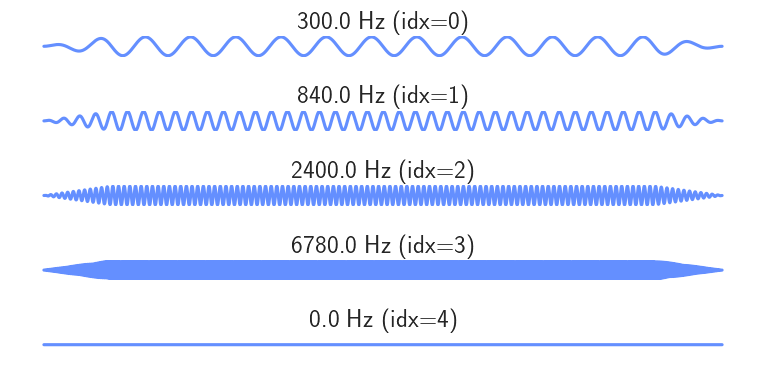

In [2]:
dim = 5

sid = 0  # used for testing/extracting constatnts

data_path = "/mnt/hdd2/simultaneous_learning_and_inference/behavioral_data"
E_experiment1 = np.array(
    [
        sio.loadmat(fn, squeeze_me=True, struct_as_record=False)["E"]
        for fn in sorted(glob(f"{data_path}/AE_beh_data/Data/MEG/*.mat"))
    ]
)
sr_experiment1 = E_experiment1[sid].audio.sr
D_experiment1 = load_mat(f"{data_path}/data/D.mat")["D"]
X_pure_experiment1 = E_experiment1[sid].stim.tones

for idx, ax in enumerate(plt.subplots(dim, 1, figsize=(8, 4))[1]):
    sns.lineplot(X_pure_experiment1[idx], ax=ax)
    # get freq
    X = np.fft.fft(X_pure_experiment1[idx])
    freqs = np.fft.fftfreq(len(X_pure_experiment1[idx]), d=1 / sr_experiment1)
    positive = freqs >= 0
    dominant_freq = freqs[positive][np.argmax(np.abs(X[positive]))]

    ax.set_title(f"{dominant_freq} Hz (idx={idx})")
    ax.axis(False)
plt.tight_layout()
plt.show()

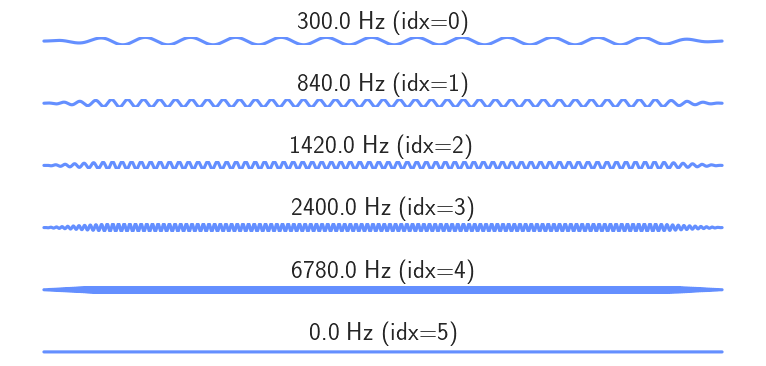

In [3]:
dim = 6

sid = 0  # used for testing/extracting constatnts
data_path = "/mnt/hdd2/simultaneous_learning_and_inference/behavioral_data"
E_experiment2 = np.array(
    [
        sio.loadmat(fn, squeeze_me=True, struct_as_record=False)["E"]
        for fn in sorted(glob(f"{data_path}/Results 21.05/*.mat"))
    ]
)
sr_experiment2 = E_experiment2[sid].audio.sr

X_pure_experiment2 = E_experiment2[sid].stim.tones
experiment2_freqs = []

for idx, ax in enumerate(plt.subplots(dim, 1, figsize=(8, 4))[1]):
    sns.lineplot(X_pure_experiment2[idx], ax=ax)
    # get freq
    X = np.fft.fft(X_pure_experiment2[idx])
    freqs = np.fft.fftfreq(len(X_pure_experiment2[idx]), d=1 / sr_experiment2)
    positive = freqs >= 0
    dominant_freq = freqs[positive][np.argmax(np.abs(X[positive]))]
    experiment2_freqs.append(int(dominant_freq))

    ax.set_title(f"{dominant_freq} Hz (idx={idx})")
    ax.axis(False)
plt.tight_layout()
plt.show()

In [4]:
genders = []
ages = []
for E in E_experiment1:
    ages.append(E.sbj.age)
    genders.append(E.sbj.sex)
print(np.mean(ages))
pd.Series(genders).value_counts()

22.416666666666668


f    24
m    12
Name: count, dtype: int64

In [5]:
genders = []
ages = []
for E in E_experiment2:
    ages.append(E.sbj.age)
    genders.append(E.sbj.sex)
print(np.mean(ages))
pd.Series(genders).value_counts()

22.066666666666666


f    25
m     5
Name: count, dtype: int64

In [8]:
# sanity check

idx_target_low_experiment1 = 0
idx_target_low_experiment2 = 0

idx_cue_low_experiment1 = 1
idx_cue_low_experiment2 = 1

idx_target_amb_experiment2 = 2

idx_cue_high_experiment1 = 2
idx_cue_high_experiment2 = 3

idx_target_high_experiment1 = 3
idx_target_high_experiment2 = 4

idx_target_omis_experiment1 = 4
idx_target_omis_experiment2 = 5

assert np.all(
    X_pure_experiment1[idx_target_low_experiment1]
    == X_pure_experiment2[idx_target_low_experiment2]
)
assert np.all(
    X_pure_experiment1[idx_cue_low_experiment1]
    == X_pure_experiment2[idx_cue_low_experiment2]
)
assert np.all(
    X_pure_experiment1[idx_cue_high_experiment1]
    == X_pure_experiment2[idx_cue_high_experiment2]
)
assert np.all(
    X_pure_experiment1[idx_target_high_experiment1]
    == X_pure_experiment2[idx_target_high_experiment2]
)
assert np.all(
    X_pure_experiment1[idx_target_omis_experiment1]
    == X_pure_experiment2[idx_target_omis_experiment2]
)

### Behavioral Results Summary

In [9]:
# define mappings

# resp_state_map_experiment1 = {}

# maintask / conditions
cond_map_experiment1 = {
    1: "Expected",
    2: "Expected",
    3: "Unexpected",
    4: "Unexpected",
    5: "Omission",
    6: "Omission",
}

# subject responses
resp_map_experiment1 = {1: "low", 2: "high", 3: "omis"}

# gives ideal response based on the condition
cond_to_resp_map_experiment1 = {1: 1, 2: 2, 3: 2, 4: 1, 5: 3, 6: 3}

# subject responses
resp_map_experiment2 = {1: "low", 2: "high", 3: "omis"}

# gives ideal response based on the condition
cond_to_resp_map_experiment2 = {1: 1, 2: 2, 3: 2, 4: 1, 5: 3, 6: 3, 7: 1, 8: 2, 9: 3}

# define helpers

pairs_experiment2_map = {
    1: [1, 0],
    2: [3, 4],
    3: [1, 4],
    4: [3, 0],
    5: [1, 5],
    6: [3, 5],
    7: [2, 0],
    8: [2, 4],
    9: [2, 5],
}
resp_to_state_experiment2_map = {0: -1, 1: 0, 2: 4, 3: 5}
model_to_resp_experiment2_map = {0: 1, 4: 2, 5: 3}
pairs_experiment2_map_flipped = {
    1: [1, 4],
    2: [3, 0],
    3: [1, 0],
    4: [3, 4],
    5: [1, 5],
    6: [3, 5],
    7: [2, 4],
    8: [2, 0],
    9: [2, 5],
}
resp_to_state_experiment2_map_flipped = {0: -1, 1: 4, 2: 0, 3: 5}


def generate_waveforms(
    seq, noise, tscale, bias, X
):  # before it was just using X_pure_experiment2
    noisy_stream = []
    for idx, token in enumerate(seq):
        noisy_stream.append((tscale[token] + bias) * X[token] + noise[idx])
    return np.array(noisy_stream)

# def e():
#     return np.random.rand(int(0.05 * sr_experiment2)) - 0.5

def e(seed):
    rng = np.random.default_rng(seed=seed)
    return rng.random(int(0.05 * sr_experiment2)) - 0.5

def generate_some_noise(n_tokens):
    noisy_stream = []
    for idx in range(n_tokens):
        noisy_stream.append(e(idx))
    return np.array(noisy_stream)

In [10]:
# sanity check to ensure the E is equal to D
# E: lists, resp, stim
print("all responses:\t", D_experiment1[sid]["resp"].shape)

for sid in tqdm(range(len(E_experiment1))):

    # all responses
    assert np.all(D_experiment1[sid]["resp"] == E_experiment1[sid].resp.mainTask.resp)

    # all response times
    assert np.array_equal(
        D_experiment1[sid]["rt"],
        E_experiment1[sid].resp.mainTask.respTime,
        equal_nan=True,
    )  # rts have 2 nans

    # all conditions
    assert np.all(D_experiment1[0]["cond"] == E_experiment1[0].lists.mainTask)


list(D_experiment1[0].keys())

all responses:	 (11, 110)


100%|██████████| 36/36 [00:00<00:00, 18689.81it/s]


['resp',
 'rt',
 'cond',
 'levelChange',
 'hit_exp',
 'hit_une',
 'miss_exp',
 'miss_une',
 'miss_na_exp',
 'miss_na_une',
 'miss_na_omi',
 'miss_na',
 'fa_exp',
 'fa_une',
 'fa',
 'correg',
 'conf_exp',
 'conf_une',
 'norminv_hit_exp',
 'norminv_hit_une',
 'norminv_fa_exp',
 'norminv_fa_une',
 'dPrime_exp',
 'dPrime_une',
 'criterion_exp',
 'criterion_une',
 'rt_exp',
 'rt_une',
 'rt_omi',
 'rt_hit_exp',
 'rt_hit_une',
 'rt_all_hit_exp1',
 'rt_all_hit_exp2',
 'rt_all_hit_une1',
 'rt_all_hit_une2',
 'rt_miss_exp',
 'rt_miss_une',
 'rt_conf_une',
 'rt_conf_exp']

---

## Extract Accuracy and Reaction Time Results

In [11]:
all_acc_exp_experiment1 = []
all_acc_une_experiment1 = []
all_fa_exp_experiment1 = []
all_fa_une_experiment1 = []
all_dPrime_exp_experiment1 = []
all_dPrime_une_experiment1 = []
all_criterion_exp_experiment1 = []
all_criterion_une_experiment1 = []

for sid in range(36):
    conditions = E_experiment1[sid].lists.mainTask[:, 10:].ravel()
    # optimal_responses = np.array(list(map(cond_to_resp_map.get, conditions)))
    subject_responses = E_experiment1[sid].resp.mainTask.resp[:, 10:].ravel()
    subject_response_times = E_experiment1[sid].resp.mainTask.respTime[:, 10:].ravel()

    ############### hit rates ###############

    # log-linear correction / Laplace smoothing
    acc_exp1 = (sum(subject_responses[conditions == 1] == 1) + 0.5) / (
        sum(conditions == 1) + 1
    )
    acc_exp2 = (sum(subject_responses[conditions == 2] == 2) + 0.5) / (
        sum(conditions == 2) + 1
    )
    acc_exp = np.nanmean([acc_exp1, acc_exp2])
    assert acc_exp == D_experiment1[sid]["hit_exp"]
    all_acc_exp_experiment1.append(acc_exp)

    acc_une1 = (sum(subject_responses[conditions == 3] == 2) + 0.5) / (
        sum(conditions == 3) + 1
    )
    acc_une2 = (sum(subject_responses[conditions == 4] == 1) + 0.5) / (
        sum(conditions == 4) + 1
    )
    acc_une = np.nanmean([acc_une1, acc_une2])
    assert acc_une == D_experiment1[sid]["hit_une"]
    all_acc_une_experiment1.append(acc_une)

    ############### false alarms ###############

    fa_exp1 = (sum(subject_responses[conditions == 5] == 1) + 0.5) / (
        sum(conditions == 5) + 1
    )
    # raise ValueError(fa_exp1)
    fa_exp2 = (sum(subject_responses[conditions == 6] == 2) + 0.5) / (
        sum(conditions == 6) + 1
    )
    fa_exp = np.nanmean([fa_exp1, fa_exp2])
    assert fa_exp == D_experiment1[sid]["fa_exp"]
    all_fa_exp_experiment1.append(fa_exp)

    fa_une1 = (sum(subject_responses[conditions == 5] == 2) + 0.5) / (
        sum(conditions == 5) + 1
    )
    fa_une2 = (sum(subject_responses[conditions == 6] == 1) + 0.5) / (
        sum(conditions == 6) + 1
    )
    fa_une = np.nanmean([fa_une1, fa_une2])
    assert fa_une == D_experiment1[sid]["fa_une"]
    all_fa_une_experiment1.append(fa_une)

    ############### d Prime ###############

    dPrime_exp = stats.norm.ppf(acc_exp) - stats.norm.ppf(fa_exp)
    assert np.isclose(dPrime_exp, D_experiment1[sid]["dPrime_exp"])
    all_dPrime_exp_experiment1.append(dPrime_exp)

    dPrime_une = stats.norm.ppf(acc_une) - stats.norm.ppf(fa_une)
    assert np.isclose(dPrime_une, D_experiment1[sid]["dPrime_une"])
    all_dPrime_une_experiment1.append(dPrime_une)

    ############### criterion ###############

    criterion_exp = -0.5 * (stats.norm.ppf(acc_exp) + stats.norm.ppf(fa_exp))
    assert np.isclose(criterion_exp, D_experiment1[sid]["criterion_exp"])
    all_criterion_exp_experiment1.append(criterion_exp)

    criterion_une = -0.5 * (stats.norm.ppf(acc_une) + stats.norm.ppf(fa_une))
    assert np.isclose(criterion_une, D_experiment1[sid]["criterion_une"])
    all_criterion_une_experiment1.append(criterion_une)

### check if there are exclusions

In [12]:
exclusions_experiment1 = (np.array(all_dPrime_une_experiment1) < 1.0) & (
    np.array(all_dPrime_exp_experiment1) < 1.0
)
np.any(exclusions_experiment1)

np.False_

# collect experiment 1 data

In [13]:
all_rt_exp_experiment1_blockwise = {}
all_rt_une_experiment1_blockwise = {}

all_dprime_exp_experiment1_blockwise = {}
all_dprime_une_experiment1_blockwise = {}
all_criterion_exp_experiment1_blockwise = {}
all_criterion_une_experiment1_blockwise = {}

for block in range(11):

    all_rt_exp_experiment1_blockwise[block] = []
    all_rt_une_experiment1_blockwise[block] = []
    all_dprime_exp_experiment1_blockwise[block] = []
    all_dprime_une_experiment1_blockwise[block] = []
    all_criterion_exp_experiment1_blockwise[block] = []
    all_criterion_une_experiment1_blockwise[block] = []

    for sid in range(36):

        conditions = E_experiment1[sid].lists.mainTask[block, 10:]
        # optimal_responses = np.array(list(map(cond_to_resp_map.get, conditions)))
        subject_responses = E_experiment1[sid].resp.mainTask.resp[block, 10:]
        subject_response_times = E_experiment1[sid].resp.mainTask.respTime[block, 10:]

        ############### reaction times ###############

        # rts
        rt_exp1 = np.nanmedian(
            subject_response_times[(conditions == 1) & (subject_responses == 1)]
        )
        rt_exp2 = np.nanmedian(
            subject_response_times[(conditions == 2) & (subject_responses == 2)]
        )
        rt_exp = np.nanmean([rt_exp1, rt_exp2])
        # assert rt_exp == D_experiment1[sid]['rt_hit_exp']
        all_rt_exp_experiment1_blockwise[block].append(rt_exp)

        rt_une1 = np.nanmedian(
            subject_response_times[(conditions == 3) & (subject_responses == 2)]
        )
        rt_une2 = np.nanmedian(
            subject_response_times[(conditions == 4) & (subject_responses == 1)]
        )
        rt_une = np.nanmean([rt_une1, rt_une2])
        # assert rt_une == D_experiment1[sid]['rt_hit_une']
        all_rt_une_experiment1_blockwise[block].append(rt_une)

        # dprime
        acc_exp = np.nanmean(
            [
                (sum(subject_responses[conditions == 1] == 1) + 0.5)
                / (sum(conditions == 1) + 1),
                (sum(subject_responses[conditions == 2] == 2) + 0.5)
                / (sum(conditions == 2) + 1),
            ]
        )
        fa_exp = np.nanmean(
            [
                (sum(subject_responses[conditions == 5] == 1) + 0.5)
                / (sum(conditions == 5) + 1),
                (sum(subject_responses[conditions == 6] == 2) + 0.5)
                / (sum(conditions == 6) + 1),
            ]
        )
        dPrime_exp = stats.norm.ppf(acc_exp) - stats.norm.ppf(fa_exp)
        all_dprime_exp_experiment1_blockwise[block].append(dPrime_exp)

        acc_une = np.nanmean(
            [
                (sum(subject_responses[conditions == 3] == 2) + 0.5)
                / (sum(conditions == 3) + 1),
                (sum(subject_responses[conditions == 4] == 1) + 0.5)
                / (sum(conditions == 4) + 1),
            ]
        )
        fa_une = np.nanmean(
            [
                (sum(subject_responses[conditions == 5] == 2) + 0.5)
                / (sum(conditions == 5) + 1),
                (sum(subject_responses[conditions == 6] == 1) + 0.5)
                / (sum(conditions == 6) + 1),
            ]
        )
        dPrime_une = stats.norm.ppf(acc_une) - stats.norm.ppf(fa_une)
        all_dprime_une_experiment1_blockwise[block].append(dPrime_une)

        # criterion
        criterion_exp = -0.5 * (stats.norm.ppf(acc_exp) + stats.norm.ppf(fa_exp))
        all_criterion_exp_experiment1_blockwise[block].append(criterion_exp)

        criterion_une = -0.5 * (stats.norm.ppf(acc_une) + stats.norm.ppf(fa_une))
        all_criterion_une_experiment1_blockwise[block].append(criterion_une)

/home/mahdi/anaconda3/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/tmp/ipykernel_3962546/793473477.py:34: RuntimeWarning: Mean of empty slice
  rt_exp = np.nanmean([rt_exp1, rt_exp2])
/tmp/ipykernel_3962546/793473477.py:44: RuntimeWarning: Mean of empty slice
  rt_une = np.nanmean([rt_une1, rt_une2])


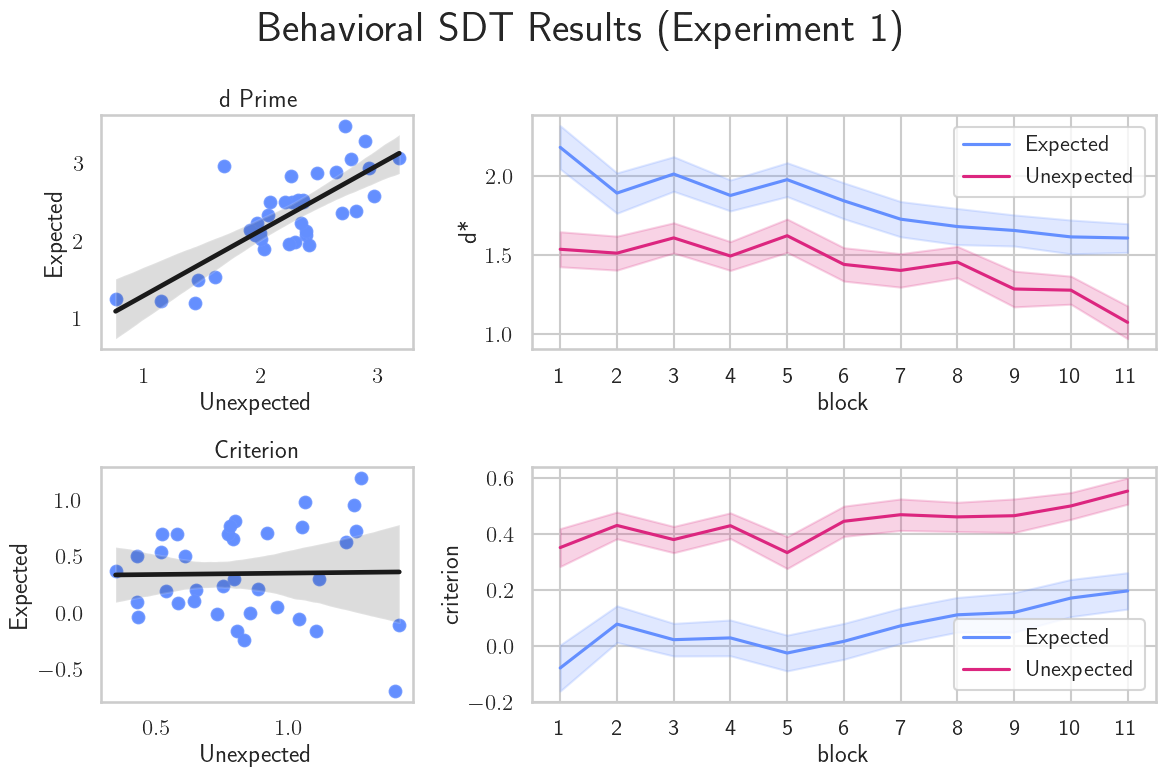

In [19]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8), gridspec_kw={"width_ratios": [2, 4]})

sns.scatterplot(x=all_dPrime_une_experiment1, y=all_dPrime_exp_experiment1, ax=ax[0][0])
sns.regplot(
    x=all_dPrime_une_experiment1,
    y=all_dPrime_exp_experiment1,
    line_kws={"color": "k"},
    ax=ax[0][0],
)
ax[0][0].set_xlabel("Unexpected")
ax[0][0].set_ylabel("Expected")
ax[0][0].set_title("d Prime")
ax[0][0].grid(False)

df = (
    pd.DataFrame(all_dprime_exp_experiment1_blockwise)
    .T.assign(x=np.arange(len(all_dprime_exp_experiment1_blockwise)))
    .melt(id_vars="x", value_name="y")
)
sns.lineplot(data=df, x="x", y="y", errorbar="se", ax=ax[0][1], label="Expected")
df = (
    pd.DataFrame(all_dprime_une_experiment1_blockwise)
    .T.assign(x=np.arange(len(all_dprime_une_experiment1_blockwise)))
    .melt(id_vars="x", value_name="y")
)
sns.lineplot(data=df, x="x", y="y", errorbar="se", ax=ax[0][1], label="Unexpected")
ax[0][1].set_xlabel("block")
ax[0][1].set_ylabel("d*")
ax[0][1].set_xticks(range(11), np.arange(1, 12))


# criterion
sns.scatterplot(
    x=all_criterion_une_experiment1, y=all_criterion_exp_experiment1, ax=ax[1][0]
)
sns.regplot(
    x=all_criterion_une_experiment1,
    y=all_criterion_exp_experiment1,
    line_kws={"color": "k"},
    ax=ax[1][0],
)
ax[1][0].set_xlabel("Unexpected")
ax[1][0].set_ylabel("Expected")
ax[1][0].set_title("Criterion")
ax[1][0].grid(False)

df = (
    pd.DataFrame(all_criterion_exp_experiment1_blockwise)
    .T.assign(x=np.arange(len(all_criterion_exp_experiment1_blockwise)))
    .melt(id_vars="x", value_name="y")
)
sns.lineplot(data=df, x="x", y="y", errorbar="se", ax=ax[1][1], label="Expected")
df = (
    pd.DataFrame(all_criterion_une_experiment1_blockwise)
    .T.assign(x=np.arange(len(all_criterion_une_experiment1_blockwise)))
    .melt(id_vars="x", value_name="y")
)
sns.lineplot(data=df, x="x", y="y", errorbar="se", ax=ax[1][1], label="Unexpected")
ax[1][1].set_xlabel("block")
ax[1][1].set_ylabel("criterion")
ax[1][1].set_xticks(range(11), np.arange(1, 12))

plt.suptitle("Behavioral SDT Results (Experiment 1)", fontweight="bold", fontsize=30)
plt.tight_layout()
plt.savefig(
    "./behavioral_modeling_results/main_behavioral_experiment1_sdt.png", dpi=300
)

plt.show()

In [20]:
data_store = {}

In [21]:
data_store["behavioral_experiment1"] = {
    "all_dPrime_une_experiment1": all_dPrime_une_experiment1,
    "all_dPrime_exp_experiment1": all_dPrime_exp_experiment1,
    "all_criterion_une_experiment1": all_criterion_une_experiment1,
    "all_criterion_exp_experiment1": all_criterion_exp_experiment1,
    "all_dPrime_exp_experiment1_blockwise": all_dprime_exp_experiment1_blockwise,
    "all_dPrime_une_experiment1_blockwise": all_dprime_une_experiment1_blockwise,
    "all_criterion_exp_experiment1_blockwise": all_criterion_exp_experiment1_blockwise,
    "all_criterion_une_experiment1_blockwise": all_criterion_une_experiment1_blockwise,
    "all_rt_exp_experiment1_blockwise": all_rt_exp_experiment1_blockwise,
    "all_rt_une_experiment1_blockwise": all_rt_une_experiment1_blockwise,
    "all_acc_exp_experiment1": all_acc_exp_experiment1,
    "all_acc_une_experiment1": all_acc_une_experiment1,
}

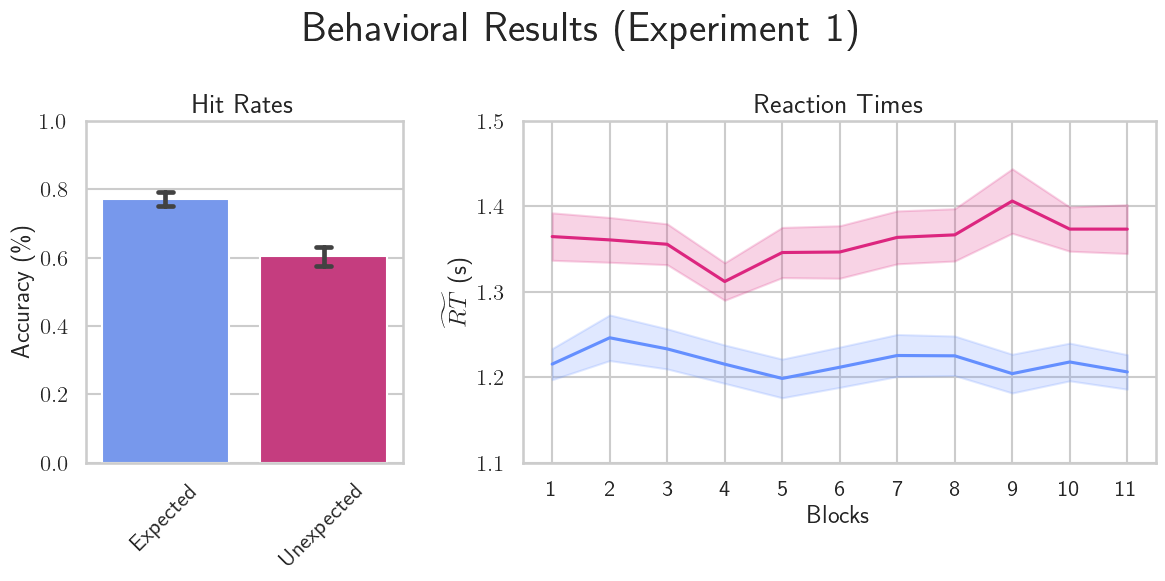

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={"width_ratios": [2, 4]})
df = pd.DataFrame(
    np.array([all_acc_exp_experiment1, all_acc_une_experiment1]).T,
    columns=["Expected", "Unexpected"],
)
sns.barplot(df, ax=ax[0], errorbar="se", capsize=0.1)  # 95% confience interval
ax[0].set_title("Hit Rates", fontweight="bold", fontsize=20)
ax[0].set_ylabel(r"Accuracy (\%)")
ax[0].set_ylim(0, 1)
ax[0].tick_params(axis="x", rotation=45)

df = (
    pd.DataFrame(all_rt_exp_experiment1_blockwise)
    .T.assign(x=np.arange(len(all_rt_exp_experiment1_blockwise)))
    .melt(id_vars="x", value_name="y")
)
sns.lineplot(data=df, x="x", y="y", errorbar="se", ax=ax[1])
df = (
    pd.DataFrame(all_rt_une_experiment1_blockwise)
    .T.assign(x=np.arange(len(all_rt_une_experiment1_blockwise)))
    .melt(id_vars="x", value_name="y")
)
sns.lineplot(data=df, x="x", y="y", errorbar="se", ax=ax[1])

ax[1].set_title(r"Reaction Times", fontweight="bold", fontsize=20)
ax[1].set_ylabel(r"$\widetilde{RT}$ (s)")
ax[1].set_ylim(1.1, 1.5)
ax[1].set_xlabel("Blocks")
ax[1].set_xticks(range(11), np.arange(1, 12))

plt.suptitle("Behavioral Results (Experiment 1)", fontweight="bold", fontsize=30)
plt.tight_layout()
plt.savefig("./behavioral_modeling_results/main_behavioral_experiment1.png", dpi=300)

plt.show()

---

## Decision under Noise with Ambiguity

- has 12 practice trials!

In [18]:
all_acc_exp_experiment2 = []
all_acc_une_experiment2 = []
all_acc_amb_experiment2 = []

all_fa_exp_experiment2 = []
all_fa_une_experiment2 = []
all_fa_amb_experiment2 = []

all_dPrime_exp_experiment2 = []
all_dPrime_une_experiment2 = []
all_dPrime_amb_experiment2 = []
all_criterion_exp_experiment2 = []
all_criterion_une_experiment2 = []
all_criterion_amb_experiment2 = []

for sid in range(30):

    conditions = E_experiment2[sid].lists.mainTask[:, 12:].ravel()
    # optimal_responses = np.array(list(map(cond_to_resp_map_experiment2.get, conditions)))
    subject_responses = E_experiment2[sid].resp.mainTask.resp[:, 12:].ravel()
    subject_response_times = E_experiment2[sid].resp.mainTask.respTime[:, 12:].ravel()

    # log-linear correction / Laplace smoothing
    acc_exp1 = (
        sum(subject_responses[conditions == 1] == conditions[conditions == 1]) + 0.5
    ) / (sum(conditions == 1) + 1)
    acc_exp2 = (
        sum(subject_responses[conditions == 2] == conditions[conditions == 2]) + 0.5
    ) / (sum(conditions == 2) + 1)
    acc_exp = np.nanmean([acc_exp1, acc_exp2])
    all_acc_exp_experiment2.append(acc_exp)

    acc_une1 = (sum(subject_responses[conditions == 3] == 2) + 0.5) / (
        sum(conditions == 3) + 1
    )
    acc_une2 = (sum(subject_responses[conditions == 4] == 1) + 0.5) / (
        sum(conditions == 4) + 1
    )
    acc_une = np.nanmean([acc_une1, acc_une2])
    all_acc_une_experiment2.append(acc_une)

    acc_amb1 = (sum(subject_responses[conditions == 7] == 1) + 0.5) / (
        sum(conditions == 7) + 1
    )
    acc_amb2 = (sum(subject_responses[conditions == 8] == 2) + 0.5) / (
        sum(conditions == 8) + 1
    )
    acc_amb = np.nanmean([acc_amb1, acc_amb2])
    all_acc_amb_experiment2.append(acc_amb)

    ############### false alarms ###############

    fa_exp1 = (sum(subject_responses[conditions == 5] == 1) + 0.5) / (
        sum(conditions == 5) + 1
    )
    fa_exp2 = (sum(subject_responses[conditions == 6] == 2) + 0.5) / (
        sum(conditions == 6) + 1
    )
    fa_exp = np.nanmean([fa_exp1, fa_exp2])
    all_fa_exp_experiment2.append(fa_exp)

    fa_une1 = (sum(subject_responses[conditions == 5] == 2) + 0.5) / (
        sum(conditions == 5) + 1
    )
    fa_une2 = (sum(subject_responses[conditions == 6] == 1) + 0.5) / (
        sum(conditions == 6) + 1
    )
    fa_une = np.nanmean([fa_une1, fa_une2])
    all_fa_une_experiment2.append(fa_une)

    fa_amb1 = (sum(subject_responses[conditions == 9] == 1) + 0.5) / (
        sum(conditions == 9) + 1
    )
    fa_amb2 = (sum(subject_responses[conditions == 9] == 2) + 0.5) / (
        sum(conditions == 9) + 1
    )
    fa_amb = np.nanmean([fa_amb1, fa_amb2])
    all_fa_amb_experiment2.append(fa_amb)

    ############### d Prime ###############

    dPrime_exp = stats.norm.ppf(acc_exp) - stats.norm.ppf(fa_exp)
    all_dPrime_exp_experiment2.append(dPrime_exp)

    dPrime_une = stats.norm.ppf(acc_une) - stats.norm.ppf(fa_une)
    all_dPrime_une_experiment2.append(dPrime_une)

    dPrime_amb = stats.norm.ppf(acc_amb) - stats.norm.ppf(fa_amb)
    all_dPrime_amb_experiment2.append(dPrime_amb)

    ############### criterion ###############

    criterion_exp = -0.5 * (stats.norm.ppf(acc_exp) + stats.norm.ppf(fa_exp))
    all_criterion_exp_experiment2.append(criterion_exp)

    criterion_une = -0.5 * (stats.norm.ppf(acc_une) + stats.norm.ppf(fa_une))
    all_criterion_une_experiment2.append(criterion_une)

    criterion_amb = -0.5 * (stats.norm.ppf(acc_amb) + stats.norm.ppf(fa_amb))
    all_criterion_amb_experiment2.append(criterion_amb)

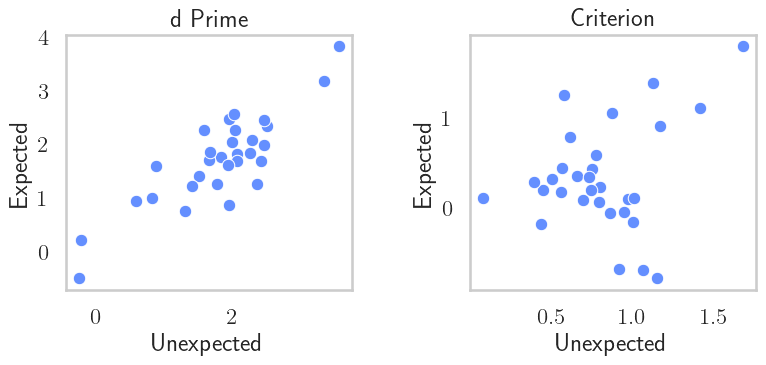

In [19]:
plt.figure(figsize=(8, 4))
ax = sns.scatterplot(
    x=all_dPrime_une_experiment2, y=all_dPrime_exp_experiment2, ax=plt.subplot(121)
)
ax.set_xlabel("Unexpected")
ax.set_ylabel("Expected")
ax.set_title("d Prime")
ax.grid(False)

ax = sns.scatterplot(
    x=all_criterion_une_experiment2,
    y=all_criterion_exp_experiment2,
    ax=plt.subplot(122),
)
ax.set_xlabel("Unexpected")
ax.set_ylabel("Expected")
ax.set_title("Criterion")
ax.grid(False)

plt.tight_layout()
plt.show()

In [20]:
exclusions_experiment2 = (np.array(all_dPrime_une_experiment2) < 1.0) & (
    np.array(all_dPrime_exp_experiment2) < 1.0
)
exclusions_experiment2[20] = True
np.where(exclusions_experiment2)

(array([ 9, 10, 20, 22, 27]),)

In [21]:
# prepare experiment2 data

all_rt_exp_experiment2_blockwise = {}
all_rt_une_experiment2_blockwise = {}
all_rt_amb_experiment2_blockwise = {}

all_dprime_exp_experiment2_blockwise = {}
all_dprime_une_experiment2_blockwise = {}
all_dprime_amb_experiment2_blockwise = {}
all_criterion_exp_experiment2_blockwise = {}
all_criterion_une_experiment2_blockwise = {}
all_criterion_amb_experiment2_blockwise = {}

for block in range(11):

    all_rt_amb_experiment2_blockwise[block] = []
    all_rt_exp_experiment2_blockwise[block] = []
    all_rt_une_experiment2_blockwise[block] = []

    all_dprime_exp_experiment2_blockwise[block] = []
    all_dprime_une_experiment2_blockwise[block] = []
    all_dprime_amb_experiment2_blockwise[block] = []
    all_criterion_exp_experiment2_blockwise[block] = []
    all_criterion_une_experiment2_blockwise[block] = []
    all_criterion_amb_experiment2_blockwise[block] = []

    for sid in range(30):
        if exclusions_experiment2[sid]:
            continue

        conditions = E_experiment2[sid].lists.mainTask[block, 12:]
        # optimal_responses = np.array(list(map(cond_to_resp_map_experiment2.get, conditions)))
        subject_responses = E_experiment2[sid].resp.mainTask.resp[block, 12:]
        subject_response_times = E_experiment2[sid].resp.mainTask.respTime[block, 12:]

        # rts
        rt_exp1 = np.nanmedian(
            subject_response_times[(conditions == 1) & (subject_responses == 1)]
        )
        rt_exp2 = np.nanmedian(
            subject_response_times[(conditions == 2) & (subject_responses == 2)]
        )
        rt_exp = np.nanmean([rt_exp1, rt_exp2])
        all_rt_exp_experiment2_blockwise[block].append(rt_exp)

        rt_une1 = np.nanmedian(
            subject_response_times[(conditions == 3) & (subject_responses == 2)]
        )
        rt_une2 = np.nanmedian(
            subject_response_times[(conditions == 4) & (subject_responses == 1)]
        )
        rt_une = np.nanmean([rt_une1, rt_une2])
        all_rt_une_experiment2_blockwise[block].append(rt_une)

        rt_amb1 = np.nanmedian(
            subject_response_times[(conditions == 7) & (subject_responses == 1)]
        )
        rt_amb2 = np.nanmedian(
            subject_response_times[(conditions == 8) & (subject_responses == 2)]
        )
        rt_amb = np.nanmean([rt_amb1, rt_amb2])
        all_rt_amb_experiment2_blockwise[block].append(rt_amb)

        #####################

        # dprime
        # exp
        acc_exp = np.nanmean(
            [
                (sum(subject_responses[conditions == 1] == 1) + 0.5)
                / (sum(conditions == 1) + 1),
                (sum(subject_responses[conditions == 2] == 2) + 0.5)
                / (sum(conditions == 2) + 1),
            ]
        )
        fa_exp = np.nanmean(
            [
                (sum(subject_responses[conditions == 5] == 1) + 0.5)
                / (sum(conditions == 5) + 1),
                (sum(subject_responses[conditions == 6] == 2) + 0.5)
                / (sum(conditions == 6) + 1),
            ]
        )
        dPrime_exp = stats.norm.ppf(acc_exp) - stats.norm.ppf(fa_exp)
        all_dprime_exp_experiment2_blockwise[block].append(dPrime_exp)
        # une
        acc_une = np.nanmean(
            [
                (sum(subject_responses[conditions == 3] == 2) + 0.5)
                / (sum(conditions == 3) + 1),
                (sum(subject_responses[conditions == 4] == 1) + 0.5)
                / (sum(conditions == 4) + 1),
            ]
        )
        fa_une = np.nanmean(
            [
                (sum(subject_responses[conditions == 5] == 2) + 0.5)
                / (sum(conditions == 5) + 1),
                (sum(subject_responses[conditions == 6] == 1) + 0.5)
                / (sum(conditions == 6) + 1),
            ]
        )
        dPrime_une = stats.norm.ppf(acc_une) - stats.norm.ppf(fa_une)
        all_dprime_une_experiment2_blockwise[block].append(dPrime_une)
        # amb
        acc_amb = np.nanmean(
            [
                (sum(subject_responses[conditions == 7] == 1) + 0.5)
                / (sum(conditions == 7) + 1),
                (sum(subject_responses[conditions == 8] == 2) + 0.5)
                / (sum(conditions == 8) + 1),
            ]
        )
        fa_amb = np.nanmean(
            [
                (sum(subject_responses[conditions == 9] == 1) + 0.5)
                / (sum(conditions == 9) + 1),
                (sum(subject_responses[conditions == 9] == 2) + 0.5)
                / (sum(conditions == 9) + 1),
            ]
        )
        dPrime_amb = stats.norm.ppf(acc_amb) - stats.norm.ppf(fa_amb)
        all_dprime_amb_experiment2_blockwise[block].append(dPrime_amb)

        # criterion
        criterion_exp = -0.5 * (stats.norm.ppf(acc_exp) + stats.norm.ppf(fa_exp))
        all_criterion_exp_experiment2_blockwise[block].append(criterion_exp)

        criterion_une = -0.5 * (stats.norm.ppf(acc_une) + stats.norm.ppf(fa_une))
        all_criterion_une_experiment2_blockwise[block].append(criterion_une)

        criterion_amb = -0.5 * (stats.norm.ppf(acc_amb) + stats.norm.ppf(fa_amb))
        all_criterion_amb_experiment2_blockwise[block].append(criterion_amb)

/home/mahdi/anaconda3/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/tmp/ipykernel_2693694/1473930004.py:43: RuntimeWarning: Mean of empty slice
  rt_exp = np.nanmean([rt_exp1, rt_exp2])
/tmp/ipykernel_2693694/1473930004.py:52: RuntimeWarning: Mean of empty slice
  rt_une = np.nanmean([rt_une1, rt_une2])
/tmp/ipykernel_2693694/1473930004.py:61: RuntimeWarning: Mean of empty slice
  rt_amb = np.nanmean([rt_amb1, rt_amb2])


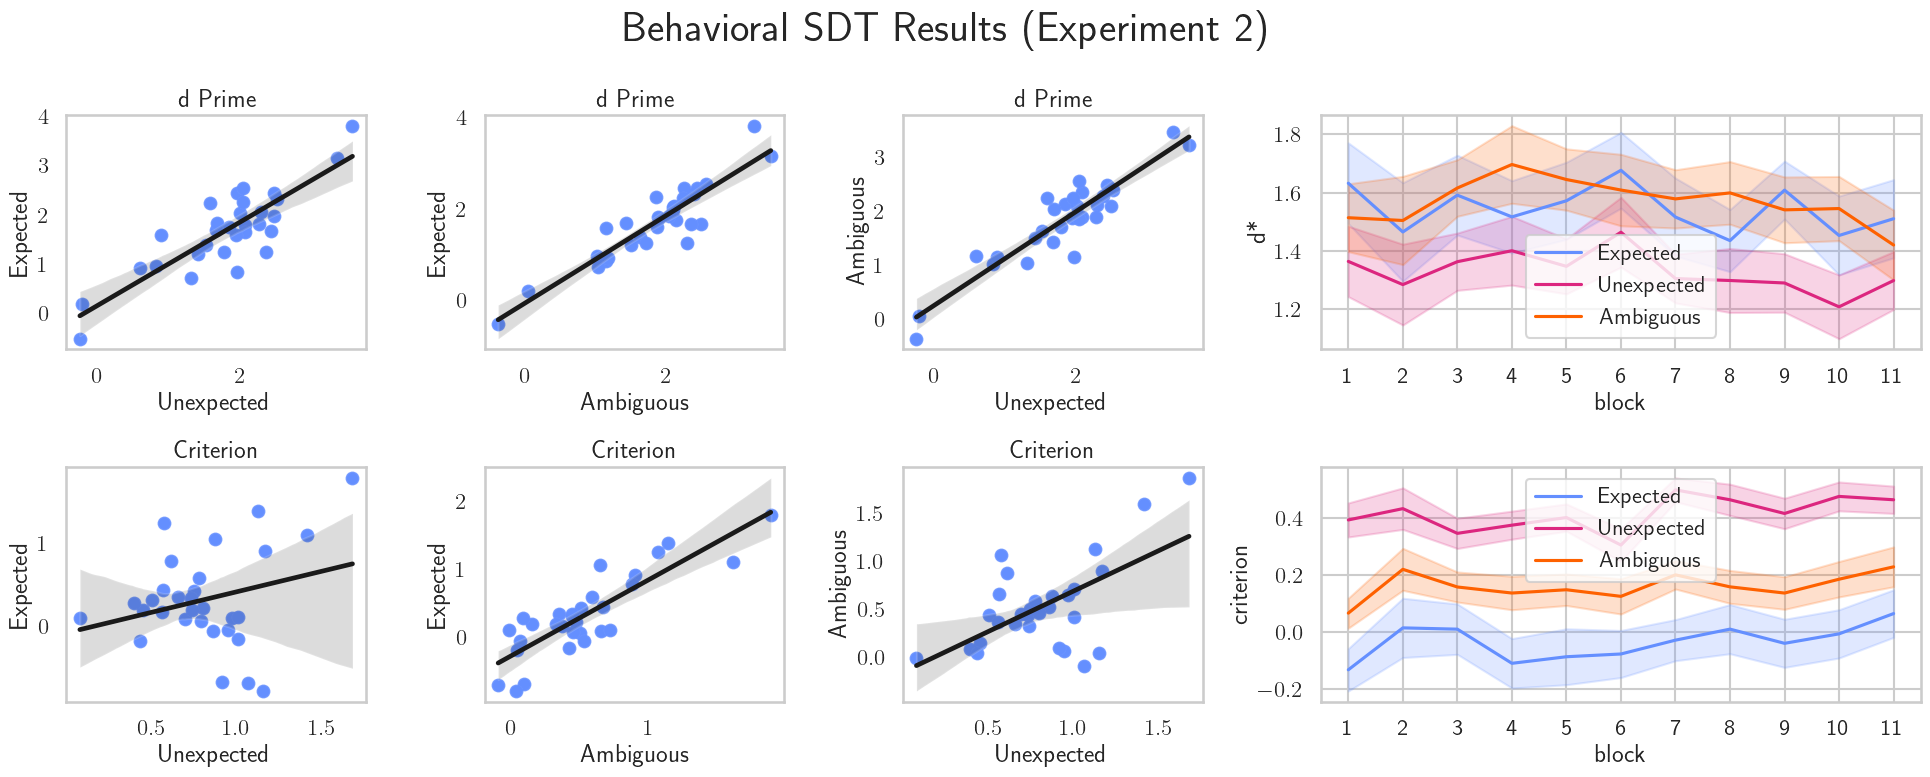

In [22]:
fig, ax = plt.subplots(
    2, 4, figsize=(20, 8), gridspec_kw={"width_ratios": [2, 2, 2, 4]}
)

sns.scatterplot(x=all_dPrime_une_experiment2, y=all_dPrime_exp_experiment2, ax=ax[0][0])
sns.regplot(
    x=all_dPrime_une_experiment2,
    y=all_dPrime_exp_experiment2,
    line_kws={"color": "k"},
    ax=ax[0][0],
)
ax[0][0].set_xlabel("Unexpected")
ax[0][0].set_ylabel("Expected")
ax[0][0].set_title("d Prime")
ax[0][0].grid(False)

sns.scatterplot(x=all_dPrime_amb_experiment2, y=all_dPrime_exp_experiment2, ax=ax[0][1])
sns.regplot(
    x=all_dPrime_amb_experiment2,
    y=all_dPrime_exp_experiment2,
    line_kws={"color": "k"},
    ax=ax[0][1],
)
ax[0][1].set_xlabel("Ambiguous")
ax[0][1].set_ylabel("Expected")
ax[0][1].set_title("d Prime")
ax[0][1].grid(False)

sns.scatterplot(x=all_dPrime_une_experiment2, y=all_dPrime_amb_experiment2, ax=ax[0][2])
sns.regplot(
    x=all_dPrime_une_experiment2,
    y=all_dPrime_amb_experiment2,
    line_kws={"color": "k"},
    ax=ax[0][2],
)
ax[0][2].set_xlabel("Unexpected")
ax[0][2].set_ylabel("Ambiguous")
ax[0][2].set_title("d Prime")
ax[0][2].grid(False)


df = (
    pd.DataFrame(all_dprime_exp_experiment2_blockwise)
    .T.assign(x=np.arange(len(all_dprime_exp_experiment2_blockwise)))
    .melt(id_vars="x", value_name="y")
)
sns.lineplot(data=df, x="x", y="y", errorbar="se", ax=ax[0][3], label="Expected")
df = (
    pd.DataFrame(all_dprime_une_experiment2_blockwise)
    .T.assign(x=np.arange(len(all_dprime_une_experiment2_blockwise)))
    .melt(id_vars="x", value_name="y")
)
sns.lineplot(data=df, x="x", y="y", errorbar="se", ax=ax[0][3], label="Unexpected")
df = (
    pd.DataFrame(all_dprime_amb_experiment2_blockwise)
    .T.assign(x=np.arange(len(all_dprime_amb_experiment2_blockwise)))
    .melt(id_vars="x", value_name="y")
)
sns.lineplot(data=df, x="x", y="y", errorbar="se", ax=ax[0][3], label="Ambiguous")
ax[0][3].set_xlabel("block")
ax[0][3].set_ylabel("d*")
ax[0][3].set_xticks(range(11), np.arange(1, 12))


# criterion
sns.scatterplot(
    x=all_criterion_une_experiment2, y=all_criterion_exp_experiment2, ax=ax[1][0]
)
sns.regplot(
    x=all_criterion_une_experiment2,
    y=all_criterion_exp_experiment2,
    line_kws={"color": "k"},
    ax=ax[1][0],
)
ax[1][0].set_xlabel("Unexpected")
ax[1][0].set_ylabel("Expected")
ax[1][0].set_title("Criterion")
ax[1][0].grid(False)

sns.scatterplot(
    x=all_criterion_amb_experiment2, y=all_criterion_exp_experiment2, ax=ax[1][1]
)
sns.regplot(
    x=all_criterion_amb_experiment2,
    y=all_criterion_exp_experiment2,
    line_kws={"color": "k"},
    ax=ax[1][1],
)
ax[1][1].set_xlabel("Ambiguous")
ax[1][1].set_ylabel("Expected")
ax[1][1].set_title("Criterion")
ax[1][1].grid(False)

sns.scatterplot(
    x=all_criterion_une_experiment2, y=all_criterion_amb_experiment2, ax=ax[1][2]
)
sns.regplot(
    x=all_criterion_une_experiment2,
    y=all_criterion_amb_experiment2,
    line_kws={"color": "k"},
    ax=ax[1][2],
)
ax[1][2].set_xlabel("Unexpected")
ax[1][2].set_ylabel("Ambiguous")
ax[1][2].set_title("Criterion")
ax[1][2].grid(False)

df = (
    pd.DataFrame(all_criterion_exp_experiment2_blockwise)
    .T.assign(x=np.arange(len(all_criterion_exp_experiment2_blockwise)))
    .melt(id_vars="x", value_name="y")
)
sns.lineplot(data=df, x="x", y="y", errorbar="se", ax=ax[1][3], label="Expected")
df = (
    pd.DataFrame(all_criterion_une_experiment2_blockwise)
    .T.assign(x=np.arange(len(all_criterion_une_experiment2_blockwise)))
    .melt(id_vars="x", value_name="y")
)
sns.lineplot(data=df, x="x", y="y", errorbar="se", ax=ax[1][3], label="Unexpected")
df = (
    pd.DataFrame(all_criterion_amb_experiment2_blockwise)
    .T.assign(x=np.arange(len(all_criterion_amb_experiment2_blockwise)))
    .melt(id_vars="x", value_name="y")
)
sns.lineplot(data=df, x="x", y="y", errorbar="se", ax=ax[1][3], label="Ambiguous")
ax[1][3].set_xlabel("block")
ax[1][3].set_ylabel("criterion")
ax[1][3].set_xticks(range(11), np.arange(1, 12))

plt.suptitle("Behavioral SDT Results (Experiment 2)", fontweight="bold", fontsize=30)
plt.tight_layout()
plt.savefig(
    "./behavioral_modeling_results/main_behavioral_experiment2_sdt.png", dpi=300
)

plt.show()

In [23]:
data_store["behavioral_experiment2"] = {
    "all_dPrime_une_experiment2": all_dPrime_une_experiment2,
    "all_dPrime_exp_experiment2": all_dPrime_exp_experiment2,
    "all_dPrime_amb_experiment2": all_dPrime_amb_experiment2,
    "all_criterion_une_experiment2": all_criterion_une_experiment2,
    "all_criterion_exp_experiment2": all_criterion_exp_experiment2,
    "all_criterion_amb_experiment2": all_criterion_amb_experiment2,
    "all_dPrime_exp_experiment2_blockwise": all_dprime_exp_experiment2_blockwise,
    "all_dPrime_une_experiment2_blockwise": all_dprime_une_experiment2_blockwise,
    "all_dPrime_amb_experiment2_blockwise": all_dprime_amb_experiment2_blockwise,
    "all_criterion_exp_experiment2_blockwise": all_criterion_exp_experiment2_blockwise,
    "all_criterion_une_experiment2_blockwise": all_criterion_une_experiment2_blockwise,
    "all_criterion_amb_experiment2_blockwise": all_criterion_amb_experiment2_blockwise,
    "all_rt_exp_experiment2_blockwise": all_rt_exp_experiment2_blockwise,
    "all_rt_une_experiment2_blockwise": all_rt_une_experiment2_blockwise,
    "all_rt_amb_experiment2_blockwise": all_rt_amb_experiment2_blockwise,
    "all_acc_exp_experiment2": all_acc_exp_experiment2,
    "all_acc_une_experiment2": all_acc_une_experiment2,
    "all_acc_amb_experiment2": all_acc_amb_experiment2,
}

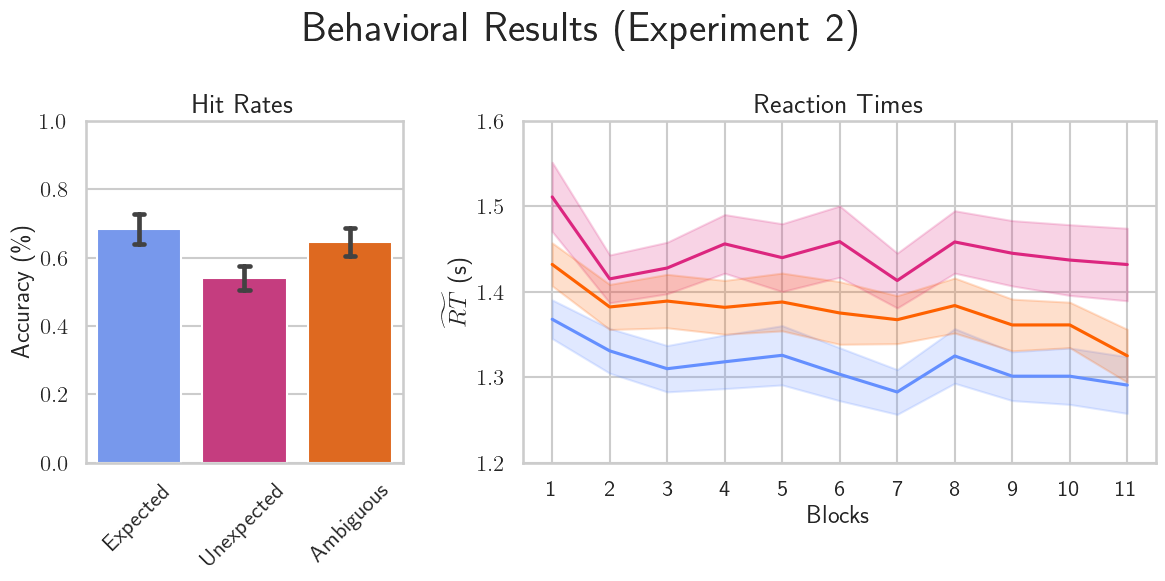

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={"width_ratios": [2, 4]})
df = pd.DataFrame(
    np.array(
        [all_acc_exp_experiment2, all_acc_une_experiment2, all_acc_amb_experiment2]
    ).T,
    columns=["Expected", "Unexpected", "Ambiguous"],
)
sns.barplot(df, ax=ax[0], errorbar="se", capsize=0.1)  # 95% confience interval
ax[0].set_title("Hit Rates", fontweight="bold", fontsize=20)
ax[0].set_ylabel(r"Accuracy (\%)")
ax[0].set_ylim(0, 1)
ax[0].tick_params(axis="x", rotation=45)

df = (
    pd.DataFrame(all_rt_exp_experiment2_blockwise)
    .T.assign(x=np.arange(len(all_rt_exp_experiment2_blockwise)))
    .melt(id_vars="x", value_name="y")
)
sns.lineplot(data=df, x="x", y="y", errorbar="se", ax=ax[1])
df = (
    pd.DataFrame(all_rt_une_experiment2_blockwise)
    .T.assign(x=np.arange(len(all_rt_une_experiment2_blockwise)))
    .melt(id_vars="x", value_name="y")
)
sns.lineplot(data=df, x="x", y="y", errorbar="se", ax=ax[1])
df = (
    pd.DataFrame(all_rt_amb_experiment2_blockwise)
    .T.assign(x=np.arange(len(all_rt_amb_experiment2_blockwise)))
    .melt(id_vars="x", value_name="y")
)
sns.lineplot(data=df, x="x", y="y", errorbar="se", ax=ax[1])

ax[1].set_title(r"Reaction Times", fontweight="bold", fontsize=20)
ax[1].set_ylabel(r"$\widetilde{RT}$ (s)")
ax[1].set_ylim(1.2, 1.6)
ax[1].set_xlabel("Blocks")
ax[1].set_xticks(range(11), np.arange(1, 12))

plt.suptitle("Behavioral Results (Experiment 2)", fontweight="bold", fontsize=30)
plt.tight_layout()
plt.savefig("./behavioral_modeling_results/main_behavioral_experiment2.png", dpi=300)
plt.show()

In [25]:
df = pd.DataFrame(
    np.array(
        [all_acc_exp_experiment2, all_acc_une_experiment2, all_acc_amb_experiment2]
    ).T,
    columns=["Expected", "Unexpected", "Ambiguous"],
)
print(df.mean())
print(df.std())

df = (
    pd.DataFrame(all_rt_exp_experiment2_blockwise)
    .T.assign(x=np.arange(len(all_rt_exp_experiment2_blockwise)))
    .melt(id_vars="x", value_name="y")
)
print(df.y.mean())
print(df.y.std())

df = (
    pd.DataFrame(all_rt_une_experiment2_blockwise)
    .T.assign(x=np.arange(len(all_rt_une_experiment2_blockwise)))
    .melt(id_vars="x", value_name="y")
)
print(df.y.mean())
print(df.y.std())

df = (
    pd.DataFrame(all_rt_amb_experiment2_blockwise)
    .T.assign(x=np.arange(len(all_rt_amb_experiment2_blockwise)))
    .melt(id_vars="x", value_name="y")
)
print(df.y.mean())
print(df.y.std())

Expected      0.683646
Unexpected    0.541026
Ambiguous     0.646239
dtype: float64
Expected      0.238344
Unexpected    0.194094
Ambiguous     0.224436
dtype: float64
1.3142538268254154
0.1479633108683592
1.4451305631386488
0.18405732417666867
1.3770727841240016
0.15133332279426048


---

# Set Up Sensor Model

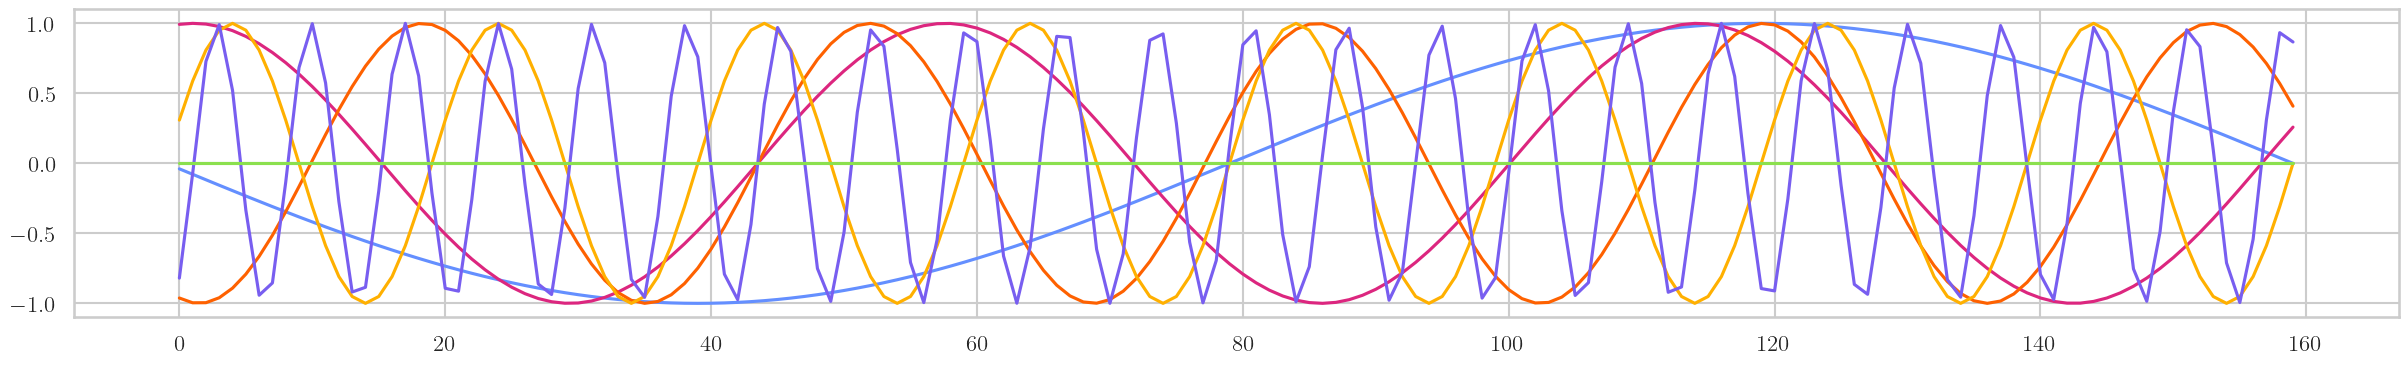

In [26]:
plt.figure(figsize=(30, 4))
sns.lineplot(X_pure_experiment2[0][1200 : 1200 + 160])
sns.lineplot(X_pure_experiment2[1][1200 : 1200 + 160])
sns.lineplot(X_pure_experiment2[2][1200 : 1200 + 160])
sns.lineplot(X_pure_experiment2[3][1200 : 1200 + 160])
sns.lineplot(X_pure_experiment2[4][1200 : 1200 + 160])
sns.lineplot(X_pure_experiment2[5][1200 : 1200 + 160])
plt.show()

In [27]:
print(experiment2_freqs)

# compute period sizes
[int(sr_experiment2 / freq) if freq != 0 else 0 for freq in experiment2_freqs]

[300, 840, 1420, 2400, 6780, 0]


[160, 57, 33, 20, 7, 0]

In [28]:
X = torch.Tensor(X_pure_experiment2).unsqueeze(1)
y = torch.eye(6, dtype=torch.float32)


class SensorConvModel(nn.Module):
    def __init__(self, output_dim, kernels, out_channels):
        super().__init__()
        num_kernels = len(kernels)
        self.convs = nn.ModuleList(
            [
                nn.Conv1d(
                    in_channels=1,
                    out_channels=out_channels,
                    kernel_size=k,
                    padding="same",
                )
                for k in kernels
            ]
        )
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(num_kernels * out_channels, output_dim)
        # self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        if self.training:
            # sigma = .1 * x.detach().std()
            # x = x + sigma * torch.randn_like(x)
            x = x + 0.1 * torch.randn_like(x)
            # x = self.dropout(x)

        outs = [self.pool(self.relu(conv(x))) for conv in self.convs]
        x = torch.cat(outs, dim=1)
        x = x.squeeze(-1)
        x = self.fc(x)
        return x

In [29]:
epochs = 100
kernels = [161, 57, 33, 21, 7]
out_channels = 8
lr = 0.1

## Train

In [30]:
# X = torch.Tensor(X_pure_experiment2).unsqueeze(1)
# y = torch.eye(6, dtype=torch.float32)
# # augment
# X_large = X.repeat_interleave(100, dim=0)
# y_large = y.repeat_interleave(100, dim=0)

# best_val_loss = float("inf")
# patience, p_counter = 5, 0
# min_delta = 1e-3
# sensor = SensorConvModel(output_dim=6, out_channels=out_channels, kernels=kernels)
# optimizer = torch.optim.Adam(
#     sensor.parameters(), lr=lr, weight_decay=1e-3
# )  # larger weight decay means more regularization

# loop = tqdm(range(epochs))
# losses = []
# for epoch in loop:
#     sensor.train()

#     indices = torch.randperm(X_large.shape[0])
#     X_large = X_large[indices]
#     y_large = y_large[indices]

#     optimizer.zero_grad()
#     logits = sensor(X_large)
#     log_probs = F.log_softmax(logits, dim=-1)
#     loss = F.kl_div(log_probs, y_large, reduction="batchmean")
#     loss.backward()
#     optimizer.step()

#     losses.append(loss.item())
#     loop.set_postfix_str(f"Epoch {epoch+1}: Loss: {loss.item():.8f}")

#     # early stopping
#     if best_val_loss - loss.item() > min_delta:
#         best_val_loss = loss.item()
#         p_counter = 0
#     else:
#         p_counter += 1
#         if p_counter >= patience:
#             print("Early Stopping!")
#             break
# sns.lineplot(losses)
# plt.xlabel("Epochs")
# plt.ylabel("KL Divergence")
# plt.title("Training Loss")
# plt.show()

In [31]:
# sensor.eval()
# sensor

# Freeze Model

In [32]:
# torch.save(sensor.state_dict(), "./models/sensor_multiscale_paper_v1.pth")

In [33]:
# load model

dim = 6
sensor = SensorConvModel(output_dim=6, out_channels=out_channels, kernels=kernels)
sensor.load_state_dict(
    torch.load("./models/sensor_multiscale_paper_v1.pth", weights_only=True)
)
sensor.eval()

SensorConvModel(
  (convs): ModuleList(
    (0): Conv1d(1, 8, kernel_size=(161,), stride=(1,), padding=same)
    (1): Conv1d(1, 8, kernel_size=(57,), stride=(1,), padding=same)
    (2): Conv1d(1, 8, kernel_size=(33,), stride=(1,), padding=same)
    (3): Conv1d(1, 8, kernel_size=(21,), stride=(1,), padding=same)
    (4): Conv1d(1, 8, kernel_size=(7,), stride=(1,), padding=same)
  )
  (relu): ReLU()
  (pool): AdaptiveMaxPool1d(output_size=1)
  (fc): Linear(in_features=40, out_features=6, bias=True)
)

In [34]:
detectability_threshold = 0.7

experiment2_label_names = [
    r"$T_{low}$",
    r"$C_{low}$",
    r"$C_{amb}$",
    r"$C_{high}$",
    r"$T_{high}$",
    r"$T_{omis}$",
]


def softmax(logits):
    exp_logits = np.exp(logits - np.max(logits))
    return exp_logits / exp_logits.sum()

In [35]:
# scales = np.array(list(reversed(np.round(np.arange(0.01, 0.51, 0.01), 2))))
# n_it = 50

# all_acc = []
# for _ in tqdm(range(n_it)):
#     acc = {code: [] for code in range(dim)}
#     for scale_tone in scales:
#         X_labels = np.concatenate([[i] * n_it for i in np.arange(6)])
#         X = torch.Tensor(
#             np.array([scale_tone * X_pure_experiment2[label] + e() for label in X_labels])
#         ).unsqueeze(1)
#         for code in range(dim):
#             idx = X_labels == code
#             obs = sensor(X).detach().numpy()[idx].squeeze()
#             # obs = np.array([softmax(o) for o in obs])  # this is for the FF model
#             S_pred = np.argmax(obs, axis=1)
#             score = np.sum(S_pred == X_labels[idx]) / X_labels[idx].size
#             acc[code].append(score)
#     all_acc.append(acc)

# plt.figure(figsize=(20, 4))
# data = np.array([list(all_acc[it].values()) for it in range(len(all_acc))])
# sns.heatmap(data[0], xticklabels=scales)

In [36]:
with open("./results/all_acc.pkl", "rb") as f:
    all_acc = pkl.load(f)

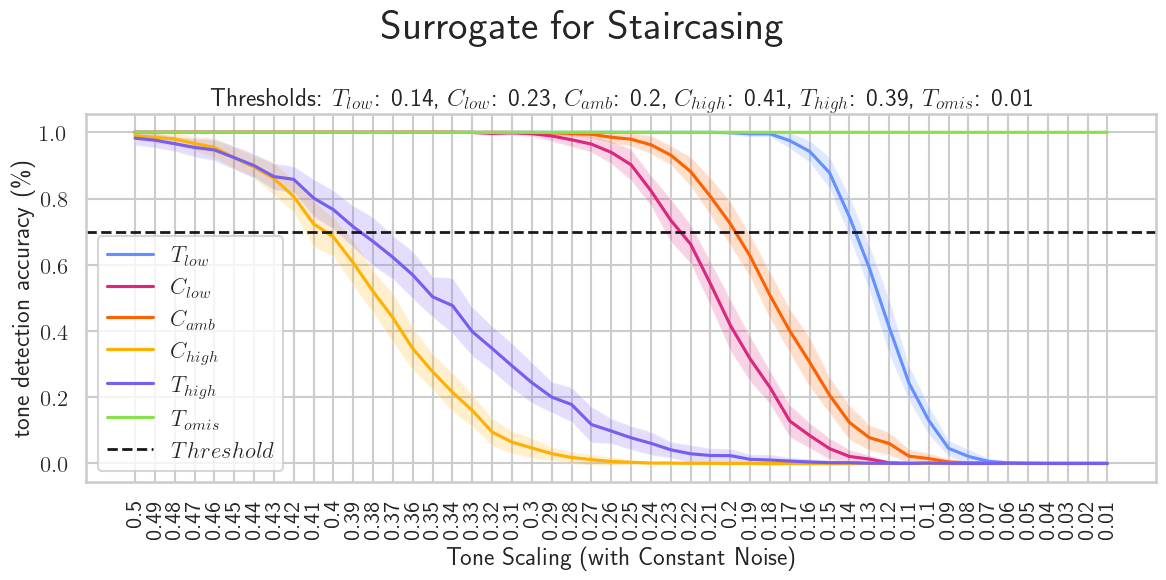

In [37]:
data = np.array([list(all_acc[it].values()) for it in range(len(all_acc))])
scales = np.array(list(reversed(np.round(np.arange(0.01, 0.51, 0.01), 2))))

n_it, n_tones, n_steps = data.shape

# compute mean and interval
data_means = np.mean(data, axis=0).T
data_stds = np.std(data, axis=0).T
thr = {
    experiment2_label_names[tone]: scales[
        np.where(np.array(np.mean(data, axis=0)[tone]) > detectability_threshold)
    ][-1]
    for tone in range(dim)
}

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
x_range = np.arange(n_steps)
for it in range(n_tones):
    sns.lineplot(
        x=x_range, y=data_means[:, it], ax=ax, label=experiment2_label_names[it]
    )
    ax.fill_between(
        x_range,
        data_means[:, it] - data_stds[:, it],
        data_means[:, it] + data_stds[:, it],
        alpha=0.2,
    )
ax.axhline(
    y=detectability_threshold,
    linestyle="--",
    alpha=1.0,
    c="k",
    linewidth=2,
    label="$Threshold$",
)
ax.set_ylabel(r"tone detection accuracy (\%)")
title = "Thresholds: " + ", ".join([f"{k}: {v}" for k, v in thr.items()])
ax.set_title(title)
ax.set_xticks(np.arange(len(scales)), scales, rotation=90)
ax.set_xlabel("Tone Scaling (with Constant Noise)")
ax.grid(True)
ax.legend()

plt.suptitle("Surrogate for Staircasing", fontweight="bold", fontsize=30)
plt.tight_layout()
plt.savefig("./behavioral_modeling_results/staircase_simulation.png", dpi=300)

plt.show()

In [38]:
[experiment2_label_names[tone] for tone in range(dim)]

['$T_{low}$',
 '$C_{low}$',
 '$C_{amb}$',
 '$C_{high}$',
 '$T_{high}$',
 '$T_{omis}$']

In [39]:
# # save threhsolds

# with open('./behavioral_modeling_results/tone_scalings.pkl', 'wb') as f:
#     pkl.dump(thr, f)

# Plot Sensor Model Output

In [40]:
tscale_experiment2 = np.array(list(thr.values()))
tscale_experiment2

array([0.14, 0.23, 0.2 , 0.41, 0.39, 0.01])

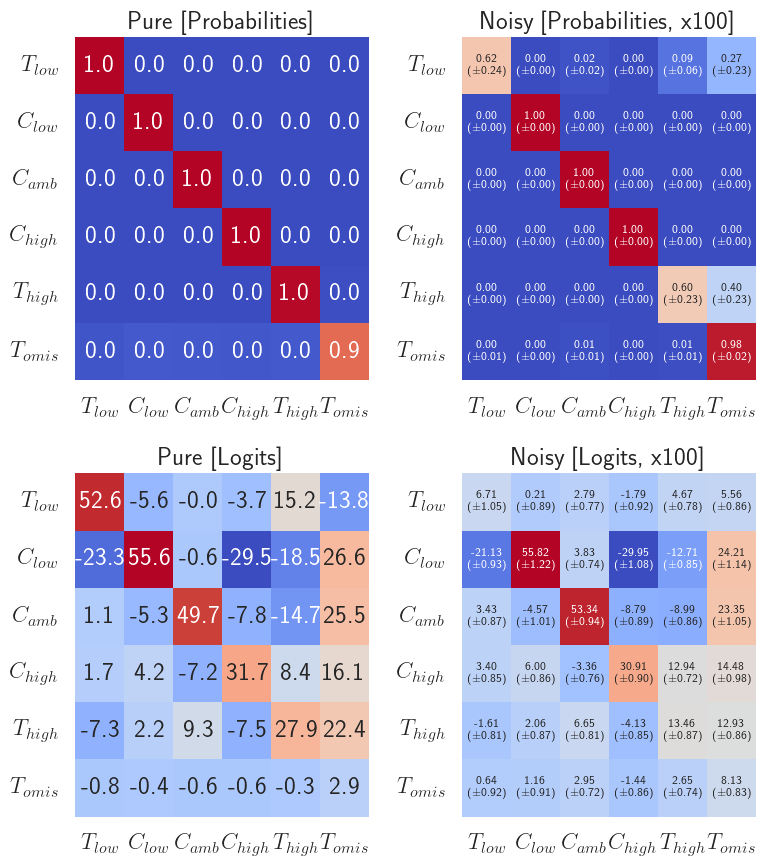

In [88]:
tscale_experiment2[1] = tscale_experiment2[2] = tscale_experiment2[3] = 1.0
tscale_experiment2

# check sensor decisions

plt.figure(figsize=(8, 9))

############### no noise ###############

obs = sensor(torch.Tensor(X_pure_experiment2).unsqueeze(1)).detach().numpy().squeeze()

ax = plt.subplot(221)
sns.heatmap(
    [softmax(o) for o in obs],
    cmap="coolwarm",
    cbar=False,
    annot=True,
    xticklabels=experiment2_label_names,
    yticklabels=experiment2_label_names,
    ax=ax,
    fmt=".1f",
)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_title("Pure [Probabilities]")
ax = plt.subplot(223)
sns.heatmap(
    obs,
    cmap="coolwarm",
    cbar=False,
    annot=True,
    xticklabels=experiment2_label_names,
    yticklabels=experiment2_label_names,
    ax=ax,
    fmt=".1f",
)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_title("Pure [Logits]")

############### added noise ###############

############### average over 100 times ###############
n_it = 100
obs = [
    sensor(
        torch.Tensor(
            np.array(
                [
                    tscale_experiment2[i] * x + e(idx)
                    for i, x in enumerate(X_pure_experiment2)
                ]
            )
        ).unsqueeze(1)
    )
    .detach()
    .numpy()
    .squeeze()
    for idx in range(n_it)
]
p_obs = np.array([[softmax(o) for o in o_mat] for o_mat in obs])

ax = plt.subplot(222)
p_obs_mean = np.mean(p_obs, axis=0)
annot = np.vectorize(lambda m, s: f"{m:.2f}\n(±{s:.2f})")(
    p_obs_mean, np.std(p_obs, axis=0)
)
sns.heatmap(
    p_obs_mean,
    cmap="coolwarm",
    cbar=False,
    annot=annot,
    annot_kws={"fontsize": 8},
    fmt="",
    xticklabels=experiment2_label_names,
    yticklabels=experiment2_label_names,
    ax=ax,
)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_title(f"Noisy [Probabilities, x{n_it}]")
ax = plt.subplot(224)
obs_mean = np.mean(obs, axis=0)
annot = np.vectorize(lambda m, s: f"{m:.2f}\n(±{s:.2f})")(obs_mean, np.std(obs, axis=0))
sns.heatmap(
    obs_mean,
    cmap="coolwarm",
    cbar=False,
    annot=annot,
    annot_kws={"fontsize": 8},
    fmt="",
    xticklabels=experiment2_label_names,
    yticklabels=experiment2_label_names,
    ax=ax,
)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_title(f"Noisy [Logits, x{n_it}]")

# plt.suptitle("Sampled Multiscale NN Sensor Model Predictions", fontweight="bold", fontsize=30)
plt.tight_layout()
plt.savefig("./behavioral_modeling_results/multiscale_conv_output_heatmap.png", dpi=300)

plt.show()

### Inspect entropy/Shannon surprize of outcomes

In [63]:
# p_obs = np.array([[softmax(o) for o in o_mat] for o_mat in obs])
# p_obs.shape

In [94]:
entropies = {}
target_indices = [0, 4, 5]
for idx in target_indices:
    label = experiment2_label_names[idx]
    entropies[label] = [100*_entropy(p_obs[:, idx][i])/np.log2(6) for i in range(len(p_obs))]

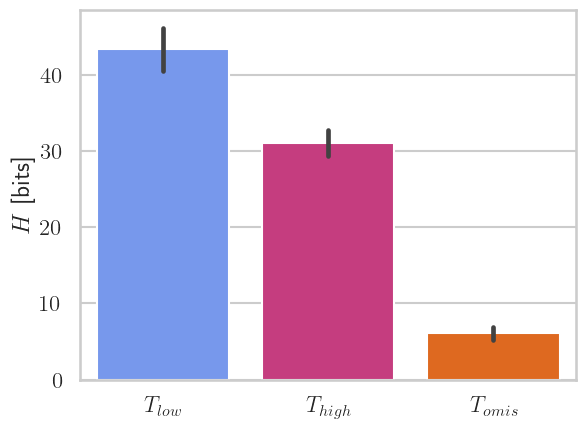

In [95]:
sns.barplot(entropies)
# plt.axhline(np.log2(6), c='k', linestyle='--', label='Maximum Entropy')
# plt.legend()
plt.ylabel('$H$ [bits]')
# plt.ylim(0, 3.2)
plt.savefig("./behavioral_modeling_results/multiscale_conv_output_entropy.png", dpi=300)


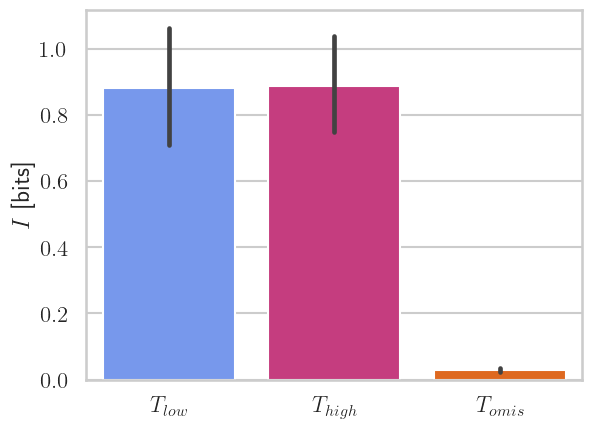

In [101]:
surprizes = {}
target_indices = [0, 4, 5]
for idx in target_indices:
    label = experiment2_label_names[idx]
    surprizes[label] = [-np.log2(p_obs[:, idx, idx][i]) for i in range(len(p_obs))]
sns.barplot(surprizes)
plt.ylabel('$I$ [bits]')
plt.savefig("./behavioral_modeling_results/multiscale_conv_output_shannon.png", dpi=300)


# Check which pairs were flipped

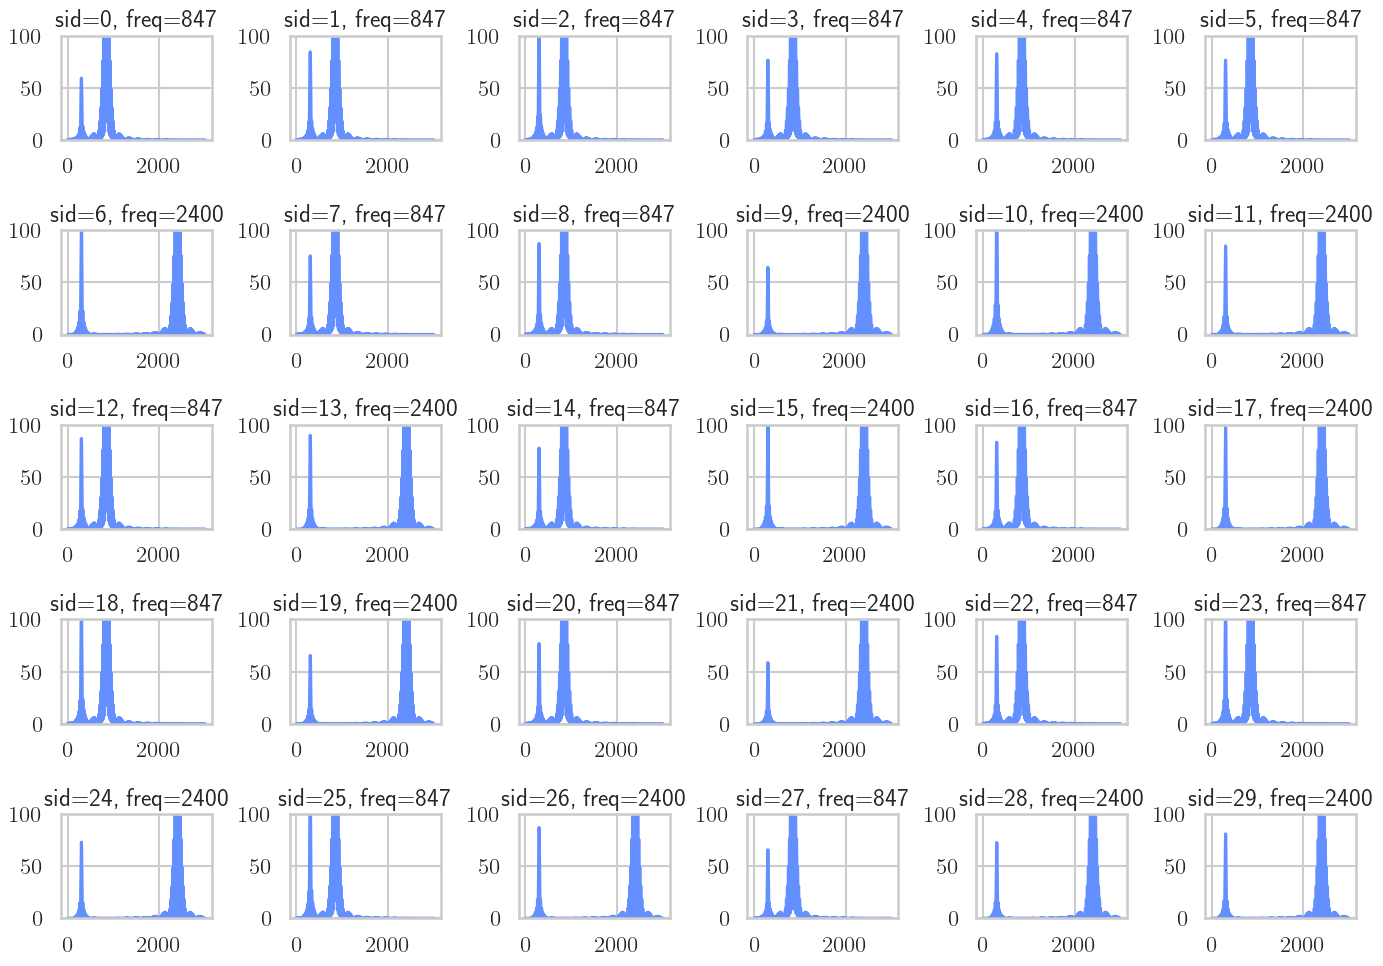

In [42]:
flip_subject_experiment2 = []
fig, axes = plt.subplots(5, 6, figsize=(14, 10))
for sid in range(30):
    ax = axes.ravel()[sid]
    tone = E_experiment2[sid].stim.tone_pairs[
        0
    ]  # get the first pair which you previously assumed to be low-low
    transform = np.abs(np.fft.fft(tone))
    freqs = np.fft.fftfreq(len(tone), 1 / sr_experiment2)
    idx = (freqs > 0) & (freqs < 3000)
    sns.lineplot(x=freqs[idx], y=np.abs(transform)[idx], ax=ax)
    freq = np.mean(np.abs(freqs[np.abs(transform) > 1000]))
    if freq < 2000:
        flip_subject_experiment2.append(False)
    else:
        flip_subject_experiment2.append(True)
    ax.set_title(f"sid={sid}, freq={int(freq)}")
    ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

---

## Generate Sequence Waveforms

#### Free variables
- 2 target scalings
- learning rate

Note: the cues should be loud!

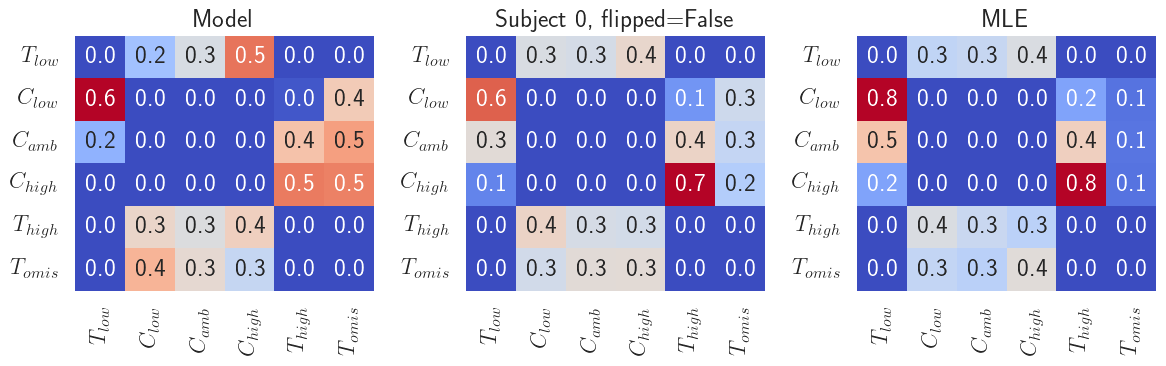

In [43]:
# lr = 0.01
n_subjects = 30

for sid in range(n_subjects):
    # create token sequence

    if flip_subject_experiment2[sid]:
        seq = np.concatenate(
            [
                np.array(list(map(pairs_experiment2_map_flipped.get, block))).ravel()
                for block in E_experiment2[sid].lists.mainTask
            ]
        )
    else:
        seq = np.concatenate(
            [
                np.array(list(map(pairs_experiment2_map.get, block))).ravel()
                for block in E_experiment2[sid].lists.mainTask
            ]
        )

    noise = generate_some_noise(
        len(seq)
    )  # precreate noise to prevent gaussianity and so on...

    seq_wave = generate_waveforms(
        seq, noise, tscale_experiment2, bias=0, X=X_pure_experiment2
    )

    # build model matrix
    model = SLIM(dim=6, sensor=sensor)
    model.fit(seq_wave, learning_rate=lr)

    # build subject matrix
    cues = seq[::2]
    if flip_subject_experiment2[sid]:
        subject_responses = np.array(
            list(
                map(
                    resp_to_state_experiment2_map_flipped.get,
                    E_experiment2[sid].resp.mainTask.resp.ravel(),
                )
            )
        )
    else:
        subject_responses = np.array(
            list(
                map(
                    resp_to_state_experiment2_map.get,
                    E_experiment2[sid].resp.mainTask.resp.ravel(),
                )
            )
        )
    subject_responses = np.concatenate(list(zip(cues, subject_responses)))
    subject_responses = subject_responses[subject_responses != -1]  # remove no response

    W_subject = calculate_MLE(subject_responses)
    W_mle = calculate_MLE(seq)

    plt.figure(figsize=(12, 4))

    ax = plt.subplot(131)
    sns.heatmap(
        model.W,
        cmap="coolwarm",
        annot=True,
        fmt=".1f",
        cbar=False,
        xticklabels=experiment2_label_names,
        yticklabels=experiment2_label_names,
        ax=ax,
    )
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_title("Model")

    ax = plt.subplot(132)
    sns.heatmap(
        W_subject,
        cmap="coolwarm",
        annot=True,
        fmt=".1f",
        cbar=False,
        xticklabels=experiment2_label_names,
        yticklabels=experiment2_label_names,
        ax=ax,
    )
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_title(f"Subject {sid}, flipped={flip_subject_experiment2[sid]}")

    ax = plt.subplot(133)
    sns.heatmap(
        W_mle,
        cmap="coolwarm",
        annot=True,
        fmt=".1f",
        cbar=False,
        xticklabels=experiment2_label_names,
        yticklabels=experiment2_label_names,
        ax=ax,
    )
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_title("MLE")

    plt.tight_layout()
    plt.show()
    break

# feed sequence waveforms to models and compute stats

In [44]:
# precreate all noise
n_subjects = 30  # exclude in loop
all_noise = [generate_some_noise(len(seq)) for _ in range(n_subjects)]

In [45]:
learning_rate = 0.01

all_models = []
all_subject_W = []
all_mle_W = []
all_model_responses = []
all_optimal_model_responses = []
all_model_surprizes = []
all_model_beliefs = []  # look at posteriors
all_subject_responses = []
all_optimal_responses = []
all_noresp_masks = []

all_model_log_ratios = []
all_model_kl_pred_obs = []
all_model_neglog_pred = []
all_model_neglog_post = []
all_model_priorentropies = []


for sid in tqdm(range(n_subjects)):
    # if exclusions_experiment2[sid]:
    #     print(f'skipping subject {sid}')
    #     continue

    if flip_subject_experiment2[sid]:
        seq = np.concatenate(
            [
                np.array(list(map(pairs_experiment2_map_flipped.get, block))).ravel()
                for block in E_experiment2[sid].lists.mainTask
            ]
        )
    else:
        seq = np.concatenate(
            [
                np.array(list(map(pairs_experiment2_map.get, block))).ravel()
                for block in E_experiment2[sid].lists.mainTask
            ]
        )

    cues = seq[::2]
    seq_wave = generate_waveforms(
        seq, all_noise[sid], tscale_experiment2, bias=0, X=X_pure_experiment2
    )

    model = SLIM(dim=6, sensor=sensor)
    model.fit(seq_wave, learning_rate=learning_rate)
    all_models.append(model)

    if flip_subject_experiment2[sid]:
        subject_responses = np.array(
            list(
                map(
                    resp_to_state_experiment2_map_flipped.get,
                    E_experiment2[sid].resp.mainTask.resp.ravel(),
                )
            )
        )
    else:
        subject_responses = np.array(
            list(
                map(
                    resp_to_state_experiment2_map.get,
                    E_experiment2[sid].resp.mainTask.resp.ravel(),
                )
            )
        )
    all_subject_responses.append(
        subject_responses.reshape(11, subject_responses.size // 11)[:, 12:]
    )
    subject_responses = np.concatenate(list(zip(cues, subject_responses)))

    no_resp_mask = subject_responses != -1
    no_resp_mask[np.where(no_resp_mask == False)[0] - 1] = (
        False  # mask out the cue as wel
    )
    all_noresp_masks.append(no_resp_mask)  # save it for later

    subject_responses[subject_responses == -1] = 5  # fake it for the matrix estimate
    all_subject_W.append(calculate_MLE(subject_responses))
    all_mle_W.append(calculate_MLE(seq))

    model_responses = np.argmax(model.bel, axis=1)[1::2]  # extract targets only
    model_responses = model_responses.reshape(11, model_responses.size // 11)
    model_responses = model_responses[:, 12:]
    all_model_responses.append(model_responses)

    surprizes = np.array(model.surprise_hist)[1::2]  # extract targets only
    surprizes = surprizes.reshape(11, surprizes.size // 11)
    surprizes = surprizes[:, 12:]
    all_model_surprizes.append(surprizes)

    beliefs = np.array(model.bel)[1::2]  # extract targets only
    beliefs = beliefs.reshape(11, beliefs.size // 11 // 6, 6)
    beliefs = beliefs[:, 12:]
    all_model_beliefs.append(beliefs)

    optimal_responses = seq[1::2]
    optimal_responses = optimal_responses.reshape(11, optimal_responses.size // 11)[
        :, 12:
    ]
    all_optimal_responses.append(optimal_responses)

    # optimal model
    optimal_model = SLIM(dim=6, sensor=np.eye(6, dtype=np.float32))
    optimal_model.fit(seq, learning_rate=learning_rate)
    optimal_model_responses = np.argmax(optimal_model.bel, axis=1)[
        1::2
    ]  # extract targets only
    optimal_model_responses = optimal_model_responses.reshape(
        11, optimal_model_responses.size // 11
    )
    optimal_model_responses = optimal_model_responses[:, 12:]
    all_optimal_model_responses.append(optimal_model_responses)

    posteriors = model.bel[1::2].reshape(11, 1397 // 11, 6)[:, 12:, :]

    all_log_ratios = []
    for block in range(11):
        log_ratios = []
        for trial in range(115):
            true_state_idx = optimal_responses[block][trial]
            posteior_of_true_state = posteriors[block][trial][true_state_idx]
            posteior_of_omission = posteriors[block][trial][-1]

            log_ratio = np.log2(posteior_of_true_state / posteior_of_omission)
            log_ratios.append(log_ratio)
        all_log_ratios.append(log_ratios)
    all_log_ratios = np.array(all_log_ratios)
    all_model_log_ratios.append(all_log_ratios)

    # kl pred obs
    kls = np.array(
        [
            kl_div(p, q)
            for p, q in zip(np.array(model.x_hat_hist), np.array(model.y_hist))
        ]
    )[1::2].reshape(11, 1397 // 11)[:, 12:]
    all_model_kl_pred_obs.append(kls)

    # neg log pred
    priors = np.array(model.x_hat_hist)[1::2].reshape(11, 1397 // 11, 6)[:, 12:, :]
    all_neglog_pred = []
    for block in range(11):
        nl_preds = []
        for trial in range(115):
            true_state_idx = optimal_responses[block][trial]
            prior_of_true_state = priors[block][trial][true_state_idx]
            prior_of_omission = priors[block][trial][-1]

            surp_prior = -np.log2(prior_of_true_state)
            nl_preds.append(surp_prior)
        all_neglog_pred.append(nl_preds)
    all_model_neglog_pred.append(np.array(all_neglog_pred))

    # shannon
    all_neglog_post = []
    for block in range(11):
        nl_posts = []
        for trial in range(115):
            true_state_idx = optimal_responses[block][trial]
            posterior_of_true_state = posteriors[block][trial][true_state_idx]

            surp_posterior = -np.log2(posterior_of_true_state)
            nl_posts.append(surp_posterior)
        all_neglog_post.append(nl_posts)
    all_model_neglog_post.append(np.array(all_neglog_post))

    # add prior entorpies
    prior_entropies = []
    for block in range(11):
        _ent = []
        for trial in range(115):
            _ent.append(_entropy(priors[block][trial]))
        prior_entropies.append(_ent)
    all_model_priorentropies.append(prior_entropies)

  0%|          | 0/30 [00:00<?, ?it/s]/home/mahdi/anaconda3/lib/python3.12/site-packages/slim/utils.py:10: RuntimeWarning: divide by zero encountered in log2
  return np.nansum(p * (np.log2(p + 1e-10) - np.log2(q + 1e-10)))
100%|██████████| 30/30 [01:20<00:00,  2.68s/it]


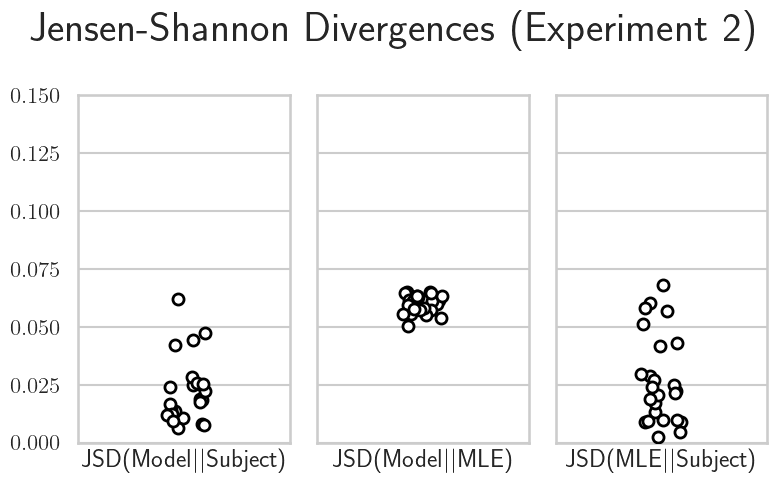

In [46]:
all_models = np.array(all_models)[~exclusions_experiment2]
all_subject_W = np.array(all_subject_W)[~exclusions_experiment2]
all_mle_W = np.array(all_mle_W)[~exclusions_experiment2]

fig, ax = plt.subplots(1, 3, figsize=(8, 5))

jsds = [
    [
        _jsd_avg(model.W, W_subject)
        for model, W_subject in zip(all_models, all_subject_W)
    ]
]
sns.stripplot(
    jsds,
    jitter=True,
    color="white",
    size=8,
    marker="o",
    edgecolor="black",
    linewidth=2,
    alpha=1,
    ax=ax[0],
)
ax[0].set_ylim(0.0, 0.15)
ax[0].set_xlabel(r"JSD(Model$\mid\mid$Subject)")
ax[0].tick_params(labelbottom=False)

jsds = [[_jsd_avg(model.W, W_mle) for model, W_mle in zip(all_models, all_mle_W)]]
sns.stripplot(
    jsds,
    jitter=True,
    color="white",
    size=8,
    marker="o",
    edgecolor="black",
    linewidth=2,
    alpha=1,
    ax=ax[1],
)
ax[1].set_ylim(0.0, 0.15)
ax[1].set_xlabel(r"JSD(Model$\mid\mid$MLE)")
ax[1].tick_params(labelbottom=False, labelleft=False)

jsds = [
    [_jsd_avg(W_mle, W_subject) for W_mle, W_subject in zip(all_mle_W, all_subject_W)]
]
sns.stripplot(
    jsds,
    jitter=True,
    color="white",
    size=8,
    marker="o",
    edgecolor="black",
    linewidth=2,
    alpha=1,
    ax=ax[2],
)
ax[2].set_ylim(0.0, 0.15)
ax[2].set_xlabel(r"JSD(MLE$\mid\mid$Subject)")
ax[2].tick_params(labelbottom=False, labelleft=False)

plt.suptitle(
    "Jensen-Shannon Divergences (Experiment 2)", fontweight="bold", fontsize=30
)
plt.tight_layout()
plt.savefig("./behavioral_modeling_results/divergences_experiment2.png", dpi=300)

plt.show()

In [47]:
model_to_resp_experiment2_map_flipped = {0: 2, 4: 1, 5: 3}

# prepare model data

all_surprize_exp_model_blockwise = {}
all_surprize_une_model_blockwise = {}
all_surprize_amb_model_blockwise = {}

all_belief_exp1_model_blockwise = {}
all_belief_une1_model_blockwise = {}
all_belief_amb1_model_blockwise = {}
all_belief_exp2_model_blockwise = {}
all_belief_une2_model_blockwise = {}
all_belief_amb2_model_blockwise = {}

all_belief_exp_model_blockwise = {}
all_belief_une_model_blockwise = {}
all_belief_amb_model_blockwise = {}

all_priorentropies_exp_model_blockwise = {}
all_priorentropies_une_model_blockwise = {}
all_priorentropies_amb_model_blockwise = {}

all_dprime_exp_model_blockwise = {}
all_dprime_une_model_blockwise = {}
all_dprime_amb_model_blockwise = {}
all_criterion_exp_model_blockwise = {}
all_criterion_une_model_blockwise = {}
all_criterion_amb_model_blockwise = {}

all_log_ratios_exp_model_blockwise = {}
all_log_ratios_une_model_blockwise = {}
all_log_ratios_amb_model_blockwise = {}

all_kl_pred_obs_exp_model_blockwise = {}
all_kl_pred_obs_une_model_blockwise = {}
all_kl_pred_obs_amb_model_blockwise = {}

all_model_neglog_pred_exp_blockwise = {}
all_model_neglog_pred_une_blockwise = {}
all_model_neglog_pred_amb_blockwise = {}

all_model_neglog_post_exp_blockwise = {}
all_model_neglog_post_une_blockwise = {}
all_model_neglog_post_amb_blockwise = {}

for block in range(11):

    all_surprize_amb_model_blockwise[block] = []
    all_surprize_exp_model_blockwise[block] = []
    all_surprize_une_model_blockwise[block] = []

    all_belief_amb1_model_blockwise[block] = []
    all_belief_exp1_model_blockwise[block] = []
    all_belief_une1_model_blockwise[block] = []
    all_belief_amb2_model_blockwise[block] = []
    all_belief_exp2_model_blockwise[block] = []
    all_belief_une2_model_blockwise[block] = []

    all_belief_amb_model_blockwise[block] = []
    all_belief_exp_model_blockwise[block] = []
    all_belief_une_model_blockwise[block] = []

    all_priorentropies_amb_model_blockwise[block] = []
    all_priorentropies_exp_model_blockwise[block] = []
    all_priorentropies_une_model_blockwise[block] = []

    all_dprime_exp_model_blockwise[block] = []
    all_dprime_une_model_blockwise[block] = []
    all_dprime_amb_model_blockwise[block] = []
    all_criterion_exp_model_blockwise[block] = []
    all_criterion_une_model_blockwise[block] = []
    all_criterion_amb_model_blockwise[block] = []

    all_log_ratios_exp_model_blockwise[block] = []
    all_log_ratios_une_model_blockwise[block] = []
    all_log_ratios_amb_model_blockwise[block] = []

    all_kl_pred_obs_exp_model_blockwise[block] = []  #
    all_kl_pred_obs_une_model_blockwise[block] = []  #
    all_kl_pred_obs_amb_model_blockwise[block] = []  #

    all_model_neglog_pred_exp_blockwise[block] = []  #
    all_model_neglog_pred_une_blockwise[block] = []  #
    all_model_neglog_pred_amb_blockwise[block] = []  #

    all_model_neglog_post_exp_blockwise[block] = []  #
    all_model_neglog_post_une_blockwise[block] = []  #
    all_model_neglog_post_amb_blockwise[block] = []  #

    for sid in range(30):
        if exclusions_experiment2[sid]:
            continue

        conditions = E_experiment2[sid].lists.mainTask[block, 12:]
        model_responses = all_model_responses[sid][block]

        if flip_subject_experiment2[sid]:
            model_responses = np.array(
                list(map(model_to_resp_experiment2_map_flipped.get, model_responses))
            )
        else:
            model_responses = np.array(
                list(map(model_to_resp_experiment2_map.get, model_responses))
            )

        exp1_indices = (conditions == 1) & (model_responses == 1)
        exp2_indices = (conditions == 2) & (model_responses == 2)
        une1_indices = (conditions == 3) & (model_responses == 2)
        une2_indices = (conditions == 4) & (model_responses == 1)
        amb1_indices = (conditions == 7) & (model_responses == 1)
        amb2_indices = (conditions == 8) & (model_responses == 2)

        # surprizes
        surprize_exp1 = np.nanmedian(all_model_surprizes[sid][block][exp1_indices])
        surprize_exp2 = np.nanmedian(all_model_surprizes[sid][block][exp2_indices])
        surprize_exp = np.nanmean([surprize_exp1, surprize_exp2])
        all_surprize_exp_model_blockwise[block].append(surprize_exp)

        surprize_une1 = np.nanmedian(all_model_surprizes[sid][block][une1_indices])
        surprize_une2 = np.nanmedian(all_model_surprizes[sid][block][une2_indices])
        surprize_une = np.nanmean([surprize_une1, surprize_une2])
        all_surprize_une_model_blockwise[block].append(surprize_une)

        surprize_amb1 = np.nanmedian(all_model_surprizes[sid][block][amb1_indices])
        surprize_amb2 = np.nanmedian(all_model_surprizes[sid][block][amb2_indices])
        surprize_amb = np.nanmean([surprize_amb1, surprize_amb2])
        all_surprize_amb_model_blockwise[block].append(surprize_amb)

        belief_exp1 = np.nanmean(all_model_beliefs[sid][block][exp1_indices], axis=0)
        belief_exp2 = np.nanmean(all_model_beliefs[sid][block][exp2_indices], axis=0)
        all_belief_exp1_model_blockwise[block].append(belief_exp1)
        all_belief_exp2_model_blockwise[block].append(belief_exp2)
        all_belief_exp_model_blockwise[block].append(
            np.nanmean([belief_exp1, belief_exp2])
        )

        belief_une1 = np.nanmean(all_model_beliefs[sid][block][une1_indices], axis=0)
        belief_une2 = np.nanmean(all_model_beliefs[sid][block][une2_indices], axis=0)
        all_belief_une1_model_blockwise[block].append(belief_une1)
        all_belief_une2_model_blockwise[block].append(belief_une2)
        all_belief_une_model_blockwise[block].append(
            np.nanmean([belief_une1, belief_une2])
        )

        belief_amb1 = np.nanmean(all_model_beliefs[sid][block][amb1_indices], axis=0)
        belief_amb2 = np.nanmean(all_model_beliefs[sid][block][amb2_indices], axis=0)
        # belief_amb = np.nanmean([belief_amb1, belief_amb2], axis=0)
        all_belief_amb1_model_blockwise[block].append(belief_amb1)
        all_belief_amb2_model_blockwise[block].append(belief_amb2)
        all_belief_amb_model_blockwise[block].append(
            np.nanmean([belief_amb1, belief_amb2])
        )

        ## prior entropies

        priorentropie_exp1 = np.nanmean(
            np.array(all_model_priorentropies)[sid][block][exp1_indices], axis=0
        )
        priorentropie_exp2 = np.nanmean(
            np.array(all_model_priorentropies)[sid][block][exp2_indices], axis=0
        )
        all_priorentropies_exp_model_blockwise[block].append(
            np.nanmean([priorentropie_exp1, priorentropie_exp2])
        )

        priorentropie_une1 = np.nanmean(
            np.array(all_model_priorentropies)[sid][block][une1_indices], axis=0
        )
        priorentropie_une2 = np.nanmean(
            np.array(all_model_priorentropies)[sid][block][une2_indices], axis=0
        )
        all_priorentropies_une_model_blockwise[block].append(
            np.nanmean([priorentropie_une1, priorentropie_une2])
        )

        priorentropie_amb1 = np.nanmean(
            np.array(all_model_priorentropies)[sid][block][amb1_indices], axis=0
        )
        priorentropie_amb2 = np.nanmean(
            np.array(all_model_priorentropies)[sid][block][amb2_indices], axis=0
        )
        all_priorentropies_amb_model_blockwise[block].append(
            np.nanmean([priorentropie_amb1, priorentropie_amb2])
        )

        # SDT

        # dprime
        # exp
        acc_exp = np.nanmean(
            [
                (sum(model_responses[conditions == 1] == 1) + 0.5)
                / (sum(conditions == 1) + 1),
                (sum(model_responses[conditions == 2] == 2) + 0.5)
                / (sum(conditions == 2) + 1),
            ]
        )
        fa_exp = np.nanmean(
            [
                (sum(model_responses[conditions == 5] == 1) + 0.5)
                / (sum(conditions == 5) + 1),
                (sum(model_responses[conditions == 6] == 2) + 0.5)
                / (sum(conditions == 6) + 1),
            ]
        )
        dPrime_exp = stats.norm.ppf(acc_exp) - stats.norm.ppf(fa_exp)
        all_dprime_exp_model_blockwise[block].append(dPrime_exp)
        # une
        acc_une = np.nanmean(
            [
                (sum(model_responses[conditions == 3] == 2) + 0.5)
                / (sum(conditions == 3) + 1),
                (sum(model_responses[conditions == 4] == 1) + 0.5)
                / (sum(conditions == 4) + 1),
            ]
        )
        fa_une = np.nanmean(
            [
                (sum(model_responses[conditions == 5] == 2) + 0.5)
                / (sum(conditions == 5) + 1),
                (sum(model_responses[conditions == 6] == 1) + 0.5)
                / (sum(conditions == 6) + 1),
            ]
        )
        dPrime_une = stats.norm.ppf(acc_une) - stats.norm.ppf(fa_une)
        all_dprime_une_model_blockwise[block].append(dPrime_une)
        # amb
        acc_amb = np.nanmean(
            [
                (sum(model_responses[conditions == 7] == 1) + 0.5)
                / (sum(conditions == 7) + 1),
                (sum(model_responses[conditions == 8] == 2) + 0.5)
                / (sum(conditions == 8) + 1),
            ]
        )
        fa_amb = np.nanmean(
            [
                (sum(model_responses[conditions == 9] == 1) + 0.5)
                / (sum(conditions == 9) + 1),
                (sum(model_responses[conditions == 9] == 2) + 0.5)
                / (sum(conditions == 9) + 1),
            ]
        )
        dPrime_amb = stats.norm.ppf(acc_amb) - stats.norm.ppf(fa_amb)
        all_dprime_amb_model_blockwise[block].append(dPrime_amb)

        # criterion
        criterion_exp = -0.5 * (stats.norm.ppf(acc_exp) + stats.norm.ppf(fa_exp))
        all_criterion_exp_model_blockwise[block].append(criterion_exp)

        criterion_une = -0.5 * (stats.norm.ppf(acc_une) + stats.norm.ppf(fa_une))
        all_criterion_une_model_blockwise[block].append(criterion_une)

        criterion_amb = -0.5 * (stats.norm.ppf(acc_amb) + stats.norm.ppf(fa_amb))
        all_criterion_amb_model_blockwise[block].append(criterion_amb)

        # log ratios
        log_ratio_exp1 = np.nanmean(
            all_model_log_ratios[sid][block][exp1_indices], axis=0
        )
        log_ratio_exp2 = np.nanmean(
            all_model_log_ratios[sid][block][exp2_indices], axis=0
        )
        all_log_ratios_exp_model_blockwise[block].append(
            np.nanmean([log_ratio_exp1, log_ratio_exp2])
        )

        log_ratio_une1 = np.nanmean(
            all_model_log_ratios[sid][block][une1_indices], axis=0
        )
        log_ratio_une2 = np.nanmean(
            all_model_log_ratios[sid][block][une2_indices], axis=0
        )
        all_log_ratios_une_model_blockwise[block].append(
            np.nanmean([log_ratio_une1, log_ratio_une2])
        )

        log_ratio_amb1 = np.nanmean(
            all_model_log_ratios[sid][block][amb1_indices], axis=0
        )
        log_ratio_amb2 = np.nanmean(
            all_model_log_ratios[sid][block][amb2_indices], axis=0
        )
        all_log_ratios_amb_model_blockwise[block].append(
            np.nanmean([log_ratio_amb1, log_ratio_amb2])
        )

        # kl pred obs
        kl_pred_obs_exp1 = np.nanmean(
            all_model_kl_pred_obs[sid][block][exp1_indices], axis=0
        )
        kl_pred_obs_exp2 = np.nanmean(
            all_model_kl_pred_obs[sid][block][exp2_indices], axis=0
        )
        all_kl_pred_obs_exp_model_blockwise[block].append(
            np.nanmean([kl_pred_obs_exp1, kl_pred_obs_exp2])
        )

        kl_pred_obs_une1 = np.nanmean(
            all_model_kl_pred_obs[sid][block][une1_indices], axis=0
        )
        kl_pred_obs_une2 = np.nanmean(
            all_model_kl_pred_obs[sid][block][une2_indices], axis=0
        )
        all_kl_pred_obs_une_model_blockwise[block].append(
            np.nanmean([kl_pred_obs_une1, kl_pred_obs_une2])
        )

        kl_pred_obs_amb1 = np.nanmean(
            all_model_kl_pred_obs[sid][block][amb1_indices], axis=0
        )
        kl_pred_obs_amb2 = np.nanmean(
            all_model_kl_pred_obs[sid][block][amb2_indices], axis=0
        )
        all_kl_pred_obs_amb_model_blockwise[block].append(
            np.nanmean([kl_pred_obs_amb1, kl_pred_obs_amb2])
        )

        # nlprior
        nlp_exp1 = np.nanmean(all_model_neglog_pred[sid][block][exp1_indices], axis=0)
        nlp_exp2 = np.nanmean(all_model_neglog_pred[sid][block][exp2_indices], axis=0)
        all_model_neglog_pred_exp_blockwise[block].append(
            np.nanmean([nlp_exp1, nlp_exp2])
        )

        nlp_une1 = np.nanmean(all_model_neglog_pred[sid][block][une1_indices], axis=0)
        nlp_une2 = np.nanmean(all_model_neglog_pred[sid][block][une2_indices], axis=0)
        all_model_neglog_pred_une_blockwise[block].append(
            np.nanmean([nlp_une1, nlp_une2])
        )

        nlp_amb1 = np.nanmean(all_model_neglog_pred[sid][block][amb1_indices], axis=0)
        nlp_amb2 = np.nanmean(all_model_neglog_pred[sid][block][amb2_indices], axis=0)
        all_model_neglog_pred_amb_blockwise[block].append(
            np.nanmean([nlp_amb1, nlp_amb2])
        )

        # nlpost
        nlp_exp1 = np.nanmean(all_model_neglog_post[sid][block][exp1_indices], axis=0)
        nlp_exp2 = np.nanmean(all_model_neglog_post[sid][block][exp2_indices], axis=0)
        all_model_neglog_post_exp_blockwise[block].append(
            np.nanmean([nlp_exp1, nlp_exp2])
        )

        nlp_une1 = np.nanmean(all_model_neglog_post[sid][block][une1_indices], axis=0)
        nlp_une2 = np.nanmean(all_model_neglog_post[sid][block][une2_indices], axis=0)
        all_model_neglog_post_une_blockwise[block].append(
            np.nanmean([nlp_une1, nlp_une2])
        )

        nlp_amb1 = np.nanmean(all_model_neglog_post[sid][block][amb1_indices], axis=0)
        nlp_amb2 = np.nanmean(all_model_neglog_post[sid][block][amb2_indices], axis=0)
        all_model_neglog_post_amb_blockwise[block].append(
            np.nanmean([nlp_amb1, nlp_amb2])
        )

/home/mahdi/anaconda3/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/tmp/ipykernel_2062843/4245064265.py:138: RuntimeWarning: Mean of empty slice
  belief_une1 = np.nanmean(all_model_beliefs[sid][block][une1_indices], axis=0)
/tmp/ipykernel_2062843/4245064265.py:167: RuntimeWarning: Mean of empty slice
  priorentropie_une1 = np.nanmean(
/tmp/ipykernel_2062843/4245064265.py:269: RuntimeWarning: Mean of empty slice
  log_ratio_une1 = np.nanmean(
/tmp/ipykernel_2062843/4245064265.py:300: RuntimeWarning: Mean of empty slice
  kl_pred_obs_une1 = np.nanmean(
/tmp/ipykernel_2062843/4245064265.py:327: RuntimeWarning: Mean of empty slice
  nlp_une1 = np.nanmean(all_model_neglog_pred[sid][block][une1_indices], axis=0)
/tmp/ipykernel_2062843/4245064265.py:346: RuntimeWarning: Mean of empty slice
  nlp_une1 = np.nanmean(all_model_neglog_post[sid][block][une1_indices], axis=0)
/tmp/ipykernel_

In [48]:
all_acc_exp_model = []
all_acc_une_model = []
all_acc_amb_model = []

all_fa_exp_model = []
all_fa_une_model = []
all_fa_amb_model = []

all_dPrime_exp_model = []
all_dPrime_une_model = []
all_dPrime_amb_model = []
all_criterion_exp_model = []
all_criterion_une_model = []
all_criterion_amb_model = []

for sid in range(30):
    if exclusions_experiment2[sid]:
        continue

    conditions = E_experiment2[sid].lists.mainTask[:, 12:].ravel()
    model_responses = all_model_responses[sid].ravel()

    if flip_subject_experiment2[sid]:
        model_responses = np.array(
            list(map(model_to_resp_experiment2_map_flipped.get, model_responses))
        )
    else:
        model_responses = np.array(
            list(map(model_to_resp_experiment2_map.get, model_responses))
        )
    # log-linear correction / Laplace smoothing
    acc_exp1 = (
        sum(model_responses[conditions == 1] == conditions[conditions == 1]) + 0.5
    ) / (sum(conditions == 1) + 1)
    acc_exp2 = (
        sum(model_responses[conditions == 2] == conditions[conditions == 2]) + 0.5
    ) / (sum(conditions == 2) + 1)
    acc_exp = np.nanmean([acc_exp1, acc_exp2])
    all_acc_exp_model.append(acc_exp)

    acc_une1 = (sum(model_responses[conditions == 3] == 2) + 0.5) / (
        sum(conditions == 3) + 1
    )
    acc_une2 = (sum(model_responses[conditions == 4] == 1) + 0.5) / (
        sum(conditions == 4) + 1
    )
    acc_une = np.nanmean([acc_une1, acc_une2])
    all_acc_une_model.append(acc_une)

    acc_amb1 = (sum(model_responses[conditions == 7] == 1) + 0.5) / (
        sum(conditions == 7) + 1
    )
    acc_amb2 = (sum(model_responses[conditions == 8] == 2) + 0.5) / (
        sum(conditions == 8) + 1
    )
    acc_amb = np.nanmean([acc_amb1, acc_amb2])
    all_acc_amb_model.append(acc_amb)

    ############### false alarms ###############

    fa_exp1 = (sum(model_responses[conditions == 5] == 1) + 0.5) / (
        sum(conditions == 5) + 1
    )
    fa_exp2 = (sum(model_responses[conditions == 6] == 2) + 0.5) / (
        sum(conditions == 6) + 1
    )
    fa_exp = np.nanmean([fa_exp1, fa_exp2])
    all_fa_exp_model.append(fa_exp)

    fa_une1 = (sum(model_responses[conditions == 5] == 2) + 0.5) / (
        sum(conditions == 5) + 1
    )
    fa_une2 = (sum(model_responses[conditions == 6] == 1) + 0.5) / (
        sum(conditions == 6) + 1
    )
    fa_une = np.nanmean([fa_une1, fa_une2])
    all_fa_une_model.append(fa_une)

    fa_amb1 = (sum(model_responses[conditions == 9] == 1) + 0.5) / (
        sum(conditions == 9) + 1
    )
    fa_amb2 = (sum(model_responses[conditions == 9] == 2) + 0.5) / (
        sum(conditions == 9) + 1
    )
    fa_amb = np.nanmean([fa_amb1, fa_amb2])
    all_fa_amb_model.append(fa_amb)

    ############### d Prime ###############

    dPrime_exp = stats.norm.ppf(acc_exp) - stats.norm.ppf(fa_exp)
    all_dPrime_exp_model.append(dPrime_exp)

    dPrime_une = stats.norm.ppf(acc_une) - stats.norm.ppf(fa_une)
    all_dPrime_une_model.append(dPrime_une)

    dPrime_amb = stats.norm.ppf(acc_amb) - stats.norm.ppf(fa_amb)
    all_dPrime_amb_model.append(dPrime_amb)

    ############### criterion ###############

    criterion_exp = -0.5 * (stats.norm.ppf(acc_exp) + stats.norm.ppf(fa_exp))
    all_criterion_exp_model.append(criterion_exp)

    criterion_une = -0.5 * (stats.norm.ppf(acc_une) + stats.norm.ppf(fa_une))
    all_criterion_une_model.append(criterion_une)

    criterion_amb = -0.5 * (stats.norm.ppf(acc_amb) + stats.norm.ppf(fa_amb))
    all_criterion_amb_model.append(criterion_amb)

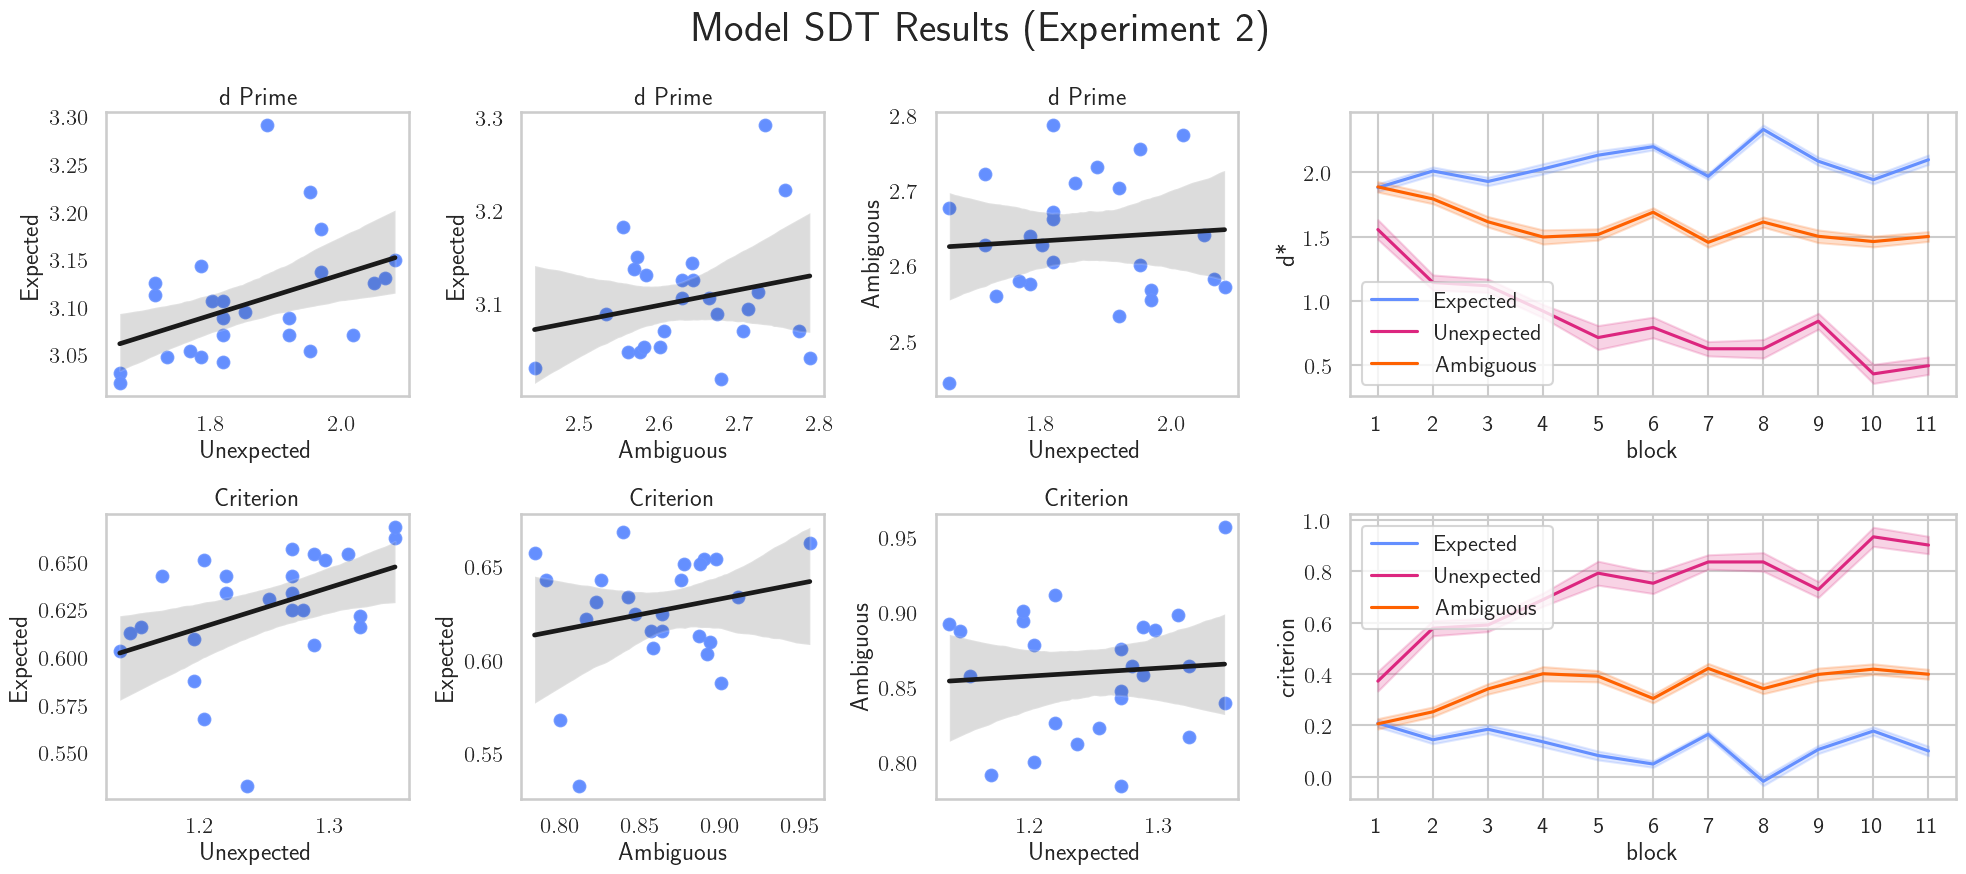

In [49]:
fig, ax = plt.subplots(
    2, 4, figsize=(20, 9), gridspec_kw={"width_ratios": [2, 2, 2, 4]}
)

sns.scatterplot(x=all_dPrime_une_model, y=all_dPrime_exp_model, ax=ax[0][0])
sns.regplot(
    x=all_dPrime_une_model, y=all_dPrime_exp_model, line_kws={"color": "k"}, ax=ax[0][0]
)
ax[0][0].set_xlabel("Unexpected")
ax[0][0].set_ylabel("Expected")
ax[0][0].set_title("d Prime")
ax[0][0].grid(False)

sns.scatterplot(x=all_dPrime_amb_model, y=all_dPrime_exp_model, ax=ax[0][1])
sns.regplot(
    x=all_dPrime_amb_model, y=all_dPrime_exp_model, line_kws={"color": "k"}, ax=ax[0][1]
)
ax[0][1].set_xlabel("Ambiguous")
ax[0][1].set_ylabel("Expected")
ax[0][1].set_title("d Prime")
ax[0][1].grid(False)

sns.scatterplot(x=all_dPrime_une_model, y=all_dPrime_amb_model, ax=ax[0][2])
sns.regplot(
    x=all_dPrime_une_model, y=all_dPrime_amb_model, line_kws={"color": "k"}, ax=ax[0][2]
)
ax[0][2].set_xlabel("Unexpected")
ax[0][2].set_ylabel("Ambiguous")
ax[0][2].set_title("d Prime")
ax[0][2].grid(False)

df = (
    pd.DataFrame(all_dprime_exp_model_blockwise)
    .T.assign(x=np.arange(len(all_dprime_exp_model_blockwise)))
    .melt(id_vars="x", value_name="y")
)
sns.lineplot(data=df, x="x", y="y", errorbar="se", ax=ax[0][3], label="Expected")
df = (
    pd.DataFrame(all_dprime_une_model_blockwise)
    .T.assign(x=np.arange(len(all_dprime_une_model_blockwise)))
    .melt(id_vars="x", value_name="y")
)
sns.lineplot(data=df, x="x", y="y", errorbar="se", ax=ax[0][3], label="Unexpected")
df = (
    pd.DataFrame(all_dprime_amb_model_blockwise)
    .T.assign(x=np.arange(len(all_dprime_amb_model_blockwise)))
    .melt(id_vars="x", value_name="y")
)
sns.lineplot(data=df, x="x", y="y", errorbar="se", ax=ax[0][3], label="Ambiguous")
ax[0][3].set_xlabel("block")
ax[0][3].set_ylabel("d*")
ax[0][3].set_xticks(range(11), np.arange(1, 12))


# criterion
sns.scatterplot(x=all_criterion_une_model, y=all_criterion_exp_model, ax=ax[1][0])
sns.regplot(
    x=all_criterion_une_model,
    y=all_criterion_exp_model,
    line_kws={"color": "k"},
    ax=ax[1][0],
)
ax[1][0].set_xlabel("Unexpected")
ax[1][0].set_ylabel("Expected")
ax[1][0].set_title("Criterion")
ax[1][0].grid(False)

sns.scatterplot(x=all_criterion_amb_model, y=all_criterion_exp_model, ax=ax[1][1])
sns.regplot(
    x=all_criterion_amb_model,
    y=all_criterion_exp_model,
    line_kws={"color": "k"},
    ax=ax[1][1],
)
ax[1][1].set_xlabel("Ambiguous")
ax[1][1].set_ylabel("Expected")
ax[1][1].set_title("Criterion")
ax[1][1].grid(False)

sns.scatterplot(x=all_criterion_une_model, y=all_criterion_amb_model, ax=ax[1][2])
sns.regplot(
    x=all_criterion_une_model,
    y=all_criterion_amb_model,
    line_kws={"color": "k"},
    ax=ax[1][2],
)
ax[1][2].set_xlabel("Unexpected")
ax[1][2].set_ylabel("Ambiguous")
ax[1][2].set_title("Criterion")
ax[1][2].grid(False)

df = (
    pd.DataFrame(all_criterion_exp_model_blockwise)
    .T.assign(x=np.arange(len(all_criterion_exp_model_blockwise)))
    .melt(id_vars="x", value_name="y")
)
sns.lineplot(data=df, x="x", y="y", errorbar="se", ax=ax[1][3], label="Expected")
df = (
    pd.DataFrame(all_criterion_une_model_blockwise)
    .T.assign(x=np.arange(len(all_criterion_une_model_blockwise)))
    .melt(id_vars="x", value_name="y")
)
sns.lineplot(data=df, x="x", y="y", errorbar="se", ax=ax[1][3], label="Unexpected")
df = (
    pd.DataFrame(all_criterion_amb_model_blockwise)
    .T.assign(x=np.arange(len(all_criterion_amb_model_blockwise)))
    .melt(id_vars="x", value_name="y")
)
sns.lineplot(data=df, x="x", y="y", errorbar="se", ax=ax[1][3], label="Ambiguous")
ax[1][3].set_xlabel("block")
ax[1][3].set_ylabel("criterion")
ax[1][3].set_xticks(range(11), np.arange(1, 12))

plt.suptitle("Model SDT Results (Experiment 2)", fontweight="bold", fontsize=30)
plt.tight_layout()
plt.savefig("./behavioral_modeling_results/main_model_experiment2_sdt.png", dpi=300)
plt.show()

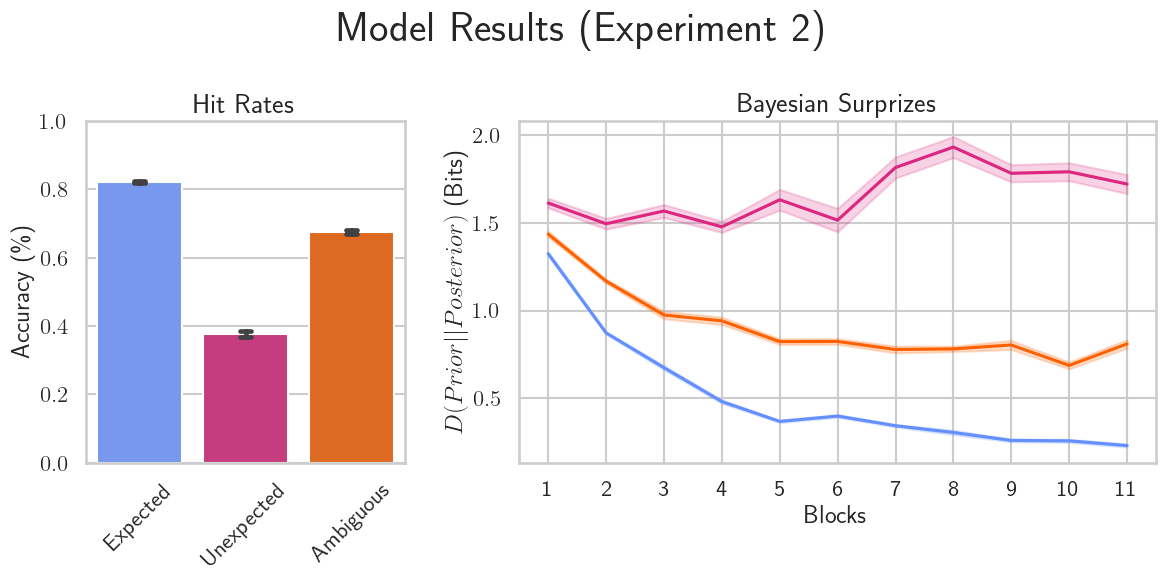

In [50]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={"width_ratios": [2, 4]})
df = pd.DataFrame(
    np.array([all_acc_exp_model, all_acc_une_model, all_acc_amb_model]).T,
    columns=["Expected", "Unexpected", "Ambiguous"],
)
sns.barplot(df, ax=ax[0], errorbar="se", capsize=0.1)  # 95% confience interval
ax[0].set_title("Hit Rates", fontweight="bold", fontsize=20)
ax[0].set_ylabel(r"Accuracy (\%)")
ax[0].set_ylim(0, 1)
ax[0].tick_params(axis="x", rotation=45)

df = (
    pd.DataFrame(all_surprize_exp_model_blockwise)
    .T.assign(x=np.arange(len(all_surprize_exp_model_blockwise)))
    .melt(id_vars="x", value_name="y")
)
sns.lineplot(data=df, x="x", y="y", errorbar="se", ax=ax[1])
df = (
    pd.DataFrame(all_surprize_une_model_blockwise)
    .T.assign(x=np.arange(len(all_surprize_une_model_blockwise)))
    .melt(id_vars="x", value_name="y")
)
sns.lineplot(data=df, x="x", y="y", errorbar="se", ax=ax[1])
df = (
    pd.DataFrame(all_surprize_amb_model_blockwise)
    .T.assign(x=np.arange(len(all_surprize_amb_model_blockwise)))
    .melt(id_vars="x", value_name="y")
)
sns.lineplot(data=df, x="x", y="y", errorbar="se", ax=ax[1])

ax[1].set_title(r"Bayesian Surprizes", fontweight="bold", fontsize=20)
ax[1].set_ylabel(r"$D(Prior||Posterior)$ (Bits)")
# ax[1].set_ylim(1.2, 1.6)
ax[1].set_xlabel("Blocks")
ax[1].set_xticks(range(11), np.arange(1, 12))

plt.suptitle("Model Results (Experiment 2)", fontweight="bold", fontsize=30)
plt.tight_layout()
plt.savefig("./behavioral_modeling_results/main_model_experiment2.png", dpi=300)

plt.show()

In [51]:
df = pd.DataFrame(
    np.array([all_acc_exp_model, all_acc_une_model, all_acc_amb_model]).T,
    columns=["Expected", "Unexpected", "Ambiguous"],
)
print(np.round(df.mean(), 4))
print(np.round(df.std(), 4))

df = (
    pd.DataFrame(all_surprize_exp_model_blockwise)
    .T.assign(x=np.arange(len(all_surprize_exp_model_blockwise)))
    .melt(id_vars="x", value_name="y")
)
print(np.round(df.y.mean(), 4))
print(np.round(df.y.std(), 4))
df = (
    pd.DataFrame(all_surprize_une_model_blockwise)
    .T.assign(x=np.arange(len(all_surprize_une_model_blockwise)))
    .melt(id_vars="x", value_name="y")
)
print(np.round(df.y.mean(), 4))
print(np.round(df.y.std(), 4))
df = (
    pd.DataFrame(all_surprize_amb_model_blockwise)
    .T.assign(x=np.arange(len(all_surprize_amb_model_blockwise)))
    .melt(id_vars="x", value_name="y")
)
print(np.round(df.y.mean(), 4))
print(np.round(df.y.std(), 4))

Expected      0.8224
Unexpected    0.3759
Ambiguous     0.6760
dtype: float64
Expected      0.0156
Unexpected    0.0473
Ambiguous     0.0299
dtype: float64
0.5012
0.3242
1.6668
0.2802
0.9114
0.2276


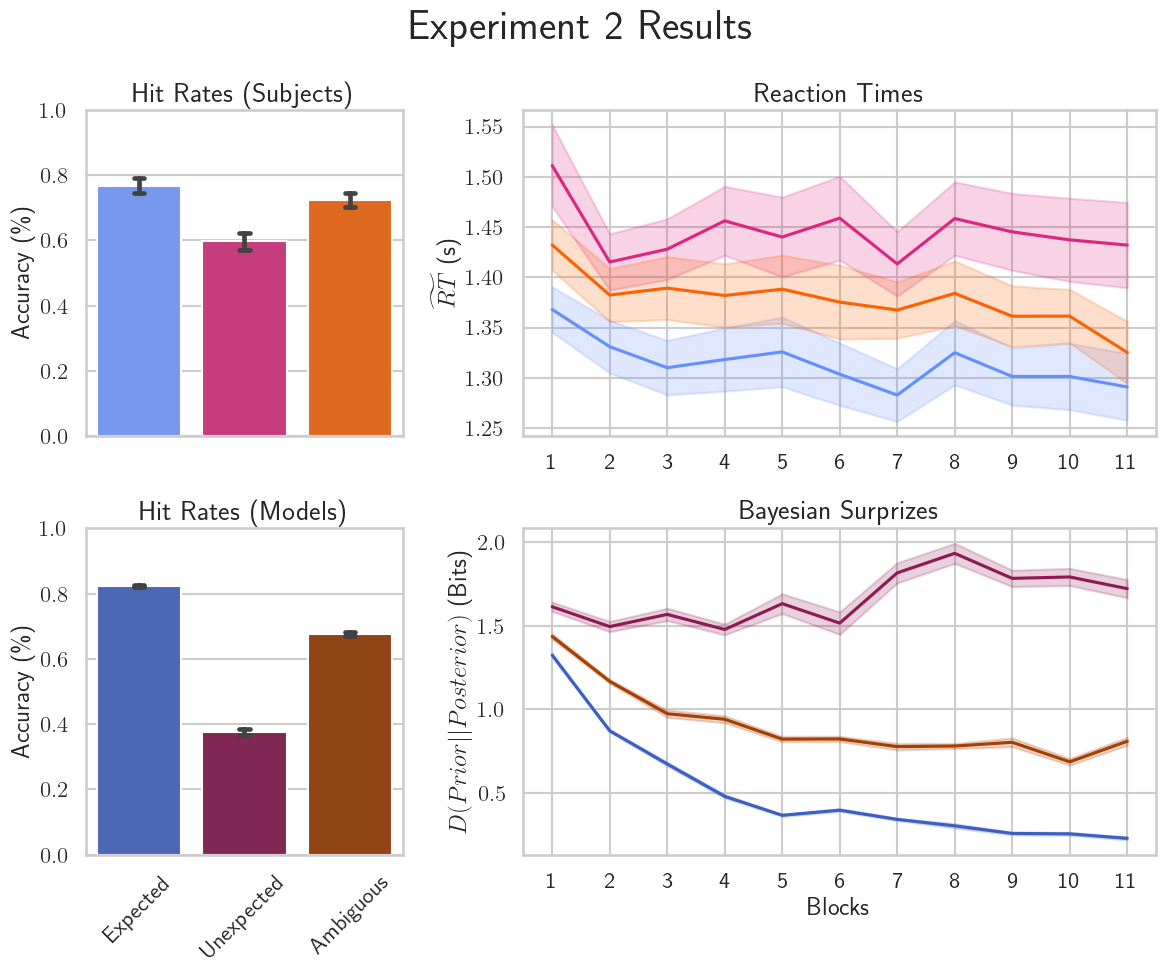

In [52]:
ibm_palette = [
    "#648fff",
    "#dc267f",
    "#fe6100",
    "#ffb000",
    "#785ef0",
    "#8be04e",
    "#009e73",
    "#56b4e9",
]
ibm_palette_darker = [
    "#3b5fc4",
    "#8f1953",
    "#a63f00",
    "#a86f00",
    "#4a37b8",
    "#8be04e",
    "#009e73",
    "#56b4e9",
]


fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(2, 2, width_ratios=[2, 4], height_ratios=[1, 1])
ax0 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

sns.set_palette(ibm_palette)
df = pd.DataFrame(
    np.array(
        [all_acc_exp_experiment2, all_acc_une_experiment2, all_acc_amb_experiment2]
    ).T[~exclusions_experiment2],
    columns=["Expected", "Unexpected", "Ambiguous"],
)
sns.barplot(df, ax=ax0, errorbar="se", capsize=0.1)  # 95% confience interval
ax0.set_title("Hit Rates (Subjects)", fontweight="bold", fontsize=20)
ax0.set_ylabel(r"Accuracy (\%)")
ax0.set_ylim(0.0, 1)
ax0.set_xticks([])

# rts/surprizes
sns.set_palette(ibm_palette)
sns.lineplot(
    data=(
        pd.DataFrame(all_rt_exp_experiment2_blockwise)
        .T.assign(x=np.arange(len(all_rt_exp_experiment2_blockwise)))
        .melt(id_vars="x", value_name="y")
    ),
    x="x",
    y="y",
    errorbar="se",
    ax=ax2,
)
sns.lineplot(
    data=(
        pd.DataFrame(all_rt_une_experiment2_blockwise)
        .T.assign(x=np.arange(len(all_rt_une_experiment2_blockwise)))
        .melt(id_vars="x", value_name="y")
    ),
    x="x",
    y="y",
    errorbar="se",
    ax=ax2,
)
sns.lineplot(
    data=(
        pd.DataFrame(all_rt_amb_experiment2_blockwise)
        .T.assign(x=np.arange(len(all_rt_amb_experiment2_blockwise)))
        .melt(id_vars="x", value_name="y")
    ),
    x="x",
    y="y",
    errorbar="se",
    ax=ax2,
)
ax2.set_title(r"Reaction Times", fontweight="bold", fontsize=20)
ax2.set_ylabel(r"$\widetilde{RT}$ (s)")
# ax2.set_ylim(1.1, 1.5)
ax2.set_xlabel("")
ax2.set_xticks(range(11), np.arange(1, 12))


sns.set_palette(ibm_palette_darker)
ax1 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

sns.set_palette(ibm_palette_darker)
df = pd.DataFrame(
    np.array([all_acc_exp_model, all_acc_une_model, all_acc_amb_model]).T,
    columns=["Expected", "Unexpected", "Ambiguous"],
)
sns.barplot(df, ax=ax1, errorbar="se", capsize=0.1)  # 95% confience interval
ax1.set_title("Hit Rates (Models)", fontweight="bold", fontsize=20)
ax1.set_ylabel(r"Accuracy (\%)")
ax1.set_ylim(0.0, 1)
ax1.tick_params(axis="x", rotation=45)

sns.lineplot(
    data=(
        pd.DataFrame(all_surprize_exp_model_blockwise)
        .T.assign(x=np.arange(len(all_surprize_exp_model_blockwise)))
        .melt(id_vars="x", value_name="y")
    ),
    x="x",
    y="y",
    errorbar="se",
    ax=ax3,
)
sns.lineplot(
    data=(
        pd.DataFrame(all_surprize_une_model_blockwise)
        .T.assign(x=np.arange(len(all_surprize_une_model_blockwise)))
        .melt(id_vars="x", value_name="y")
    ),
    x="x",
    y="y",
    errorbar="se",
    ax=ax3,
)
sns.lineplot(
    data=(
        pd.DataFrame(all_surprize_amb_model_blockwise)
        .T.assign(x=np.arange(len(all_surprize_amb_model_blockwise)))
        .melt(id_vars="x", value_name="y")
    ),
    x="x",
    y="y",
    errorbar="se",
    ax=ax3,
)
ax3.set_title(r"Bayesian Surprizes", fontweight="bold", fontsize=20)
ax3.set_ylabel(r"$D(Prior||Posterior)$ (Bits)")
# ax3.set_ylim(1.2, 1.6)
ax3.set_xlabel("Blocks")
ax3.set_xticks(range(11), np.arange(1, 12))

plt.suptitle("Experiment 2 Results", fontweight="bold", fontsize=30)
plt.tight_layout()
plt.savefig("./behavioral_modeling_results/main_results_experiment2.png", dpi=300)

plt.show()

# reset
sns.set_palette(ibm_palette)

In [53]:
df = pd.DataFrame(
    np.array([all_acc_exp_model, all_acc_une_model, all_acc_amb_model]).T,
    columns=["Expected", "Unexpected", "Ambiguous"],
)
print(np.round(df.mean(), 4))
print(np.round(df.std(), 4))

df = (
    pd.DataFrame(all_surprize_exp_model_blockwise)
    .T.assign(x=np.arange(len(all_surprize_exp_model_blockwise)))
    .melt(id_vars="x", value_name="y")
)
print(np.round(df.y.mean(), 4))
print(np.round(df.y.std(), 4))
df = (
    pd.DataFrame(all_surprize_une_model_blockwise)
    .T.assign(x=np.arange(len(all_surprize_une_model_blockwise)))
    .melt(id_vars="x", value_name="y")
)
print(np.round(df.y.mean(), 4))
print(np.round(df.y.std(), 4))
df = (
    pd.DataFrame(all_surprize_amb_model_blockwise)
    .T.assign(x=np.arange(len(all_surprize_amb_model_blockwise)))
    .melt(id_vars="x", value_name="y")
)
print(np.round(df.y.mean(), 4))
print(np.round(df.y.std(), 4))

Expected      0.8224
Unexpected    0.3759
Ambiguous     0.6760
dtype: float64
Expected      0.0156
Unexpected    0.0473
Ambiguous     0.0299
dtype: float64
0.5012
0.3242
1.6668
0.2802
0.9114
0.2276


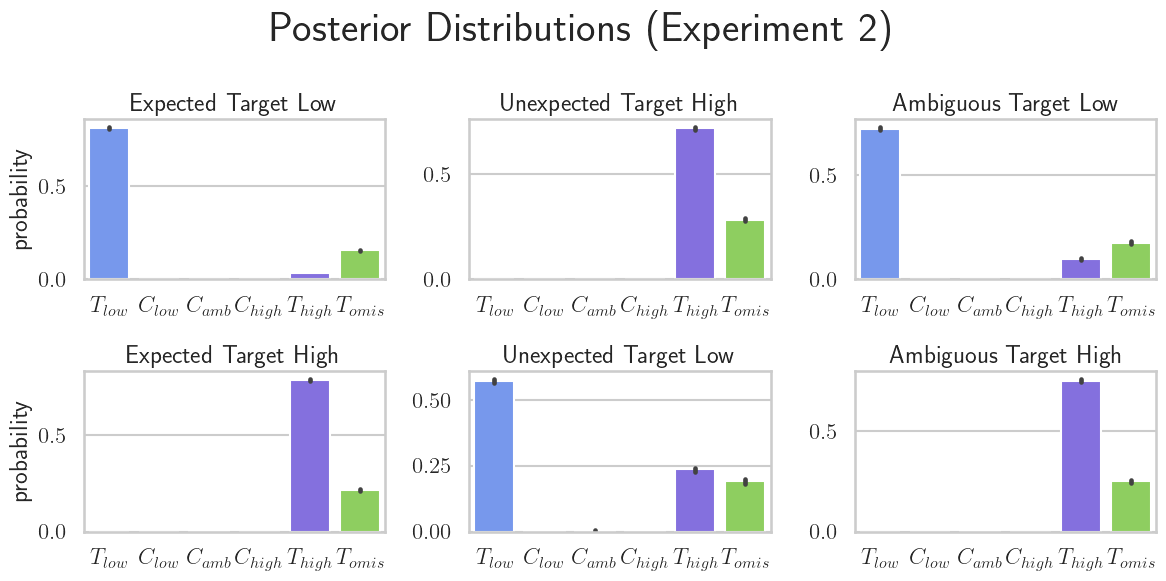

In [54]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

data = np.array(list(all_belief_exp1_model_blockwise.values()))
data = data[
    :, ~np.array(flip_subject_experiment2)[~exclusions_experiment2], :
]  # not flipped
ax = sns.barplot(np.nanmean(data, axis=0), ax=axes[0][0])
ax.set_xticks(range(6), experiment2_label_names)
ax.set_title("Expected Target Low")
ax.set_ylabel("probability")

data = np.array(list(all_belief_une1_model_blockwise.values()))
data = data[
    :, ~np.array(flip_subject_experiment2)[~exclusions_experiment2], :
]  # not flipped
ax = sns.barplot(np.nanmean(data, axis=0), ax=axes[0][1])
ax.set_xticks(range(6), experiment2_label_names)
ax.set_title("Unexpected Target High")

data = np.array(list(all_belief_amb1_model_blockwise.values()))
data = data[
    :, ~np.array(flip_subject_experiment2)[~exclusions_experiment2], :
]  # not flipped
ax = sns.barplot(np.nanmean(data, axis=0), ax=axes[0][2])
ax.set_xticks(range(6), experiment2_label_names)
ax.set_title("Ambiguous Target Low")

# high freq
data = np.array(list(all_belief_exp2_model_blockwise.values()))
data = data[
    :, ~np.array(flip_subject_experiment2)[~exclusions_experiment2], :
]  # not flipped
ax = sns.barplot(np.nanmean(data, axis=0), ax=axes[1][0])
ax.set_xticks(range(6), experiment2_label_names)
ax.set_title("Expected Target High")
ax.set_ylabel("probability")

data = np.array(list(all_belief_une2_model_blockwise.values()))
data = data[
    :, ~np.array(flip_subject_experiment2)[~exclusions_experiment2], :
]  # not flipped
ax = sns.barplot(np.nanmean(data, axis=0), ax=axes[1][1])
ax.set_xticks(range(6), experiment2_label_names)
ax.set_title("Unexpected Target Low")

data = np.array(list(all_belief_amb2_model_blockwise.values()))
data = data[
    :, ~np.array(flip_subject_experiment2)[~exclusions_experiment2], :
]  # not flipped
ax = sns.barplot(np.nanmean(data, axis=0), ax=axes[1][2])
ax.set_xticks(range(6), experiment2_label_names)
ax.set_title("Ambiguous Target High")

plt.suptitle("Posterior Distributions (Experiment 2)", fontweight="bold", fontsize=30)
plt.tight_layout()
plt.savefig("./behavioral_modeling_results/posterior_beliefs_experiment2.png", dpi=300)

plt.tight_layout()
plt.show()

## Entropy Rates for Markov Matrices

$$H = - \sum_i \pi_i \sum_j P_{ij}log P_{ij}$$

In [58]:
def get_pi(W):
    w, v = np.linalg.eig(W)
    idx = np.argmin(np.abs(w - 1.0))
    v1 = np.real(v[:, idx])
    pi = v1 / v1.sum()
    return pi


def entropy_rate(W, err=1e-8):
    # calulate pi
    pi = get_pi(W)

    H_rate = 0
    for i, P in enumerate(W):
        H_rate += -np.sum(pi[i] * np.sum(P * np.log2(P + err)))
        # H_rate += - np.sum(P * np.log2(P+err))
    return H_rate


def entropy(P, err=1e-8):
    return -np.sum(P * np.log2(P + err))

In [59]:
sid = 0

learning_rate = 0.05

seq = np.concatenate(
    [
        np.array(list(map(pairs_experiment2_map.get, block))).ravel()
        for block in E_experiment2[sid].lists.mainTask
    ]
)
cues = seq[::2]
seq_wave = generate_waveforms(
    seq, all_noise[sid], tscale_experiment2, bias=0, X=X_pure_experiment2
)
subject_responses = np.array(
    list(
        map(
            resp_to_state_experiment2_map.get,
            E_experiment2[sid].resp.mainTask.resp.ravel(),
        )
    )
)
subject_responses = np.concatenate(list(zip(cues, subject_responses)))
subject_responses[subject_responses == -1] = 5
model = SLIM(dim=6, sensor=sensor)
model.W = np.eye(dim, dtype=np.float32)


W_subject = calculate_MLE(subject_responses)
mle_W = all_mle_W[sid]

all_W = []
all_H_rates = []
obs = []
H_observed_env = []
H_s_hist = []
for idx, wave in enumerate(seq_wave):
    dist = model.observe(wave, feed_observations=False)
    model.step(dist, learning_rate=learning_rate)
    all_W.append(model.W)
    all_H_rates.append(entropy_rate(model.W))
    obs.append(dist)

    H_s_hist.append(
        entropy_rate(calculate_MLE(subject_responses[:idx], unique_states=np.arange(6)))
    )
    H_observed_env.append(
        entropy_rate(calculate_MLE(np.argmax(np.array(obs), axis=1), np.arange(6)))
    )

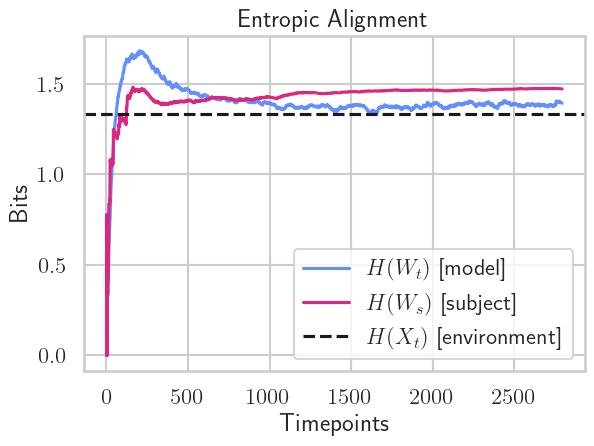

In [60]:
all_H_rates_minus_train = np.array(all_H_rates)[1::2]
all_H_rates_minus_train.reshape(11, all_H_rates_minus_train.size // 11)[:, 10:].ravel()
sns.lineplot(all_H_rates, label="$H(W_t)$ [model]")
# sns.lineplot(all_H_rates_minus_train, label='$H(W_t)$ [model]')

H_s_hist[0] = np.nan
H_s_hist_minus_train = np.array(H_s_hist)[1::2]
H_s_hist_minus_train.reshape(11, H_s_hist_minus_train.size // 11)[:, 10:].ravel()
sns.lineplot(H_s_hist, label="$H(W_{s})$ [subject]")
# sns.lineplot(H_s_hist_minus_train, label='$H(W_{s})$ [subject]')

plt.axhline(entropy_rate(mle_W), c="k", linestyle="--", label="$H(X_t)$ [environment]")

plt.ylabel("Bits")
plt.xlabel("Timepoints")
plt.title("Entropic Alignment")
plt.legend()
plt.tight_layout()
plt.savefig("./behavioral_modeling_results/entropic_convergence.png", dpi=300)
plt.show()

In [61]:
# sid = 0

all_subject_Hrates = {}
for sid in tqdm(range(n_subjects)):
    learning_rate = 0.01
    seq = np.concatenate(
        [
            np.array(list(map(pairs_experiment2_map.get, block))).ravel()
            for block in E_experiment2[sid].lists.mainTask
        ]
    )
    cues = seq[::2]
    seq_wave = generate_waveforms(
        seq, all_noise[sid], tscale_experiment2, bias=0, X=X_pure_experiment2
    )
    subject_responses = np.array(
        list(
            map(
                resp_to_state_experiment2_map.get,
                E_experiment2[sid].resp.mainTask.resp.ravel(),
            )
        )
    )

    try:
        subject_responses = np.concatenate(list(zip(cues, subject_responses)))
        subject_responses[subject_responses == -1] = 5
        model = SLIM(dim=6, sensor=sensor)
        model.W = np.eye(dim, dtype=np.float32)
        W_subject = calculate_MLE(subject_responses)
        mle_W = all_mle_W[sid]
        # all_W = []
        # all_H_rates = []
        obs = []
        H_observed_env = []
        H_s_hist = []
        for idx, wave in enumerate(seq_wave):
            dist = model.observe(wave, feed_observations=False)
            model.step(dist, learning_rate=learning_rate)
            # all_W.append(model.W)
            # all_H_rates.append(entropy_rate(model.W))
            obs.append(dist)
            H_s_hist.append(
                entropy_rate(
                    calculate_MLE(subject_responses[:idx], unique_states=np.arange(6))
                )
            )
            H_observed_env.append(
                entropy_rate(
                    calculate_MLE(np.argmax(np.array(obs), axis=1), np.arange(6))
                )
            )
        H_s_hist[0] = np.nan
        H_s_hist_minus_train = np.array(H_s_hist)[1::2]
        H_s_hist_minus_train.reshape(11, H_s_hist_minus_train.size // 11)[
            :, 10:
        ].ravel()
        all_subject_Hrates[sid] = H_s_hist
    except Exception as e:
        print(e)

 93%|█████████▎| 28/30 [03:14<00:06,  3.34s/it]

index 25 is out of bounds for axis 0 with size 25
index 26 is out of bounds for axis 0 with size 25
index 27 is out of bounds for axis 0 with size 25


100%|██████████| 30/30 [03:14<00:00,  6.49s/it]

index 28 is out of bounds for axis 0 with size 25
index 29 is out of bounds for axis 0 with size 25


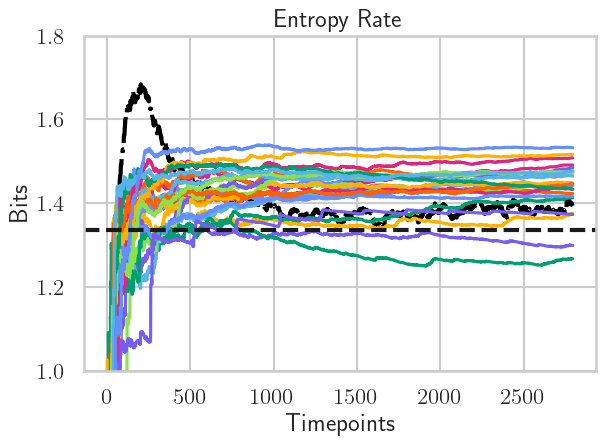

In [62]:
sns.lineplot(
    all_H_rates, label="$H(W_t)$ [model]", c="black", linestyle="-.", linewidth=3
)

for sid, H_s_hist in all_subject_Hrates.items():
    ax = sns.lineplot(H_s_hist, label="$H(W_{s})$ [sid]")

ax.legend().remove()
plt.axhline(
    entropy_rate(mle_W),
    c="k",
    linestyle="--",
    linewidth=3,
    label="$H(X_t)$ [environment]",
)

plt.ylabel("Bits")
plt.xlabel("Timepoints")
plt.title("Entropy Rate")
plt.ylim(1, 1.8)
plt.tight_layout()
plt.savefig("./behavioral_modeling_results/entropic_convergence.png", dpi=300)
plt.show()

In [63]:
# sid = 0

# all_H_s_hist = []
# plt.figure(figsize=(20, 4))
# for sid in tqdm(range(30)):
#     if sid in exclusions_experiment2:
#         continue

#     learning_rate = 0.01

#     seq = np.concatenate(
#         [
#             np.array(list(map(pairs_experiment2_map.get, block))).ravel()
#             for block in E_experiment2[sid].lists.mainTask
#         ]
#     )
#     cues = seq[::2]
#     seq_wave = generate_waveforms(
#         seq, all_noise[sid], tscale_experiment2, bias=0, X=X_pure_experiment2
#     )
#     subject_responses = np.array(
#         list(
#             map(
#                 resp_to_state_experiment2_map.get,
#                 E_experiment2[sid].resp.mainTask.resp.ravel(),
#             )
#         )
#     )
#     subject_responses = np.concatenate(list(zip(cues, subject_responses)))
#     subject_responses[subject_responses == -1] = 5
#     model = SLIM(dim=6, sensor=sensor)
#     model.W = np.eye(dim, dtype=np.float32)

#     W_subject = calculate_MLE(subject_responses)

#     H_s_hist = [
#         entropy_rate(calculate_MLE(subject_responses[:idx], unique_states=np.arange(6)))
#         for idx, wave in enumerate(seq_wave)
#     ]
#     H_s_hist[0] = np.nan

#     all_H_s_hist.append(H_s_hist)
# all_H_s_hist = np.array(all_H_s_hist)

In [64]:
# means = np.mean(all_H_s_hist, axis=0)
# ses = np.std(all_H_s_hist[:220], axis=0) / np.sqrt(all_H_s_hist.shape[0])

# plt.errorbar(np.arange(means.size)[:220], means[:220], yerr=ses[:220], c="b")
# plt.show()

In [65]:
data_store["model_experiment2"] = {
    "all_dPrime_une_experiment2": deepcopy(all_dPrime_une_model),
    "all_dPrime_exp_experiment2": deepcopy(all_dPrime_exp_model),
    "all_dPrime_amb_experiment2": deepcopy(all_dPrime_amb_model),
    "all_criterion_une_experiment2": deepcopy(all_criterion_une_model),
    "all_criterion_exp_experiment2": deepcopy(all_criterion_exp_model),
    "all_criterion_amb_experiment2": deepcopy(all_criterion_amb_model),
    "all_dPrime_exp_experiment2_blockwise": deepcopy(all_dprime_exp_model_blockwise),
    "all_dPrime_une_experiment2_blockwise": deepcopy(all_dprime_une_model_blockwise),
    "all_dPrime_amb_experiment2_blockwise": deepcopy(all_dprime_amb_model_blockwise),
    "all_criterion_exp_experiment2_blockwise": deepcopy(
        all_criterion_exp_model_blockwise
    ),
    "all_criterion_une_experiment2_blockwise": deepcopy(
        all_criterion_une_model_blockwise
    ),
    "all_criterion_amb_experiment2_blockwise": deepcopy(
        all_criterion_amb_model_blockwise
    ),
    "all_belief_exp1_model_blockwise": deepcopy(all_belief_exp1_model_blockwise),
    "all_belief_une1_model_blockwise": deepcopy(all_belief_une1_model_blockwise),
    "all_belief_amb1_model_blockwise": deepcopy(all_belief_amb1_model_blockwise),
    "all_belief_exp2_model_blockwise": deepcopy(all_belief_exp2_model_blockwise),
    "all_belief_une2_model_blockwise": deepcopy(all_belief_une2_model_blockwise),
    "all_belief_amb2_model_blockwise": deepcopy(all_belief_amb2_model_blockwise),
    "all_surprize_exp_model_blockwise": deepcopy(all_surprize_exp_model_blockwise),
    "all_surprize_une_model_blockwise": deepcopy(all_surprize_une_model_blockwise),
    "all_surprize_amb_model_blockwise": deepcopy(all_surprize_amb_model_blockwise),
    "all_log_ratios_exp_model_blockwise": deepcopy(all_log_ratios_exp_model_blockwise),
    "all_log_ratios_une_model_blockwise": deepcopy(all_log_ratios_une_model_blockwise),
    "all_log_ratios_amb_model_blockwise": deepcopy(all_log_ratios_amb_model_blockwise),
    "all_kl_pred_obs_exp_model_blockwise": deepcopy(
        all_kl_pred_obs_exp_model_blockwise
    ),
    "all_kl_pred_obs_une_model_blockwise": deepcopy(all_kl_pred_obs_une_model_blockwise),
    "all_kl_pred_obs_amb_model_blockwise": deepcopy(all_kl_pred_obs_amb_model_blockwise),
    "all_model_neglog_pred_exp_blockwise": deepcopy(all_model_neglog_pred_exp_blockwise),
    "all_model_neglog_pred_une_blockwise": deepcopy(all_model_neglog_pred_une_blockwise),
    "all_model_neglog_pred_amb_blockwise": deepcopy(all_model_neglog_pred_amb_blockwise),
    "all_model_neglog_post_exp_blockwise": deepcopy(all_model_neglog_post_exp_blockwise),
    "all_model_neglog_post_une_blockwise": deepcopy(all_model_neglog_post_une_blockwise),
    "all_model_neglog_post_amb_blockwise": deepcopy(all_model_neglog_post_amb_blockwise),
    "all_priorentropies_exp_model_blockwise": deepcopy(all_priorentropies_exp_model_blockwise),
    "all_priorentropies_une_model_blockwise": deepcopy(all_priorentropies_une_model_blockwise),
    "all_priorentropies_amb_model_blockwise": deepcopy(all_priorentropies_amb_model_blockwise),

    "all_acc_une_experiment2": deepcopy(all_acc_une_model),
    "all_acc_exp_experiment2": deepcopy(all_acc_exp_model),
    "all_acc_amb_experiment2": deepcopy(all_acc_amb_model),
}

In [66]:
# with open('./stats/data_store.pkl', 'wb') as f:
#     pkl.dump(data_store, f)

---

# Experiment 1

In [67]:
def e(seed):
    rng = np.random.default_rng(seed=seed)
    return rng.random(int(0.05 * sr_experiment2)) - 0.5

In [68]:
pairs_experiment1_map = {
    1: [1, 0],
    2: [2, 3],
    3: [1, 3],
    4: [2, 0],
    5: [1, 4],
    6: [2, 4],
}

resp_to_state_experiment1_map = {0: -1, 1: 0, 2: 3, 3: 4}

experiment1_label_names = [
    r"$T_{low}$",
    r"$C_{low}$",
    r"$C_{high}$",
    r"$T_{high}$",
    r"$T_{omis}$",
]

model_to_resp_experiment1_map = {0: 1, 3: 2, 4: 3}

pairs_experiment1_map_flipped = {
    1: [1, 3],
    2: [2, 0],
    3: [1, 0],
    4: [2, 3],
    5: [1, 4],
    6: [2, 4],
}

resp_to_state_experiment1_map_flipped = {0: -1, 1: 3, 2: 0, 3: 4}

model_to_resp_experiment1_map_flipped = {0: 2, 3: 1, 4: 3}


f_mask = [0, 1, 3, 4, 5]
tscale_experiment1 = np.array(list(thr.values()))[f_mask]
tscale_experiment1[1] = tscale_experiment1[2] = 1.0
tscale_experiment1

array([0.14, 1.  , 1.  , 0.39, 0.01])

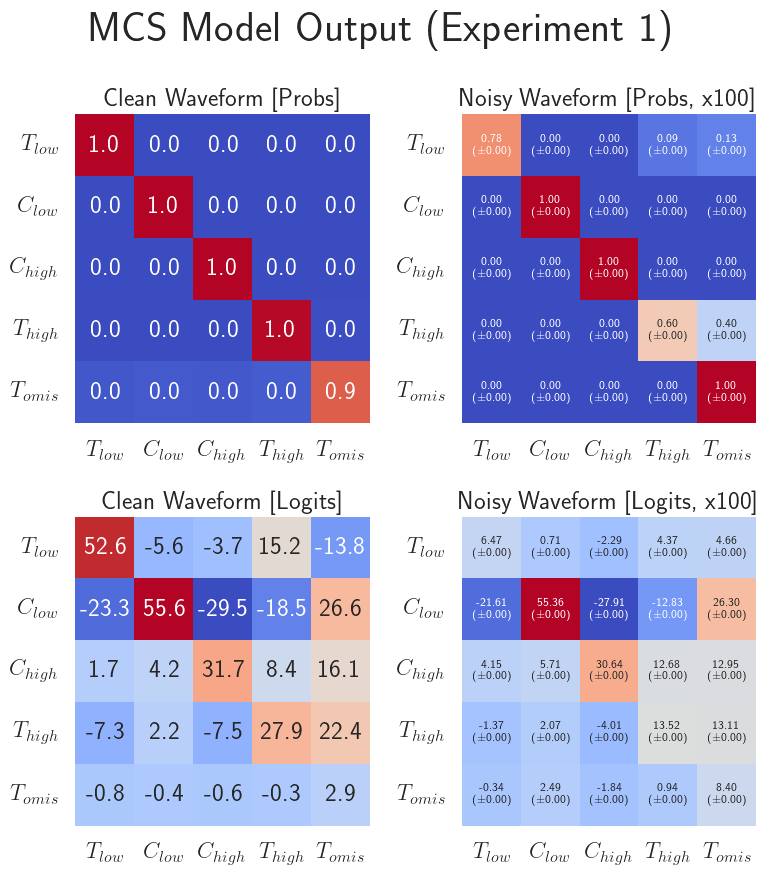

In [69]:
# check sensor decisions

plt.figure(figsize=(8, 9))

############### no noise ###############

obs = (
    sensor(torch.Tensor(X_pure_experiment1[:-1]).unsqueeze(1))
    .detach()
    .numpy()
    .squeeze()[:, f_mask]
)

ax = plt.subplot(221)
sns.heatmap(
    [softmax(o) for o in obs],
    cmap="coolwarm",
    cbar=False,
    annot=True,
    xticklabels=experiment1_label_names,
    yticklabels=experiment1_label_names,
    ax=ax,
    fmt=".1f",
)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_title("Clean Waveform [Probs]")
ax = plt.subplot(223)
sns.heatmap(
    obs,
    cmap="coolwarm",
    cbar=False,
    annot=True,
    xticklabels=experiment1_label_names,
    yticklabels=experiment1_label_names,
    ax=ax,
    fmt=".1f",
)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_title("Clean Waveform [Logits]")

############### average over 100 times ###############
n_it = 100
obs = [
    sensor(
        torch.Tensor(
            np.array(
                [
                    tscale_experiment1[i] * x + e(i)
                    for i, x in enumerate(X_pure_experiment1[:-1])
                ]
            )
        ).unsqueeze(1)
    )
    .detach()
    .numpy()
    .squeeze()[:, f_mask]
    for idx in range(n_it)
]
p_obs = np.array([[softmax(o) for o in o_mat] for o_mat in obs])

ax = plt.subplot(222)
p_obs_mean = np.mean(p_obs, axis=0)
annot = np.vectorize(lambda m, s: f"{m:.2f}\n(±{s:.2f})")(
    p_obs_mean, np.std(p_obs, axis=0)
)
sns.heatmap(
    p_obs_mean,
    cmap="coolwarm",
    cbar=False,
    annot=annot,
    annot_kws={"fontsize": 8},
    fmt="",
    xticklabels=experiment1_label_names,
    yticklabels=experiment1_label_names,
    ax=ax,
)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_title(f"Noisy Waveform [Probs, x{n_it}]")
ax = plt.subplot(224)
obs_mean = np.mean(obs, axis=0)
annot = np.vectorize(lambda m, s: f"{m:.2f}\n(±{s:.2f})")(obs_mean, np.std(obs, axis=0))
sns.heatmap(
    obs_mean,
    cmap="coolwarm",
    cbar=False,
    annot=annot,
    annot_kws={"fontsize": 8},
    fmt="",
    xticklabels=experiment1_label_names,
    yticklabels=experiment1_label_names,
    ax=ax,
)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_title(f"Noisy Waveform [Logits, x{n_it}]")

plt.suptitle("MCS Model Output (Experiment 1)", fontweight="bold", fontsize=30)
plt.tight_layout()
plt.savefig(
    "./behavioral_modeling_results/multiscale_conv_output_experiment1.png", dpi=300
)

plt.show()

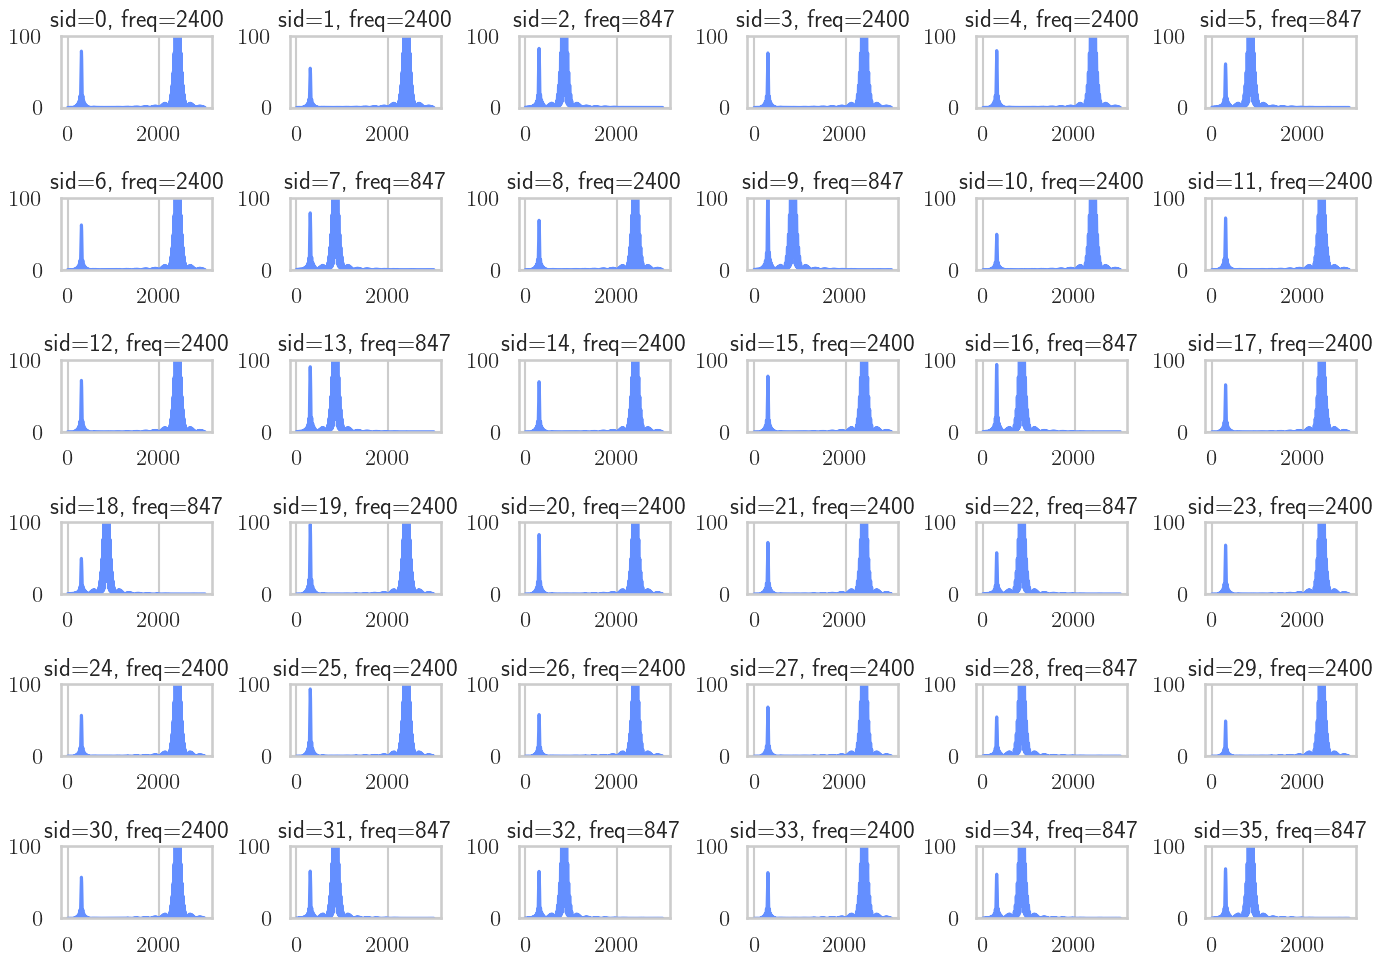

In [70]:
flip_subject_experiment1 = []
fig, axes = plt.subplots(6, 6, figsize=(14, 10))
for sid in range(36):
    ax = axes.ravel()[sid]
    tone = E_experiment1[sid].stim.tone_pairs[
        0
    ]  # get the first pair which you previously assumed to be low-low
    transform = np.abs(np.fft.fft(tone))
    freqs = np.fft.fftfreq(len(tone), 1 / sr_experiment1)
    idx = (freqs > 0) & (freqs < 3000)
    sns.lineplot(x=freqs[idx], y=np.abs(transform)[idx], ax=ax)
    freq = np.mean(np.abs(freqs[np.abs(transform) > 1000]))
    if freq < 2000:
        flip_subject_experiment1.append(False)
    else:
        flip_subject_experiment1.append(True)
    ax.set_title(f"sid={sid}, freq={int(freq)}")
    ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

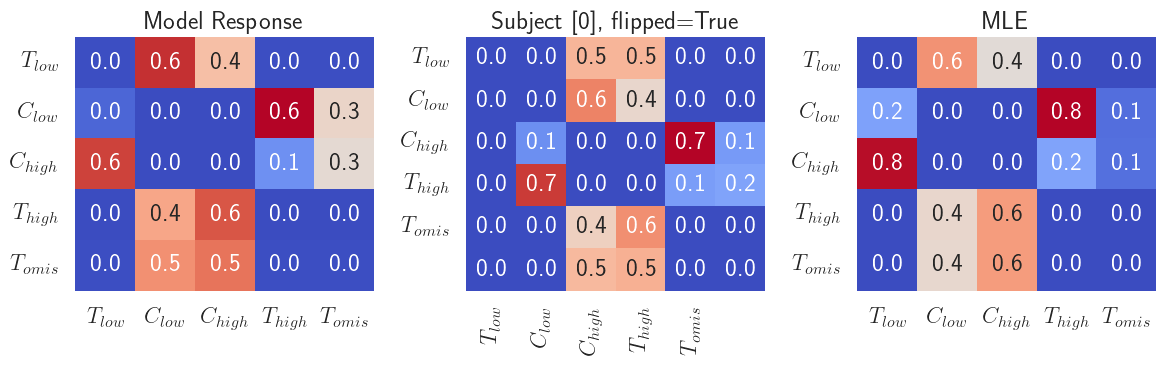

In [71]:
lr = 0.01

for sid in range(36):
    # create token sequence
    if flip_subject_experiment1[sid]:
        seq = np.concatenate(
            [
                np.array(list(map(pairs_experiment1_map_flipped.get, block))).ravel()
                for block in E_experiment1[sid].lists.mainTask
            ]
        )
    else:
        seq = np.concatenate(
            [
                np.array(list(map(pairs_experiment1_map.get, block))).ravel()
                for block in E_experiment1[sid].lists.mainTask
            ]
        )

    noise = generate_some_noise(
        len(seq)
    )  # precreate noise to prevent gaussianity and so on...

    seq_wave = generate_waveforms(
        seq, noise, tscale_experiment1, bias=0, X=X_pure_experiment1
    )
    seq_wave_biased = generate_waveforms(
        seq, noise, tscale_experiment1, bias=0, X=X_pure_experiment1
    )

    # build model matrix
    model = SLIM(dim=5, sensor=sensor)
    model.fit(seq_wave, learning_rate=lr)

    # build subject matrix
    cues = seq[::2]

    if flip_subject_experiment1[sid]:
        subject_responses = np.array(
            list(
                map(
                    resp_to_state_experiment1_map_flipped.get,
                    E_experiment1[sid].resp.mainTask.resp.ravel(),
                )
            )
        )
    else:
        subject_responses = np.array(
            list(
                map(
                    resp_to_state_experiment1_map.get,
                    E_experiment1[sid].resp.mainTask.resp.ravel(),
                )
            )
        )
    subject_responses = np.concatenate(list(zip(cues, subject_responses)))
    W_subject = calculate_MLE(subject_responses)
    W_mle = calculate_MLE(seq)

    plt.figure(figsize=(12, 4))
    ax = plt.subplot(131)
    sns.heatmap(
        model.W,
        cmap="coolwarm",
        annot=True,
        fmt=".1f",
        cbar=False,
        xticklabels=experiment1_label_names,
        yticklabels=experiment1_label_names,
        ax=ax,
    )
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_title("Model Response")
    ax = plt.subplot(132)
    sns.heatmap(
        W_subject,
        cmap="coolwarm",
        annot=True,
        fmt=".1f",
        cbar=False,
        xticklabels=experiment1_label_names,
        yticklabels=experiment1_label_names,
        ax=ax,
    )
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_title(f"Subject [{sid}], flipped={flip_subject_experiment1[sid]}")
    ax = plt.subplot(133)
    sns.heatmap(
        W_mle,
        cmap="coolwarm",
        annot=True,
        fmt=".1f",
        cbar=False,
        xticklabels=experiment1_label_names,
        yticklabels=experiment1_label_names,
        ax=ax,
    )
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_title("MLE")
    plt.tight_layout()
    plt.show()
    break

## Quantify

In [72]:
# precreate all noise
n_subjects = 36  # exclude in loop
all_noise = [generate_some_noise(len(seq)) for _ in range(n_subjects)]

In [73]:
# learning_rate = 0.005
learning_rate = 0.01

all_models = []
all_subject_W = []
all_subject_responses = []

all_mle_W = []

all_noresp_masks = []

all_model_responses = []
all_optimal_model_responses = []
all_model_surprizes = []

all_optimal_responses = []

all_model_beliefs = []

all_model_log_ratios = []
all_model_kl_pred_obs = []
all_model_neglog_pred = []
all_model_neglog_post = []

all_model_priorentropies = []

for sid in tqdm(range(n_subjects)):
    if flip_subject_experiment1[sid]:
        seq = np.concatenate(
            [
                np.array(list(map(pairs_experiment1_map_flipped.get, block))).ravel()
                for block in E_experiment1[sid].lists.mainTask
            ]
        )
    else:
        seq = np.concatenate(
            [
                np.array(list(map(pairs_experiment1_map.get, block))).ravel()
                for block in E_experiment1[sid].lists.mainTask
            ]
        )
    cues = seq[::2]
    seq_wave = generate_waveforms(
        seq, all_noise[sid], tscale_experiment1, bias=0, X=X_pure_experiment1
    )

    optimal_responses = seq[1::2]
    optimal_responses = optimal_responses.reshape(11, optimal_responses.size // 11)[
        :, 10:
    ]
    all_optimal_responses.append(optimal_responses)

    model = SLIM(dim=5, sensor=sensor)
    model.fit(seq_wave, learning_rate=learning_rate)
    all_models.append(model)

    if flip_subject_experiment1[sid]:
        subject_responses = np.array(
            list(
                map(
                    resp_to_state_experiment1_map_flipped.get,
                    E_experiment1[sid].resp.mainTask.resp.ravel(),
                )
            )
        )
    else:
        subject_responses = np.array(
            list(
                map(
                    resp_to_state_experiment1_map.get,
                    E_experiment1[sid].resp.mainTask.resp.ravel(),
                )
            )
        )

    all_subject_responses.append(
        subject_responses.reshape(11, subject_responses.size // 11)[:, 10:]
    )
    subject_responses = np.concatenate(list(zip(cues, subject_responses)))

    no_resp_mask = subject_responses != -1
    no_resp_mask[np.where(no_resp_mask == False)[0] - 1] = (
        False  # mask out the cue as wel
    )
    all_noresp_masks.append(no_resp_mask)  # save it for later

    subject_responses[subject_responses == -1] = 4  # fake it for the matrix estimate
    all_subject_W.append(calculate_MLE(subject_responses))
    all_mle_W.append(calculate_MLE(seq))

    model_responses = np.argmax(model.bel, axis=1)[1::2]  # extract targets only
    model_responses = model_responses.reshape(11, model_responses.size // 11)
    model_responses = model_responses[:, 10:]
    all_model_responses.append(model_responses)

    surprizes = np.array(model.surprise_hist)[1::2]  # extract targets only
    surprizes = surprizes.reshape(11, surprizes.size // 11)
    surprizes = surprizes[:, 10:]
    all_model_surprizes.append(surprizes)

    beliefs = np.array(model.bel)[1::2]  # extract targets only
    beliefs = beliefs.reshape(11, beliefs.size // 11 // 5, 5)
    beliefs = beliefs[:, 10:]
    all_model_beliefs.append(beliefs)

    # optimal model
    optimal_model = SLIM(dim=5, sensor=np.eye(5, dtype=np.float32))
    optimal_model.fit(seq, learning_rate=learning_rate)
    optimal_model_responses = np.argmax(optimal_model.bel, axis=1)[
        1::2
    ]  # extract targets only
    optimal_model_responses = optimal_model_responses.reshape(
        11, optimal_model_responses.size // 11
    )
    optimal_model_responses = optimal_model_responses[:, 10:]
    all_optimal_model_responses.append(optimal_model_responses)

    # log ratios
    posteriors = model.bel[1::2].reshape(11, 1210 // 11, 5)[:, 10:, :]
    all_log_ratios = []
    for block in range(11):
        log_ratios = []
        for trial in range(100):
            true_state_idx = optimal_responses[block][trial]
            posteior_of_true_state = posteriors[block][trial][true_state_idx]
            posteior_of_omission = posteriors[block][trial][-1]

            log_ratio = np.log2(posteior_of_true_state / posteior_of_omission)
            log_ratios.append(log_ratio)
        all_log_ratios.append(log_ratios)
    all_log_ratios = np.array(all_log_ratios)
    all_model_log_ratios.append(all_log_ratios)

    # kl pred obs
    kls = np.array(
        [
            kl_div(p, q)
            for p, q in zip(np.array(model.x_hat_hist), np.array(model.y_hist))
        ]
    )[1::2].reshape(11, 1210 // 11)[:, 10:]
    all_model_kl_pred_obs.append(kls)

    # neg log pred
    priors = np.array(model.x_hat_hist)[1::2].reshape(11, 1210 // 11, 5)[:, 10:, :]
    all_neglog_pred = []
    for block in range(11):
        nl_preds = []
        for trial in range(100):
            true_state_idx = optimal_responses[block][trial]
            prior_of_true_state = priors[block][trial][true_state_idx]
            prior_of_omission = priors[block][trial][-1]

            surp_prior = -np.log2(prior_of_true_state)
            nl_preds.append(surp_prior)
        all_neglog_pred.append(nl_preds)
    all_model_neglog_pred.append(np.array(all_neglog_pred))

    # prior entropies
    prior_entropies = []
    for block in range(11):
        _ent = []
        for trial in range(100):
            _ent.append(_entropy(priors[block][trial]))
        prior_entropies.append(_ent)
    all_model_priorentropies.append(prior_entropies)

    # neg log pred
    all_neglog_post = []
    for block in range(11):
        nl_posts = []
        for trial in range(100):
            true_state_idx = optimal_responses[block][trial]
            posterior_of_true_state = posteriors[block][trial][true_state_idx]
            posterior_of_omission = posteriors[block][trial][-1]

            surp_posterior = -np.log2(posterior_of_true_state)
            nl_posts.append(surp_posterior)
        all_neglog_post.append(nl_posts)
    all_model_neglog_post.append(np.array(all_neglog_post))

100%|██████████| 36/36 [02:24<00:00,  4.01s/it]


In [74]:
pearsonr(
    np.array(all_optimal_responses).ravel(), y=np.array(all_model_responses).ravel()
)

PearsonRResult(statistic=0.7136888558272154, pvalue=0.0)

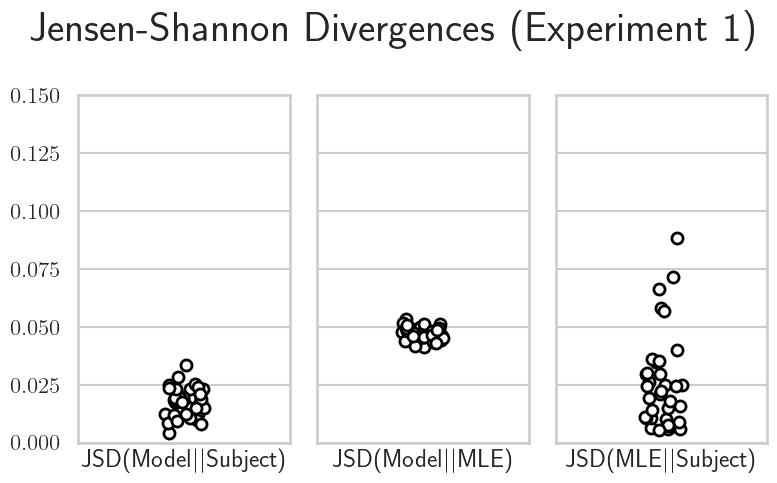

In [75]:
fig, ax = plt.subplots(1, 3, figsize=(8, 5))

jsds = [
    [
        _jsd_avg(model.W, W_subject)
        for model, W_subject in zip(all_models, all_subject_W)
    ]
]
sns.stripplot(
    jsds,
    jitter=True,
    color="white",
    size=8,
    marker="o",
    edgecolor="black",
    linewidth=2,
    alpha=1,
    ax=ax[0],
)
ax[0].set_ylim(0.0, 0.15)
ax[0].set_xlabel(r"JSD(Model$\mid\mid$Subject)")
ax[0].tick_params(labelbottom=False)

jsds = [[_jsd_avg(model.W, W_mle) for model, W_mle in zip(all_models, all_mle_W)]]
sns.stripplot(
    jsds,
    jitter=True,
    color="white",
    size=8,
    marker="o",
    edgecolor="black",
    linewidth=2,
    alpha=1,
    ax=ax[1],
)
ax[1].set_ylim(0.0, 0.15)
ax[1].set_xlabel(r"JSD(Model$\mid\mid$MLE)")
ax[1].tick_params(labelbottom=False, labelleft=False)

jsds = [
    [_jsd_avg(W_mle, W_subject) for W_mle, W_subject in zip(all_mle_W, all_subject_W)]
]
sns.stripplot(
    jsds,
    jitter=True,
    color="white",
    size=8,
    marker="o",
    edgecolor="black",
    linewidth=2,
    alpha=1,
    ax=ax[2],
)
ax[2].set_ylim(0.0, 0.15)
ax[2].set_xlabel(r"JSD(MLE$\mid\mid$Subject)")
ax[2].tick_params(labelbottom=False, labelleft=False)

plt.suptitle(
    "Jensen-Shannon Divergences (Experiment 1)", fontweight="bold", fontsize=30
)
plt.tight_layout()
plt.savefig("./behavioral_modeling_results/divergences_experiment1.png", dpi=300)

plt.show()

In [76]:
# prepare model data

all_surprize_exp_model_blockwise = {}
all_surprize_une_model_blockwise = {}

all_belief_exp1_model_blockwise = {}
all_belief_une1_model_blockwise = {}
all_belief_exp2_model_blockwise = {}
all_belief_une2_model_blockwise = {}

all_belief_exp_model_blockwise = {}
all_belief_une_model_blockwise = {}

all_priorentropies_exp_model_blockwise = {}
all_priorentropies_une_model_blockwise = {}

all_dprime_exp_model_blockwise = {}
all_dprime_une_model_blockwise = {}
all_criterion_exp_model_blockwise = {}
all_criterion_une_model_blockwise = {}

all_log_ratios_exp_model_blockwise = {}
all_log_ratios_une_model_blockwise = {}

all_kl_pred_obs_exp_model_blockwise = {}
all_kl_pred_obs_une_model_blockwise = {}

all_model_neglog_pred_exp_blockwise = {}
all_model_neglog_pred_une_blockwise = {}
all_model_neglog_post_exp_blockwise = {}
all_model_neglog_post_une_blockwise = {}

for block in range(11):

    all_surprize_exp_model_blockwise[block] = []
    all_surprize_une_model_blockwise[block] = []

    all_belief_exp1_model_blockwise[block] = []
    all_belief_une1_model_blockwise[block] = []
    all_belief_exp2_model_blockwise[block] = []
    all_belief_une2_model_blockwise[block] = []

    all_belief_exp_model_blockwise[block] = []
    all_belief_une_model_blockwise[block] = []

    all_priorentropies_exp_model_blockwise[block] = []
    all_priorentropies_une_model_blockwise[block] = []

    all_dprime_exp_model_blockwise[block] = []
    all_dprime_une_model_blockwise[block] = []
    all_criterion_exp_model_blockwise[block] = []
    all_criterion_une_model_blockwise[block] = []

    all_log_ratios_exp_model_blockwise[block] = []
    all_log_ratios_une_model_blockwise[block] = []

    all_kl_pred_obs_exp_model_blockwise[block] = []
    all_kl_pred_obs_une_model_blockwise[block] = []

    all_model_neglog_pred_exp_blockwise[block] = []
    all_model_neglog_pred_une_blockwise[block] = []

    all_model_neglog_post_exp_blockwise[block] = []
    all_model_neglog_post_une_blockwise[block] = []

    for sid in range(36):
        if exclusions_experiment1[sid]:
            continue

        conditions = E_experiment1[sid].lists.mainTask[block, 10:]
        model_responses = all_model_responses[sid][block]

        if flip_subject_experiment1[sid]:
            model_responses = np.array(
                list(map(model_to_resp_experiment1_map_flipped.get, model_responses))
            )
        else:
            model_responses = np.array(
                list(map(model_to_resp_experiment1_map.get, model_responses))
            )

        # collect indices
        exp1_indices = (conditions == 1) & (model_responses == 1)
        exp2_indices = (conditions == 2) & (model_responses == 2)
        une1_indices = (conditions == 3) & (model_responses == 2)
        une2_indices = (conditions == 4) & (model_responses == 1)

        # surprizes
        surprize_exp1 = np.nanmedian(all_model_surprizes[sid][block][exp1_indices])
        surprize_exp2 = np.nanmedian(all_model_surprizes[sid][block][exp2_indices])
        surprize_exp = np.nanmean([surprize_exp1, surprize_exp2])
        all_surprize_exp_model_blockwise[block].append(surprize_exp)

        surprize_une1 = np.nanmedian(all_model_surprizes[sid][block][une1_indices])
        surprize_une2 = np.nanmedian(all_model_surprizes[sid][block][une2_indices])
        surprize_une = np.nanmean([surprize_une1, surprize_une2])
        all_surprize_une_model_blockwise[block].append(surprize_une)

        belief_exp1 = np.nanmean(all_model_beliefs[sid][block][exp1_indices], axis=0)
        belief_exp2 = np.nanmean(all_model_beliefs[sid][block][exp2_indices], axis=0)
        all_belief_exp1_model_blockwise[block].append(belief_exp1)
        all_belief_exp2_model_blockwise[block].append(belief_exp2)
        all_belief_exp_model_blockwise[block].append(
            np.nanmean([belief_exp1, belief_exp2])
        )

        belief_une1 = np.nanmean(all_model_beliefs[sid][block][une1_indices], axis=0)
        belief_une2 = np.nanmean(all_model_beliefs[sid][block][une2_indices], axis=0)
        all_belief_une1_model_blockwise[block].append(belief_une1)
        all_belief_une2_model_blockwise[block].append(belief_une2)
        all_belief_une_model_blockwise[block].append(
            np.nanmean([belief_une1, belief_une2])
        )

        # prior entropies
        priorentropies_exp1 = np.nanmean(
            np.array(all_model_priorentropies)[sid][block][exp1_indices], axis=0
        )
        priorentropies_exp2 = np.nanmean(
            np.array(all_model_priorentropies)[sid][block][exp2_indices], axis=0
        )
        all_priorentropies_exp_model_blockwise[block].append(
            np.nanmean([priorentropies_exp1, priorentropies_exp2])
        )

        priorentropies_une1 = np.nanmean(
            np.array(all_model_priorentropies)[sid][block][une1_indices], axis=0
        )
        priorentropies_une2 = np.nanmean(
            np.array(all_model_priorentropies)[sid][block][une2_indices], axis=0
        )
        all_priorentropies_une_model_blockwise[block].append(
            np.nanmean([priorentropies_une1, priorentropies_une2])
        )

        # SDT

        # dprime
        # exp
        acc_exp = np.nanmean(
            [
                (sum(model_responses[conditions == 1] == 1) + 0.5)
                / (sum(conditions == 1) + 1),
                (sum(model_responses[conditions == 2] == 2) + 0.5)
                / (sum(conditions == 2) + 1),
            ]
        )
        fa_exp = np.nanmean(
            [
                (sum(model_responses[conditions == 5] == 1) + 0.5)
                / (sum(conditions == 5) + 1),
                (sum(model_responses[conditions == 6] == 2) + 0.5)
                / (sum(conditions == 6) + 1),
            ]
        )
        dPrime_exp = stats.norm.ppf(acc_exp) - stats.norm.ppf(fa_exp)
        all_dprime_exp_model_blockwise[block].append(dPrime_exp)
        # une
        acc_une = np.nanmean(
            [
                (sum(model_responses[conditions == 3] == 2) + 0.5)
                / (sum(conditions == 3) + 1),
                (sum(model_responses[conditions == 4] == 1) + 0.5)
                / (sum(conditions == 4) + 1),
            ]
        )
        fa_une = np.nanmean(
            [
                (sum(model_responses[conditions == 5] == 2) + 0.5)
                / (sum(conditions == 5) + 1),
                (sum(model_responses[conditions == 6] == 1) + 0.5)
                / (sum(conditions == 6) + 1),
            ]
        )
        dPrime_une = stats.norm.ppf(acc_une) - stats.norm.ppf(fa_une)
        all_dprime_une_model_blockwise[block].append(dPrime_une)

        # criterion
        criterion_exp = -0.5 * (stats.norm.ppf(acc_exp) + stats.norm.ppf(fa_exp))
        all_criterion_exp_model_blockwise[block].append(criterion_exp)

        criterion_une = -0.5 * (stats.norm.ppf(acc_une) + stats.norm.ppf(fa_une))
        all_criterion_une_model_blockwise[block].append(criterion_une)

        # log ratios
        log_ratio_exp1 = np.nanmean(
            all_model_log_ratios[sid][block][exp1_indices], axis=0
        )
        log_ratio_exp2 = np.nanmean(
            all_model_log_ratios[sid][block][exp2_indices], axis=0
        )
        all_log_ratios_exp_model_blockwise[block].append(
            np.nanmean([log_ratio_exp1, log_ratio_exp2])
        )

        log_ratio_une1 = np.nanmean(
            all_model_log_ratios[sid][block][une1_indices], axis=0
        )
        log_ratio_une2 = np.nanmean(
            all_model_log_ratios[sid][block][une2_indices], axis=0
        )
        all_log_ratios_une_model_blockwise[block].append(
            np.nanmean([log_ratio_une1, log_ratio_une2])
        )

        # kl pred obs
        kl_pred_obs_exp1 = np.nanmean(
            all_model_kl_pred_obs[sid][block][exp1_indices], axis=0
        )
        kl_pred_obs_exp2 = np.nanmean(
            all_model_kl_pred_obs[sid][block][exp2_indices], axis=0
        )
        all_kl_pred_obs_exp_model_blockwise[block].append(
            np.nanmean([kl_pred_obs_exp1, kl_pred_obs_exp2])
        )

        kl_pred_obs_une1 = np.nanmean(
            all_model_kl_pred_obs[sid][block][une1_indices], axis=0
        )
        kl_pred_obs_une2 = np.nanmean(
            all_model_kl_pred_obs[sid][block][une2_indices], axis=0
        )
        all_kl_pred_obs_une_model_blockwise[block].append(
            np.nanmean([kl_pred_obs_une1, kl_pred_obs_une2])
        )

        # nlprior
        nlp_exp1 = np.nanmean(all_model_neglog_pred[sid][block][exp1_indices], axis=0)
        nlp_exp2 = np.nanmean(all_model_neglog_pred[sid][block][exp2_indices], axis=0)
        all_model_neglog_pred_exp_blockwise[block].append(
            np.nanmean([nlp_exp1, nlp_exp2])
        )

        nlp_une1 = np.nanmean(all_model_neglog_pred[sid][block][une1_indices], axis=0)
        nlp_une2 = np.nanmean(all_model_neglog_pred[sid][block][une2_indices], axis=0)
        all_model_neglog_pred_une_blockwise[block].append(
            np.nanmean([nlp_une1, nlp_une2])
        )

        # nlpost
        nlp_exp1 = np.nanmean(all_model_neglog_post[sid][block][exp1_indices], axis=0)
        nlp_exp2 = np.nanmean(all_model_neglog_post[sid][block][exp2_indices], axis=0)
        all_model_neglog_post_exp_blockwise[block].append(
            np.nanmean([nlp_exp1, nlp_exp2])
        )

        nlp_une1 = np.nanmean(all_model_neglog_post[sid][block][une1_indices], axis=0)
        nlp_une2 = np.nanmean(all_model_neglog_post[sid][block][une2_indices], axis=0)
        all_model_neglog_post_une_blockwise[block].append(
            np.nanmean([nlp_une1, nlp_une2])
        )

/home/mahdi/anaconda3/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/tmp/ipykernel_2062843/2962083803.py:107: RuntimeWarning: Mean of empty slice
  belief_une1 = np.nanmean(all_model_beliefs[sid][block][une1_indices], axis=0)
/tmp/ipykernel_2062843/2962083803.py:126: RuntimeWarning: Mean of empty slice
  priorentropies_une1 = np.nanmean(
/tmp/ipykernel_2062843/2962083803.py:196: RuntimeWarning: Mean of empty slice
  log_ratio_une1 = np.nanmean(
/tmp/ipykernel_2062843/2962083803.py:217: RuntimeWarning: Mean of empty slice
  kl_pred_obs_une1 = np.nanmean(
/tmp/ipykernel_2062843/2962083803.py:234: RuntimeWarning: Mean of empty slice
  nlp_une1 = np.nanmean(all_model_neglog_pred[sid][block][une1_indices], axis=0)
/tmp/ipykernel_2062843/2962083803.py:247: RuntimeWarning: Mean of empty slice
  nlp_une1 = np.nanmean(all_model_neglog_post[sid][block][une1_indices], axis=0)
/tmp/ipykernel

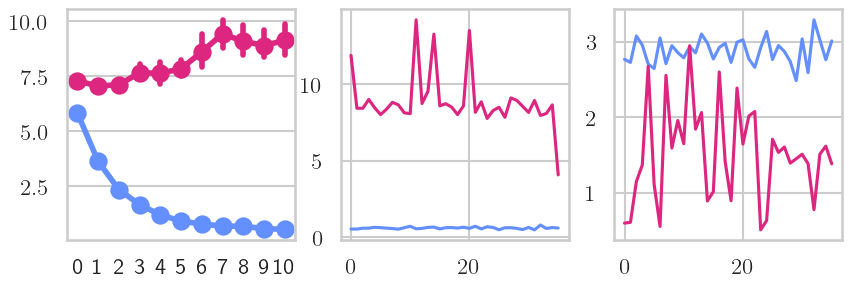

In [77]:
plt.figure(figsize=(10, 3))
sns.pointplot(all_kl_pred_obs_exp_model_blockwise, ax=plt.subplot(131))
sns.pointplot(all_kl_pred_obs_une_model_blockwise, ax=plt.subplot(131))
sns.lineplot(all_kl_pred_obs_exp_model_blockwise[9], ax=plt.subplot(132))
sns.lineplot(all_kl_pred_obs_une_model_blockwise[9], ax=plt.subplot(132))
sns.lineplot(all_log_ratios_exp_model_blockwise[9], ax=plt.subplot(133))
sns.lineplot(all_log_ratios_une_model_blockwise[9], ax=plt.subplot(133))
plt.show()

In [78]:
all_acc_exp_model = []
all_acc_une_model = []
all_fa_exp_model = []
all_fa_une_model = []
all_dPrime_exp_model = []
all_dPrime_une_model = []
all_criterion_exp_model = []
all_criterion_une_model = []

for sid in range(36):
    if exclusions_experiment1[sid]:
        continue

    conditions = E_experiment1[sid].lists.mainTask[:, 10:].ravel()
    model_responses = all_model_responses[sid].ravel()
    if flip_subject_experiment1[sid]:
        model_responses = np.array(
            list(map(model_to_resp_experiment1_map_flipped.get, model_responses))
        )
    else:
        model_responses = np.array(
            list(map(model_to_resp_experiment1_map.get, model_responses))
        )

    # log-linear correction / Laplace smoothing
    acc_exp1 = (
        sum(model_responses[conditions == 1] == conditions[conditions == 1]) + 0.5
    ) / (sum(conditions == 1) + 1)
    acc_exp2 = (
        sum(model_responses[conditions == 2] == conditions[conditions == 2]) + 0.5
    ) / (sum(conditions == 2) + 1)
    acc_exp = np.nanmean([acc_exp1, acc_exp2])
    all_acc_exp_model.append(acc_exp)

    acc_une1 = (sum(model_responses[conditions == 3] == 2) + 0.5) / (
        sum(conditions == 3) + 1
    )
    acc_une2 = (sum(model_responses[conditions == 4] == 1) + 0.5) / (
        sum(conditions == 4) + 1
    )
    acc_une = np.nanmean([acc_une1, acc_une2])
    all_acc_une_model.append(acc_une)

    ############### false alarms ###############

    fa_exp1 = (sum(model_responses[conditions == 5] == 1) + 0.5) / (
        sum(conditions == 5) + 1
    )
    fa_exp2 = (sum(model_responses[conditions == 6] == 2) + 0.5) / (
        sum(conditions == 6) + 1
    )
    fa_exp = np.nanmean([fa_exp1, fa_exp2])
    all_fa_exp_model.append(fa_exp)

    fa_une1 = (sum(model_responses[conditions == 5] == 2) + 0.5) / (
        sum(conditions == 5) + 1
    )
    fa_une2 = (sum(model_responses[conditions == 6] == 1) + 0.5) / (
        sum(conditions == 6) + 1
    )
    fa_une = np.nanmean([fa_une1, fa_une2])
    all_fa_une_model.append(fa_une)

    ############### d Prime ###############

    dPrime_exp = stats.norm.ppf(acc_exp) - stats.norm.ppf(fa_exp)
    all_dPrime_exp_model.append(dPrime_exp)

    dPrime_une = stats.norm.ppf(acc_une) - stats.norm.ppf(fa_une)
    all_dPrime_une_model.append(dPrime_une)

    ############### criterion ###############

    criterion_exp = -0.5 * (stats.norm.ppf(acc_exp) + stats.norm.ppf(fa_exp))
    all_criterion_exp_model.append(criterion_exp)

    criterion_une = -0.5 * (stats.norm.ppf(acc_une) + stats.norm.ppf(fa_une))
    all_criterion_une_model.append(criterion_une)

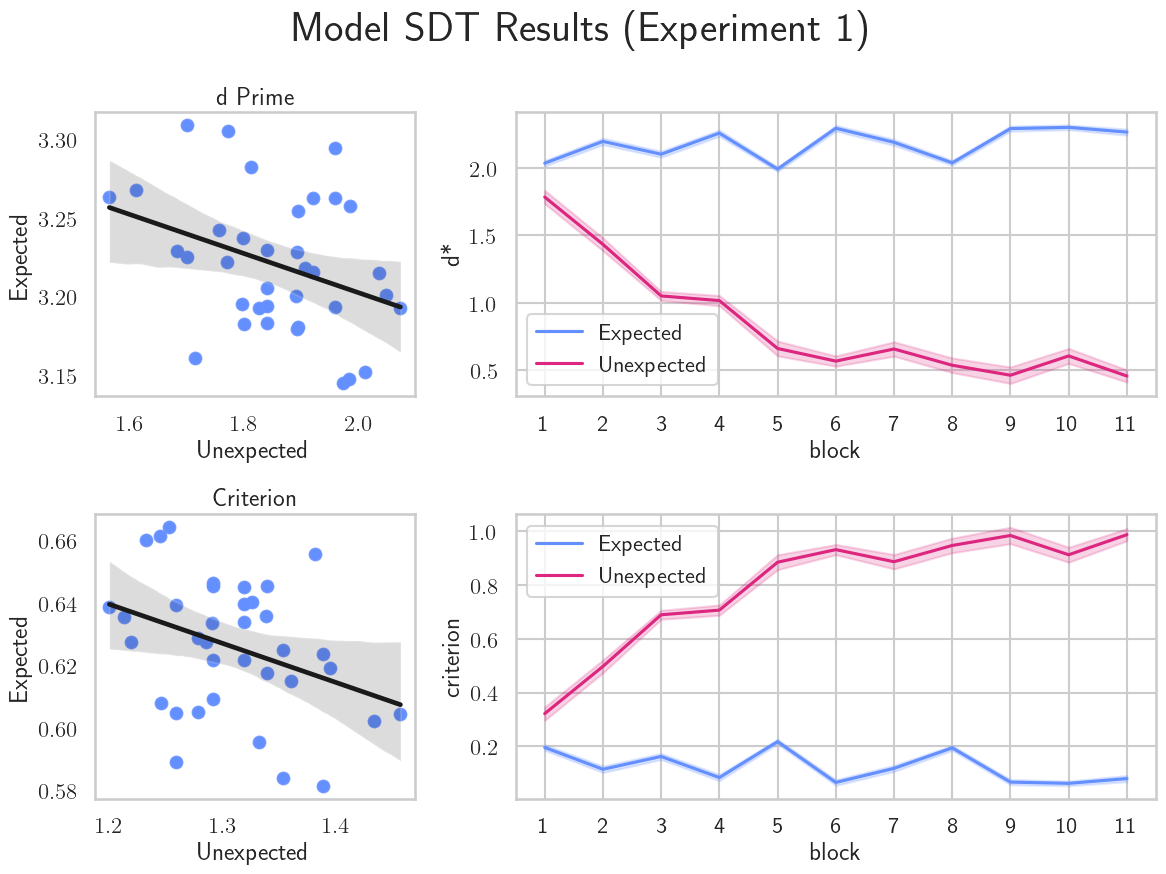

In [79]:
fig, ax = plt.subplots(2, 2, figsize=(12, 9), gridspec_kw={"width_ratios": [2, 4]})

sns.scatterplot(x=all_dPrime_une_model, y=all_dPrime_exp_model, ax=ax[0][0])
sns.regplot(
    x=all_dPrime_une_model, y=all_dPrime_exp_model, line_kws={"color": "k"}, ax=ax[0][0]
)
ax[0][0].set_xlabel("Unexpected")
ax[0][0].set_ylabel("Expected")
ax[0][0].set_title("d Prime")
ax[0][0].grid(False)

df = (
    pd.DataFrame(all_dprime_exp_model_blockwise)
    .T.assign(x=np.arange(len(all_dprime_exp_model_blockwise)))
    .melt(id_vars="x", value_name="y")
)
sns.lineplot(data=df, x="x", y="y", errorbar="se", ax=ax[0][1], label="Expected")
df = (
    pd.DataFrame(all_dprime_une_model_blockwise)
    .T.assign(x=np.arange(len(all_dprime_une_model_blockwise)))
    .melt(id_vars="x", value_name="y")
)
sns.lineplot(data=df, x="x", y="y", errorbar="se", ax=ax[0][1], label="Unexpected")
ax[0][1].set_xlabel("block")
ax[0][1].set_ylabel("d*")
ax[0][1].set_xticks(range(11), np.arange(1, 12))

# criterion
sns.scatterplot(x=all_criterion_une_model, y=all_criterion_exp_model, ax=ax[1][0])
sns.regplot(
    x=all_criterion_une_model,
    y=all_criterion_exp_model,
    line_kws={"color": "k"},
    ax=ax[1][0],
)
ax[1][0].set_xlabel("Unexpected")
ax[1][0].set_ylabel("Expected")
ax[1][0].set_title("Criterion")
ax[1][0].grid(False)

df = (
    pd.DataFrame(all_criterion_exp_model_blockwise)
    .T.assign(x=np.arange(len(all_criterion_exp_model_blockwise)))
    .melt(id_vars="x", value_name="y")
)
sns.lineplot(data=df, x="x", y="y", errorbar="se", ax=ax[1][1], label="Expected")
df = (
    pd.DataFrame(all_criterion_une_model_blockwise)
    .T.assign(x=np.arange(len(all_criterion_une_model_blockwise)))
    .melt(id_vars="x", value_name="y")
)
sns.lineplot(data=df, x="x", y="y", errorbar="se", ax=ax[1][1], label="Unexpected")
ax[1][1].set_xlabel("block")
ax[1][1].set_ylabel("criterion")
ax[1][1].set_xticks(range(11), np.arange(1, 12))

plt.suptitle("Model SDT Results (Experiment 1)", fontweight="bold", fontsize=30)
plt.tight_layout()
plt.savefig("./behavioral_modeling_results/main_model_experiment1_sdt.png", dpi=300)
plt.show()

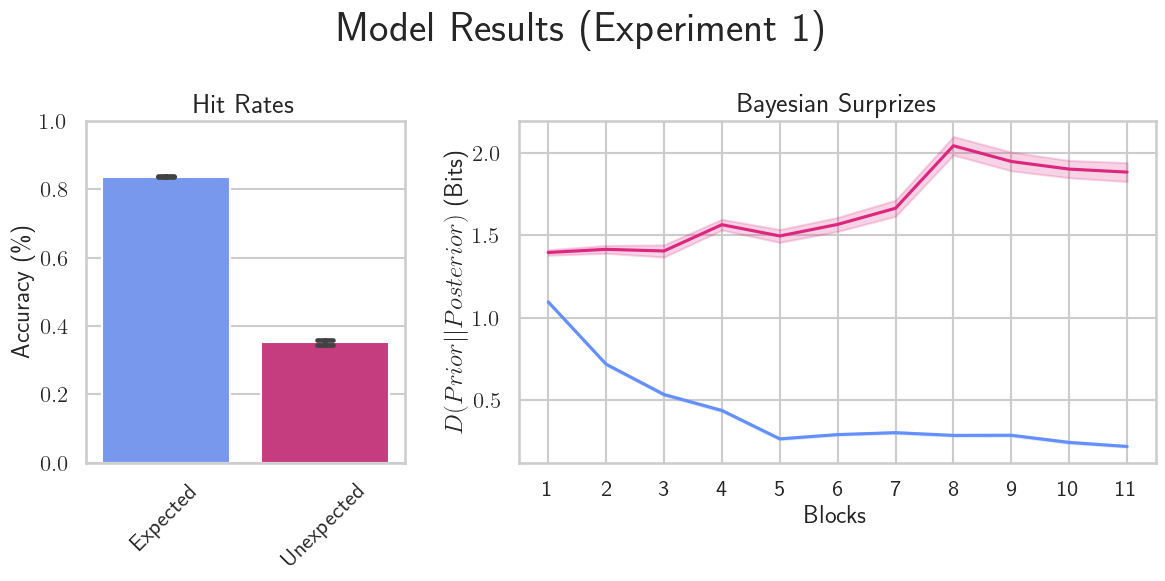

In [80]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={"width_ratios": [2, 4]})
df = pd.DataFrame(
    np.array([all_acc_exp_model, all_acc_une_model]).T,
    columns=["Expected", "Unexpected"],
)
sns.barplot(df, ax=ax[0], errorbar="se", capsize=0.1)  # 95% confience interval
ax[0].set_title("Hit Rates", fontweight="bold", fontsize=20)
ax[0].set_ylabel(r"Accuracy (\%)")
ax[0].set_ylim(0, 1)
ax[0].tick_params(axis="x", rotation=45)

df = (
    pd.DataFrame(all_surprize_exp_model_blockwise)
    .T.assign(x=np.arange(len(all_surprize_exp_model_blockwise)))
    .melt(id_vars="x", value_name="y")
)
sns.lineplot(data=df, x="x", y="y", errorbar="se", ax=ax[1])
df = (
    pd.DataFrame(all_surprize_une_model_blockwise)
    .T.assign(x=np.arange(len(all_surprize_une_model_blockwise)))
    .melt(id_vars="x", value_name="y")
)
sns.lineplot(data=df, x="x", y="y", errorbar="se", ax=ax[1])

ax[1].set_title(r"Bayesian Surprizes", fontweight="bold", fontsize=20)
ax[1].set_ylabel(r"$D(Prior||Posterior)$ (Bits)")
# ax[1].set_ylim(1.2, 1.6)
ax[1].set_xlabel("Blocks")
ax[1].set_xticks(range(11), np.arange(1, 12))

plt.suptitle("Model Results (Experiment 1)", fontweight="bold", fontsize=30)
plt.tight_layout()
plt.savefig("./behavioral_modeling_results/main_model_experiment1.png", dpi=300)

plt.show()

In [81]:
df = pd.DataFrame(
    np.array([all_acc_exp_model, all_acc_une_model]).T,
    columns=["Expected", "Unexpected"],
)
print(np.round(df.mean(), 4))
print(np.round(df.std(), 4))

df = (
    pd.DataFrame(all_surprize_exp_model_blockwise)
    .T.assign(x=np.arange(len(all_surprize_exp_model_blockwise)))
    .melt(id_vars="x", value_name="y")
)
print(np.round(df.y.mean(), 4))
print(np.round(df.y.std(), 4))

df = (
    pd.DataFrame(all_surprize_une_model_blockwise)
    .T.assign(x=np.arange(len(all_surprize_une_model_blockwise)))
    .melt(id_vars="x", value_name="y")
)
print(np.round(df.y.mean(), 4))
print(np.round(df.y.std(), 4))

Expected      0.8373
Unexpected    0.3526
dtype: float64
Expected      0.0105
Unexpected    0.0446
dtype: float64
0.425
0.2582
1.6573
0.3438


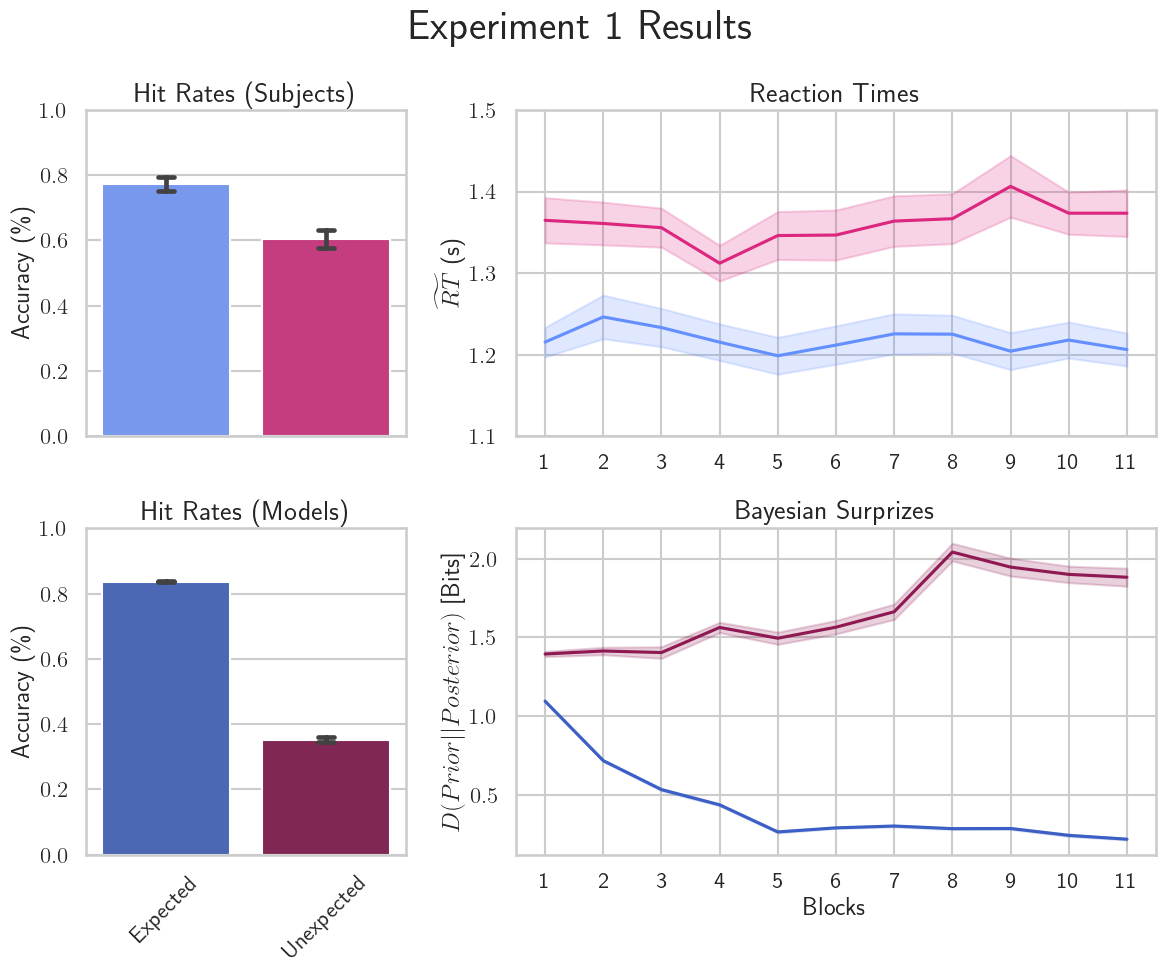

In [82]:
ibm_palette = [
    "#648fff",
    "#dc267f",
    "#fe6100",
    "#ffb000",
    "#785ef0",
    "#8be04e",
    "#009e73",
    "#56b4e9",
]
ibm_palette_darker = [
    "#3b5fc4",
    "#8f1953",
    "#a63f00",
    "#a86f00",
    "#4a37b8",
    "#8be04e",
    "#009e73",
    "#56b4e9",
]


fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(2, 2, width_ratios=[2, 4], height_ratios=[1, 1])
ax0 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

sns.set_palette(ibm_palette)
df = pd.DataFrame(
    np.array([all_acc_exp_experiment1, all_acc_une_experiment1]).T,
    columns=["Expected", "Unexpected"],
)
sns.barplot(df, ax=ax0, errorbar="se", capsize=0.1)  # 95% confience interval
ax0.set_title("Hit Rates (Subjects)", fontweight="bold", fontsize=20)
ax0.set_ylabel(r"Accuracy (\%)")
ax0.set_ylim(0, 1)
ax0.set_xticks([])


# rts/surprizes
sns.set_palette(ibm_palette)
sns.lineplot(
    data=(
        pd.DataFrame(all_rt_exp_experiment1_blockwise)
        .T.assign(x=np.arange(len(all_rt_exp_experiment1_blockwise)))
        .melt(id_vars="x", value_name="y")
    ),
    x="x",
    y="y",
    errorbar="se",
    ax=ax2,
)
sns.lineplot(
    data=(
        pd.DataFrame(all_rt_une_experiment1_blockwise)
        .T.assign(x=np.arange(len(all_rt_une_experiment1_blockwise)))
        .melt(id_vars="x", value_name="y")
    ),
    x="x",
    y="y",
    errorbar="se",
    ax=ax2,
)
ax2.set_title(r"Reaction Times", fontweight="bold", fontsize=20)
ax2.set_ylabel(r"$\widetilde{RT}$ (s)")
ax2.set_ylim(1.1, 1.5)
ax2.set_xlabel("")
ax2.set_xticks(range(11), np.arange(1, 12))


sns.set_palette(ibm_palette_darker)
ax1 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

df = pd.DataFrame(
    np.array([all_acc_exp_model, all_acc_une_model]).T,
    columns=["Expected", "Unexpected"],
)
sns.barplot(df, ax=ax1, errorbar="se", capsize=0.1)  # 95% confience interval
ax1.set_title("Hit Rates (Models)", fontweight="bold", fontsize=20)
ax1.set_ylabel(r"Accuracy (\%)")
ax1.set_ylim(0, 1)
ax1.tick_params(axis="x", rotation=45)

sns.set_palette(ibm_palette_darker)
sns.lineplot(
    data=(
        pd.DataFrame(all_surprize_exp_model_blockwise)
        .T.assign(x=np.arange(len(all_surprize_exp_model_blockwise)))
        .melt(id_vars="x", value_name="y")
    ),
    x="x",
    y="y",
    errorbar="se",
    ax=ax3,
)
sns.lineplot(
    data=(
        pd.DataFrame(all_surprize_une_model_blockwise)
        .T.assign(x=np.arange(len(all_surprize_une_model_blockwise)))
        .melt(id_vars="x", value_name="y")
    ),
    x="x",
    y="y",
    errorbar="se",
    ax=ax3,
)

ax3.set_title(r"Bayesian Surprizes", fontweight="bold", fontsize=20)
ax3.set_ylabel(r"$D(Prior||Posterior)$ [Bits]")
# ax3.set_ylim(1.2, 1.6)
ax3.set_xlabel("Blocks")
ax3.set_xticks(range(11), np.arange(1, 12))

plt.suptitle("Experiment 1 Results", fontweight="bold", fontsize=30)
plt.tight_layout()
plt.savefig("./behavioral_modeling_results/main_results_experiment1.png", dpi=300)

plt.show()

# reset
sns.set_palette(ibm_palette)

<Axes: xlabel='x', ylabel='y'>

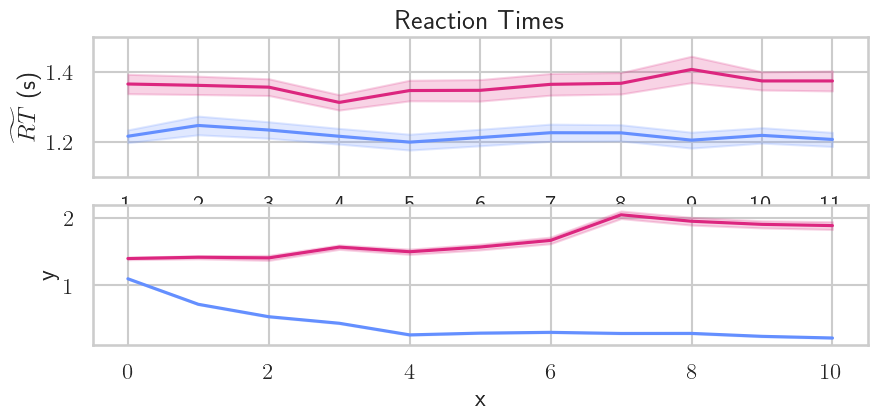

In [83]:
fig, ax = plt.subplots(2, 1, figsize=(10, 4))

# rts/surprizes
sns.set_palette(ibm_palette)
df_rt_experiment1_exp = (
    pd.DataFrame(all_rt_exp_experiment1_blockwise)
    .T.assign(x=np.arange(len(all_rt_exp_experiment1_blockwise)))
    .melt(id_vars="x", value_name="y")
)
df_rt_experiment1_une = (
    pd.DataFrame(all_rt_une_experiment1_blockwise)
    .T.assign(x=np.arange(len(all_rt_une_experiment1_blockwise)))
    .melt(id_vars="x", value_name="y")
)
sns.lineplot(data=df_rt_experiment1_exp, x="x", y="y", errorbar="se", ax=ax[0])
sns.lineplot(data=df_rt_experiment1_une, x="x", y="y", errorbar="se", ax=ax[0])
ax[0].set_title(r"Reaction Times", fontweight="bold", fontsize=20)
ax[0].set_ylabel(r"$\widetilde{RT}$ (s)")
ax[0].set_ylim(1.1, 1.5)
ax[0].set_xlabel("")
ax[0].set_xticks(range(11), np.arange(1, 12))

df_surp_model_exp = (
    pd.DataFrame(all_surprize_exp_model_blockwise)
    .T.assign(x=np.arange(len(all_surprize_exp_model_blockwise)))
    .melt(id_vars="x", value_name="y")
)
df_surp_model_une = (
    pd.DataFrame(all_surprize_une_model_blockwise)
    .T.assign(x=np.arange(len(all_surprize_une_model_blockwise)))
    .melt(id_vars="x", value_name="y")
)
sns.set_palette(ibm_palette_darker)
sns.lineplot(data=df_surp_model_exp, x="x", y="y", errorbar="se", ax=ax[1])
sns.lineplot(data=df_surp_model_une, x="x", y="y", errorbar="se", ax=ax[1])

# extract sequences

In [84]:
all_seq = []
all_subject_responses = []
for sid in range(36):
    if flip_subject_experiment1[sid]:
        seq = np.concatenate([np.array(list(map(pairs_experiment1_map_flipped.get, block))).ravel() for block in E_experiment1[sid].lists.mainTask])
        subject_responses = np.array(list(map(resp_to_state_experiment1_map.get, E_experiment1[sid].resp.mainTask.resp.ravel())))
    else:
        seq = np.concatenate([np.array(list(map(pairs_experiment1_map.get, block))).ravel() for block in E_experiment1[sid].lists.mainTask])
        subject_responses = np.array(list(map(resp_to_state_experiment1_map_flipped.get, E_experiment1[sid].resp.mainTask.resp.ravel())))
    all_seq.append(seq)
    all_subject_responses.append(subject_responses)

all_seq = np.array(all_seq)
all_subject_responses = np.array(all_subject_responses)

In [86]:
# test

# ground truth
gt_seq = all_seq[sid].reshape(2420//220, 220)[..., 20:].ravel().reshape(2200//2, 2).astype(str)
cues = gt_seq[:, 0]
gt_seq = np.char.add(cues, gt_seq[:, 1])
print(np.unique(gt_seq))
p_i = pd.Series(gt_seq).value_counts().values/gt_seq.size
print(p_i, sum(p_i))

# subjects
subject_seq = all_subject_responses[sid].reshape(1210//110, 110)[..., 10:].ravel().astype(str)
# subject_seq[subject_seq == '-1'] = '0'  # hotfix
subject_seq = np.char.add(cues, subject_seq)
subject_seq = subject_seq[(subject_seq != '1-1') & (subject_seq != '2-1')]  # hotfix
print(np.unique(subject_seq))
s_i = pd.Series(subject_seq).value_counts().values/subject_seq.size
print(s_i, sum(s_i))

# models
model_seq = all_model_responses[sid].ravel().astype(str)
model_seq = np.char.add(cues, model_seq)
model_seq = model_seq[(model_seq != '1-1') & (model_seq != '2-1')]  # hotfix
print(np.unique(model_seq))
m_i = pd.Series(model_seq).value_counts().values/model_seq.size
print(m_i, sum(m_i))


['10' '13' '14' '20' '23' '24']
[0.38       0.37       0.09       0.09       0.03636364 0.03363636] 1.0
['10' '13' '14' '20' '23' '24']
[0.35278031 0.35004558 0.0793072  0.0793072  0.07566089 0.06289881] 0.9999999999999999
['10' '13' '14' '20' '23' '24']
[0.32818182 0.31818182 0.15636364 0.14       0.03181818 0.02545455] 1.0


In [87]:

H_seq = []
H_sub = []
H_mod = []

CE_ps = []
CE_pm = []
CE_sm = []

for sid in tqdm(range(36)):
    # ground truth
    gt_seq = all_seq[sid].reshape(2420//220, 220)[..., 20:].ravel().reshape(2200//2, 2).astype(str)
    cues = gt_seq[:, 0]
    gt_seq = np.char.add(cues, gt_seq[:, 1])
    # print(np.unique(gt_seq))
    p_i = pd.Series(gt_seq).value_counts().values/gt_seq.size
    # print(p_i)
    H_seq.append(_entropy(p_i))
    
    # subjects
    subject_seq = all_subject_responses[sid].reshape(1210//110, 110)[..., 10:].ravel().astype(str)
    # subject_seq[subject_seq == '-1'] = '0'  # hotfix
    subject_seq = np.char.add(cues, subject_seq)
    subject_seq = subject_seq[(subject_seq != '1-1') & (subject_seq != '2-1')]  # hotfix
    # print(np.unique(subject_seq))
    s_i = pd.Series(subject_seq).value_counts().values/subject_seq.size
    # print(s_i)
    H_sub.append(_entropy(s_i))
    
    # models
    model_seq = all_model_responses[sid].ravel().astype(str)
    model_seq = np.char.add(cues, model_seq)
    model_seq = model_seq[(model_seq != '1-1') & (model_seq != '2-1')]  # hotfix
    # print(np.unique(model_seq))
    m_i = pd.Series(model_seq).value_counts().values/model_seq.size
    # print(m_i)
    H_mod.append(_entropy(m_i))

    CE_ps.append(_cross_entropy(p_i, s_i))
    CE_pm.append(_cross_entropy(p_i, m_i))
    CE_sm.append(_cross_entropy(s_i, m_i))

100%|██████████| 36/36 [00:00<00:00, 259.06it/s]


In [89]:
data_store["model_experiment1"] = {
    "all_dPrime_une_experiment1": all_dPrime_une_model,
    "all_dPrime_exp_experiment1": all_dPrime_exp_model,
    "all_criterion_une_experiment1": all_criterion_une_model,
    "all_criterion_exp_experiment1": all_criterion_exp_model,
    "all_dPrime_exp_experiment1_blockwise": all_dprime_exp_model_blockwise,
    "all_dPrime_une_experiment1_blockwise": all_dprime_une_model_blockwise,
    "all_criterion_exp_experiment1_blockwise": all_criterion_exp_model_blockwise,
    "all_criterion_une_experiment1_blockwise": all_criterion_une_model_blockwise,
    "all_belief_exp1_model_blockwise": all_belief_exp1_model_blockwise,
    "all_belief_une1_model_blockwise": all_belief_une1_model_blockwise,
    "all_belief_exp2_model_blockwise": all_belief_exp2_model_blockwise,
    "all_belief_une2_model_blockwise": all_belief_une2_model_blockwise,
    "all_surprize_exp_model_blockwise": all_surprize_exp_model_blockwise,
    "all_surprize_une_model_blockwise": all_surprize_une_model_blockwise,
    "all_log_ratios_exp_model_blockwise": all_log_ratios_exp_model_blockwise,
    "all_log_ratios_une_model_blockwise": all_log_ratios_une_model_blockwise,
    "all_kl_pred_obs_exp_model_blockwise": all_kl_pred_obs_exp_model_blockwise,
    "all_kl_pred_obs_une_model_blockwise": all_kl_pred_obs_une_model_blockwise,
    "all_model_neglog_pred_exp_blockwise": all_model_neglog_pred_exp_blockwise,
    "all_model_neglog_pred_une_blockwise": all_model_neglog_pred_une_blockwise,
    "all_model_neglog_post_exp_blockwise": all_model_neglog_post_exp_blockwise,
    "all_model_neglog_post_une_blockwise": all_model_neglog_post_une_blockwise,
    "all_priorentropies_exp_model_blockwise": all_priorentropies_exp_model_blockwise,
    "all_priorentropies_une_model_blockwise": all_priorentropies_une_model_blockwise,
    "all_acc_une_experiment1": deepcopy(all_acc_une_model),
    "all_acc_exp_experiment1": deepcopy(all_acc_exp_model),
}

In [90]:
with open("./stats/data_store_with_hitrates.pkl", "wb") as f:
    pkl.dump(data_store, f)

# with open("./stats/data_store.pkl", "wb") as f:
#     pkl.dump(data_store, f)

---

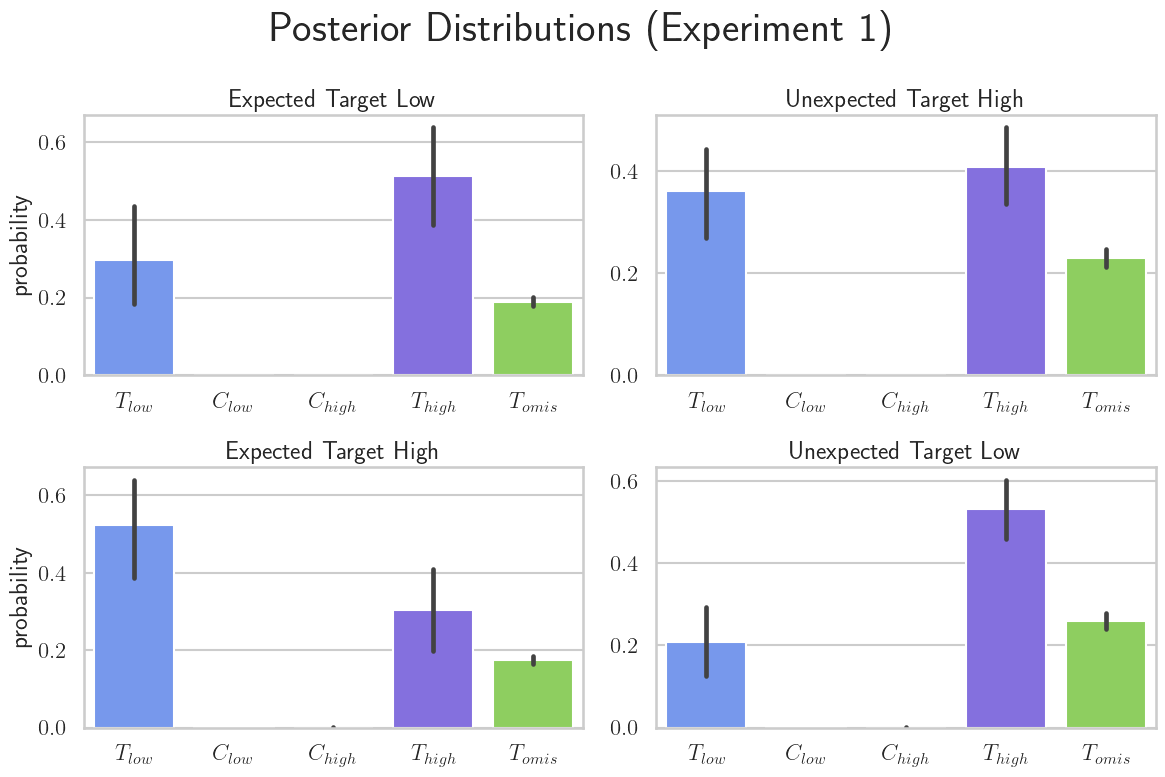

In [91]:
ibm_palette = [
    "#648fff",
    "#dc267f",
    "#ffb000",
    "#785ef0",
    "#8be04e",
    "#009e73",
    "#56b4e9",
]
sns.set_palette(ibm_palette)


fig, axes = plt.subplots(2, 2, figsize=(12, 8))

data = np.array(list(all_belief_exp1_model_blockwise.values()))
ax = sns.barplot(np.nanmean(data, axis=0), ax=axes[0][0])
ax.set_xticks(range(5), experiment1_label_names)
ax.set_title("Expected Target Low")
ax.set_ylabel("probability")

data = np.array(list(all_belief_une1_model_blockwise.values()))
ax = sns.barplot(np.nanmean(data, axis=0), ax=axes[0][1])
ax.set_xticks(range(5), experiment1_label_names)
ax.set_title("Unexpected Target High")

# high freq
data = np.array(list(all_belief_exp2_model_blockwise.values()))
ax = sns.barplot(np.nanmean(data, axis=0), ax=axes[1][0])
ax.set_xticks(range(5), experiment1_label_names)
ax.set_title("Expected Target High")
ax.set_ylabel("probability")

data = np.array(list(all_belief_une2_model_blockwise.values()))
ax = sns.barplot(np.nanmean(data, axis=0), ax=axes[1][1])
ax.set_xticks(range(5), experiment1_label_names)
ax.set_title("Unexpected Target Low")

plt.suptitle("Posterior Distributions (Experiment 1)", fontweight="bold", fontsize=30)
plt.tight_layout()
plt.savefig("./behavioral_modeling_results/posterior_beliefs_experiment1.png", dpi=300)

plt.show()

# reset color palette
ibm_palette = [
    "#648fff",
    "#dc267f",
    "#fe6100",
    "#ffb000",
    "#785ef0",
    "#8be04e",
    "#009e73",
    "#56b4e9",
]
sns.set_palette(ibm_palette)

## Decisions

In [92]:
# all_models_W = np.array([all_models[sid].W for sid in range(n_subjects)])
# learned_mean = np.nanmean(all_models_W, axis=0)
# learned_std = np.nanstd(all_models_W, axis=0)

# extracted_all_noresp_masks = np.array(all_noresp_masks)[~exclusions_experiment1][
#     :, 1::2
# ].reshape(sum(~exclusions_experiment1), 11, 1210 // 11)[..., 10:]

# extracted_subject_responses = np.array(all_subject_responses)[~exclusions_experiment1]
# extracted_model_responses = np.array(all_model_responses)[~exclusions_experiment1]
# extracted_optimal_model_responses = np.array(all_optimal_model_responses)[
#     ~exclusions_experiment1
# ]
# extracted_optimal_responses = np.array(all_optimal_responses)[~exclusions_experiment1]


# extracted_subject_responses[~extracted_all_noresp_masks] = -1
# extracted_model_responses[~extracted_all_noresp_masks] = -1
# extracted_optimal_model_responses[~extracted_all_noresp_masks] = -1
# extracted_optimal_responses[~extracted_all_noresp_masks] = -1

# data = pd.DataFrame(
#     {
#         "Model-Subject": np.mean(
#             extracted_subject_responses == extracted_model_responses, axis=(1, 2)
#         ),
#         "Subject-Optimal": np.mean(
#             extracted_subject_responses == extracted_optimal_responses, axis=(1, 2)
#         ),
#         "Model-Optimal": np.mean(
#             extracted_model_responses == extracted_optimal_responses, axis=(1, 2)
#         ),
#     }
# )

In [93]:
# sns.set_palette(ibm_palette)

# data = pd.DataFrame(
#     {
#         "Model-Subject": np.mean(
#             np.array(all_subject_responses) == np.array(all_model_responses),
#             axis=(1, 2),
#         ),
#         "OptModel-Subject": np.mean(
#             np.array(all_subject_responses) == np.array(all_optimal_model_responses),
#             axis=(1, 2),
#         ),
#         "Subject-Optimal": np.mean(
#             np.array(all_subject_responses) == np.array(all_optimal_responses),
#             axis=(1, 2),
#         ),
#         "Model-Optimal": np.mean(
#             np.array(all_model_responses) == np.array(all_optimal_responses),
#             axis=(1, 2),
#         ),
#     }
# )


# plt.figure(figsize=(6, 8))
# ax = sns.barplot(data * 100)
# ax.tick_params(axis="x", rotation=45)
# ax.set_ylabel(r"Accuracy (\%)")

# plt.suptitle("Decision Overlap (Experiment 1)", fontweight="bold", fontsize=30)
# plt.tight_layout()
# plt.savefig("./behavioral_modeling_results/decision_overlap_experiment1.png", dpi=300)

# plt.show()

---